# 4\.1\.2 Define Forecasting Modeling Tracks and Rolling Backtests

This notebook turns the forecasting targets created in \`4\.1\.1\` into chronological modeling experiments\. It separates three uses of the mobility history: a \*\*post\-CP primary model\*\* trained only on the congestion\-pricing regime, a \*\*full\-history regime\-aware comparison\*\* that can also learn from the longer 2023–2024 history, and a \*\*pre\-CP reference model\*\* kept entirely before January 5, 2025 for later counterfactual work\.

Two main downstream tables will be built\. \`forecast\_origin\_horizon\_registry\_df\` will define the common forecasting calendar, including each forecast origin, how far ahead the prediction looks, and when the future target actually occurs\. \`rolling\_origin\_registry\_df\` will later define the chronological validation folds used by the three modeling tracks\. Together, these tables will ensure that every model is trained and evaluated using the same explicit time boundaries rather than rebuilding split logic independently\.

\-\-\-

> What does “horizon” mean here?

A forecast origin is the latest point in the sequence whose information is available when a prediction is made\. The \*\*horizon\*\* tells us how many ordered daypart steps beyond that origin we are predicting:

\* \`h=1\` → the next daypart
\* \`h=2\` → two dayparts ahead
\* \`h=5\` → the same daypart on the following date

For example, if the forecast origin is AM Peak, then \`h=1\` predicts Midday, \`h=2\` predicts PM Peak, and \`h=5\` predicts the next day's AM Peak\. One forecast origin can therefore appear three times in \`forecast\_origin\_horizon\_registry\_df\`: once for each future horizon\. Those rows are not duplicates—they represent three different future prediction targets\.

Load the core libraries and define the shared paths, study-boundary dates, horizon expectations, display options, and lightweight validation helpers used throughout the notebook. This keeps the split logic explicit and durable rather than relying on imports or constants introduced later inside chapter-specific cells.

In [1]:
# ---------------------------------------------------------------------
# 4.1.2.0 — Notebook setup
# ---------------------------------------------------------------------

from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 180)

FORECAST_INPUT_DIR = Path(
    "pipeline_data/4.1.1.final_tables"
)

CP_START_DATE = pd.Timestamp("2025-01-05")
FINAL_HOLDOUT_START = pd.Timestamp("2026-01-05")
FINAL_HOLDOUT_END = pd.Timestamp("2026-03-31")
EXPECTED_FORECAST_HORIZONS = [1, 2, 5]

RUN_FORECAST_SPLIT_QA = True


def duplicate_count(frame: pd.DataFrame, key_columns: list[str]) -> int:
    """Return the number of duplicate rows at the requested grain."""
    return int(frame.duplicated(subset=key_columns).sum())


print(f"4.1.1 handoff directory: {FORECAST_INPUT_DIR}")
print(f"Expected forecast horizons: {EXPECTED_FORECAST_HORIZONS}")
print(f"Congestion pricing start: {CP_START_DATE.date()}")
print(f"Final holdout: {FINAL_HOLDOUT_START.date()} through {FINAL_HOLDOUT_END.date()}")

4.1.1 handoff directory: pipeline_data/4.1.1.final_tables
Expected forecast horizons: [1, 2, 5]
Congestion pricing start: 2025-01-05
Final holdout: 2026-01-05 through 2026-03-31


## 4.1.2.1 Load and Validate Forecasting Inputs

This chapter loads the three forecasting handoff files created in `4.1.1`. The sequence panel contains the ordered observations and future targets, the support registry carries one set of coverage and eligibility diagnostics per Taxi Zone × Metric sequence, and the horizon registry defines the shared `h=1`, `h=2`, and `h=5` prediction distances. These inputs remain separate because they operate at different grains and serve different downstream jobs.

**Load the forecasting handoff from `4.1.1`.** Read the three authoritative inputs that will drive the split and rolling-backtest logic in this notebook.

In [2]:
# 4.1.2.1A — Load the forecasting handoff from 4.1.1
#
# The sequence panel is the large observation-level forecasting layer. It
# contains one row per Taxi Zone × Metric × observation_sequence_id and carries
# the future h=1, h=2, and h=5 targets created in the previous notebook.
#
# The support registry remains separate because its diagnostics describe an
# entire Taxi Zone × Metric sequence rather than an individual observation.
# Keeping one support row per sequence avoids repeating the same information
# millions of times.
#
# The horizon registry provides the common set of prediction distances used by
# every modeling track, baseline, and model family downstream.

forecast_sequence_df = pd.read_parquet(
    FORECAST_INPUT_DIR
    / "forecasting_target_sequence_panel.parquet"
)

forecast_support_df = pd.read_parquet(
    FORECAST_INPUT_DIR
    / "forecasting_sequence_support_registry.parquet"
)

forecast_horizon_registry_df = pd.read_parquet(
    FORECAST_INPUT_DIR
    / "forecast_horizon_registry.parquet"
)

FORECAST_HORIZONS = (
    forecast_horizon_registry_df["horizon"]
    .astype(int)
    .sort_values()
    .tolist()
)

print(
    "forecast_sequence_df:",
    f"{len(forecast_sequence_df):,} rows × "
    f"{forecast_sequence_df.shape[1]} columns",
)

print(
    "forecast_support_df:",
    f"{len(forecast_support_df):,} rows × "
    f"{forecast_support_df.shape[1]} columns",
)

print(
    "forecast_horizon_registry_df:",
    f"{len(forecast_horizon_registry_df):,} rows × "
    f"{forecast_horizon_registry_df.shape[1]} columns",
)

forecast_sequence_df: 7,797,950 rows × 38 columns
forecast_support_df: 1,315 rows × 36 columns
forecast_horizon_registry_df: 3 rows × 5 columns


**Validate the input grains before building time splits.** Confirm that the large sequence panel remains unique at Taxi Zone × Metric × sequence position, the support registry contains one row per forecasting sequence, and the three horizon definitions match the targets carried by the sequence panel.

In [3]:
# 4.1.2.1B — Validate the forecasting input grains
#
# These checks protect the grain established in 4.1.1 before any time-split
# logic is added. A duplicate observation position would create duplicate
# forecast origins, while a duplicate support record could assign conflicting
# eligibility information to the same Taxi Zone × Metric sequence.
#
# We also confirm that every forecasting sequence represented in the large
# target panel has exactly one corresponding sequence in the support registry.

sequence_duplicate_count = duplicate_count(
    forecast_sequence_df,
    [
        "taxi_zone_id",
        "metric",
        "observation_sequence_id",
    ],
)

support_duplicate_count = duplicate_count(
    forecast_support_df,
    [
        "taxi_zone_id",
        "metric",
    ],
)

sequence_ids_match = (
    set(
        forecast_sequence_df[
            "forecast_sequence_id"
        ].unique()
    )
    ==
    set(
        forecast_support_df[
            "forecast_sequence_id"
        ].unique()
    )
)

horizons_match = (
    FORECAST_HORIZONS == EXPECTED_FORECAST_HORIZONS
)

input_validation_df = pd.DataFrame(
    [
        {
            "check": "Sequence-panel duplicate keys",
            "result": sequence_duplicate_count,
            "expected": 0,
        },
        {
            "check": "Support-registry duplicate keys",
            "result": support_duplicate_count,
            "expected": 0,
        },
        {
            "check": "Sequence IDs match support registry",
            "result": sequence_ids_match,
            "expected": True,
        },
        {
            "check": "Forecast horizons are h=1, h=2, h=5",
            "result": horizons_match,
            "expected": True,
        },
    ]
)

if RUN_FORECAST_SPLIT_QA:
    assert sequence_duplicate_count == 0
    assert support_duplicate_count == 0
    assert sequence_ids_match
    assert horizons_match

display(input_validation_df)

,check,result,expected
0,Sequence-panel duplicate keys,0,0
1,Support-registry duplicate keys,0,0
2,Sequence IDs match support registry,True,True
3,"Forecast horizons are h=1, h=2, h=5",True,True


Findings\. \*Findings to be added after execution and review of the output above\.\*

### Section Summary

The forecasting targets, sequence-level support information, and common horizon definitions from `4.1.1` are now loaded and validated at their intended grains. These inputs provide a single source for the future values being predicted, the sequence history available for modeling, and the three forecast distances that every modeling track will use.

---

## 4.1.2.2 Define the Modeling Tracks and Final Post-CP Holdout

The three forecasting tracks use the **same daypart-resolution targets and horizons but different amounts of historical data**. The post-CP primary model learns only from observations beginning January 5, 2025. The full-history regime-aware comparison can also use the 2023–2024 history, while later model features explicitly identify whether an observation belongs to the pre- or post-CP regime. The pre-CP reference model stops before January 5, 2025 and never trains or evaluates on post-CP mobility.

The final ordinary forecasting holdout is **January 5 through March 31, 2026**. It is shared by the post-CP primary and full-history regime-aware comparison so the two approaches can be compared on exactly the same future mobility states. The pre-CP reference has no 2026 holdout; its validation remains entirely before congestion pricing begins.

By the end of this chapter, `forecast_origin_horizon_registry_df` will contain one row for each valid **`observation_sequence_id × horizon`** combination. Each row will identify the forecast origin through `date` and `daypart`, the prediction distance through `horizon`, the future state through `target_date` and `target_daypart`, and the time period through `target_period`.

> **How the three modeling tracks differ**
>
> **Post-CP primary.** Uses history beginning January 5, 2025. This is the primary ordinary forecasting approach because it learns only from mobility observed under congestion pricing.
>
> **Full-history regime-aware comparison.** Uses the longer history beginning in 2023 so we can test whether additional seasonal and recurring historical information improves post-CP forecasting. Later models must explicitly represent the pre/post-CP regime. It is evaluated on the same validation and final-holdout targets as the post-CP primary.
>
> **Pre-CP reference.** Uses only observations and future targets before January 5, 2025. It provides a clean pre-policy forecasting system for later Chapter 6 counterfactual work.

**Build the common forecast-origin × horizon calendar.** Reduce the repeated temporal fields in the 7.8-million-row sequence panel to one shared copy of each sequence position, then reshape the three future horizons into a compact long-form registry.

In [4]:
# 4.1.2.2A — Build the common forecast-origin × horizon calendar
#
# Every Taxi Zone × Metric sequence follows the same canonical Date × Daypart
# calendar. The temporal fields therefore repeat 1,315 times across the large
# sequence panel even though the forecast timing is identical.
#
# First reduce the panel to one record per observation_sequence_id. Then reshape
# the h=1, h=2, and h=5 target-time columns into one row per
# observation_sequence_id × horizon.
#
# The resulting forecast_origin_horizon_registry_df is a compact temporal
# backbone for downstream split construction. It contains no Taxi Zone or Metric
# dimension because those dimensions do not change the calendar itself.

# Columns describing the point in time from which a forecast is made.
# observation_sequence_id is the canonical ordered position in the five-daypart
# sequence; the remaining fields make that position readable in calendar terms.
origin_columns = [
    "observation_sequence_id",
    "date",
    "daypart",
    "daypart_order",
    "temporal_bucket",
    "temporal_bucket_order",
    "pre_post_cp",
]

# Collect the future-time fields created in 4.1.1 for each approved horizon.
# At this stage the source panel stores these in wide form:
# target_date_h1, target_date_h2, target_date_h5, etc.
target_time_columns = []

for horizon in FORECAST_HORIZONS:
    target_time_columns.extend(
        [
            f"target_observation_sequence_id_h{horizon}",
            f"target_date_h{horizon}",
            f"target_daypart_h{horizon}",
            f"target_daypart_order_h{horizon}",
            f"target_temporal_bucket_h{horizon}",
            f"target_temporal_bucket_order_h{horizon}",
            f"target_pre_post_cp_h{horizon}",
        ]
    )

# Strip away Taxi Zone × Metric repetition and keep only the shared temporal
# structure. Because all 1,315 forecasting sequences use the same canonical
# ordering, each observation_sequence_id should collapse to exactly one row.
forecast_origin_time_grid_df = (
    forecast_sequence_df[
        origin_columns + target_time_columns
    ]
    .drop_duplicates()
    .sort_values("observation_sequence_id")
    .reset_index(drop=True)
)

# A sequence position must have one and only one calendar interpretation.
# Failure here would mean the supposedly shared forecasting calendar differs
# across Taxi Zones or metrics.
assert forecast_origin_time_grid_df[
    "observation_sequence_id"
].is_unique

# Carry the reader-friendly horizon description from the 4.1.1 horizon
# registry so downstream tables retain both the numeric horizon and its meaning.
horizon_label_lookup = (
    forecast_horizon_registry_df
    .set_index("horizon")["horizon_label"]
    .to_dict()
)

# Convert the three horizon-specific column groups from wide form into a common
# long-form schema. Each temporary dataframe represents one prediction distance
# across every possible forecast origin.
origin_horizon_frames = []

for horizon in FORECAST_HORIZONS:

    # Select the origin information plus only the future-time fields belonging
    # to the current horizon.
    horizon_df = forecast_origin_time_grid_df[
        origin_columns
        + [
            f"target_observation_sequence_id_h{horizon}",
            f"target_date_h{horizon}",
            f"target_daypart_h{horizon}",
            f"target_daypart_order_h{horizon}",
            f"target_temporal_bucket_h{horizon}",
            f"target_temporal_bucket_order_h{horizon}",
            f"target_pre_post_cp_h{horizon}",
        ]
    ].copy()

    # Remove the horizon suffixes now that horizon becomes its own column.
    # This gives h=1, h=2, and h=5 the same target-time schema before stacking.
    horizon_df = horizon_df.rename(
        columns={
            f"target_observation_sequence_id_h{horizon}":
                "target_observation_sequence_id",
            f"target_date_h{horizon}":
                "target_date",
            f"target_daypart_h{horizon}":
                "target_daypart",
            f"target_daypart_order_h{horizon}":
                "target_daypart_order",
            f"target_temporal_bucket_h{horizon}":
                "target_temporal_bucket",
            f"target_temporal_bucket_order_h{horizon}":
                "target_temporal_bucket_order",
            f"target_pre_post_cp_h{horizon}":
                "target_pre_post_cp",
        }
    )

    # Record which prediction distance this row represents.
    horizon_df["horizon"] = horizon
    horizon_df["horizon_label"] = (
        horizon_label_lookup[horizon]
    )

    # The final h sequence positions do not have a future target because the
    # study ends on March 31, 2026. Remove those boundary rows rather than
    # treating them as valid forecast-origin × horizon combinations.
    horizon_df = horizon_df.loc[
        horizon_df[
            "target_observation_sequence_id"
        ].notna()
    ].copy()

    origin_horizon_frames.append(horizon_df)

# Stack the three horizons into the final long-form calendar.
# A single observation_sequence_id can legitimately appear up to three times:
# once for h=1, once for h=2, and once for h=5.
forecast_origin_horizon_registry_df = (
    pd.concat(
        origin_horizon_frames,
        ignore_index=True,
    )
    .sort_values(
        [
            "observation_sequence_id",
            "horizon",
        ]
    )
    .reset_index(drop=True)
)

# Future sequence IDs are integer positions. They were temporarily represented
# as nullable numeric values because the source contains missing targets at the
# end of the study window; those rows have already been removed above.
forecast_origin_horizon_registry_df[
    "target_observation_sequence_id"
] = (
    forecast_origin_horizon_registry_df[
        "target_observation_sequence_id"
    ]
    .astype(int)
)

# Normalize both origin and future-target dates as pandas timestamps before
# applying regime boundaries and chronological split rules in the next blocks.
forecast_origin_horizon_registry_df["date"] = (
    pd.to_datetime(
        forecast_origin_horizon_registry_df["date"]
    )
)

forecast_origin_horizon_registry_df["target_date"] = (
    pd.to_datetime(
        forecast_origin_horizon_registry_df[
            "target_date"
        ]
    )
)

print(
    "forecast_origin_horizon_registry_df:",
    f"{len(forecast_origin_horizon_registry_df):,} "
    "origin × horizon rows",
)

forecast_origin_horizon_registry_df: 17,782 origin × horizon rows


Findings\. The shared forecasting calendar contains 17,782 valid forecast\-origin × horizon combinations across h=1, h=2, and h=5\. Reducing the repeated temporal information from the full sequence panel therefore preserves the complete forecasting timeline in a compact form while retaining the exact origin and future\-target positions needed for chronological split construction\.

Preview one forecast origin across all three horizons\. Select an ordinary AM Peak origin from the middle of the study period and show how the reshaped registry represents its three future prediction tasks\. The origin fields remain identical across the rows; horizon changes which future sequence position, date, and daypart becomes the target\.

In [5]:
# 4.1.2.2B — Preview one forecast origin across all three horizons
#
# The reshape above changes the grain from one sequence position with three
# separate groups of h=1 / h=2 / h=5 target columns into one row per
# observation_sequence_id × horizon.
#
# To make that structure concrete, choose one AM Peak origin well inside the
# timeline where all three horizons are available. The same forecast origin
# should appear three times:
#
#   h=1 -> next daypart
#   h=2 -> two dayparts ahead
#   h=5 -> same daypart on the following date
#
# Only the future-target fields should change across those three rows.

complete_horizon_counts = (
    forecast_origin_horizon_registry_df
    .groupby("observation_sequence_id")
    ["horizon"]
    .nunique()
)

complete_origin_ids = (
    complete_horizon_counts.loc[
        complete_horizon_counts.eq(
            len(FORECAST_HORIZONS)
        )
    ]
    .index
)

preview_candidates_df = (
    forecast_origin_horizon_registry_df.loc[
        forecast_origin_horizon_registry_df[
            "observation_sequence_id"
        ].isin(complete_origin_ids)
        & forecast_origin_horizon_registry_df[
            "daypart"
        ].eq("am_peak")
        & forecast_origin_horizon_registry_df[
            "date"
        ].between(
            pd.Timestamp("2025-04-01"),
            pd.Timestamp("2025-10-01"),
            inclusive="both",
        )
    ]
    .sort_values(
        [
            "observation_sequence_id",
            "horizon",
        ]
    )
)

preview_origin_id = (
    preview_candidates_df[
        "observation_sequence_id"
    ]
    .drop_duplicates()
    .iloc[
        len(
            preview_candidates_df[
                "observation_sequence_id"
            ].drop_duplicates()
        )
        // 2
    ]
)

forecast_origin_preview_df = (
    forecast_origin_horizon_registry_df.loc[
        forecast_origin_horizon_registry_df[
            "observation_sequence_id"
        ].eq(preview_origin_id),
        [
            "observation_sequence_id",
            "date",
            "daypart",
            "horizon",
            "horizon_label",
            "target_observation_sequence_id",
            "target_date",
            "target_daypart",
        ],
    ]
    .sort_values("horizon")
    .reset_index(drop=True)
)

display(forecast_origin_preview_df)

,observation_sequence_id,date,daypart,horizon,horizon_label,target_observation_sequence_id,target_date,target_daypart
0,4567,2025-07-02,am_peak,1,next sequence step,4568,2025-07-02,midday
1,4567,2025-07-02,am_peak,2,two sequence steps ahead,4569,2025-07-02,pm_peak
2,4567,2025-07-02,am_peak,5,same daypart next day,4572,2025-07-03,am_peak


Findings\. The row\-level preview confirms the new origin × horizon grain directly\. A single AM Peak forecast origin appears once for each approved horizon: h=1 targets Midday, h=2 targets PM Peak, and h=5 targets the following day's AM Peak\. The origin fields remain fixed while only the future target position and timestamp change, showing that the reshape preserves one common forecast origin while representing three distinct prediction tasks\.

**Assign each future target to its modeling period.** Use `target_date`, rather than the forecast-origin date, to identify whether the value being predicted belongs to the pre-CP period, post-CP development period, or final 2026 holdout.

In [6]:
# 4.1.2.2C — Assign each future target to its modeling period
#
# Each row in forecast_origin_horizon_registry_df represents a forecast made
# from one observation_sequence_id at one horizon. The row therefore contains
# two different timestamps:
#
#   date        = when the forecast is made
#   target_date = when the predicted mobility state actually occurs
#
# Modeling-period membership follows target_date. This prevents forecasts that
# cross a regime or holdout boundary from being assigned to the wrong period.
#
# Example:
# An h=5 forecast may originate on January 4, 2026 but predict January 5, 2026.
# That prediction belongs to the final holdout because its target occurs there.

# Divide every future target into one of three mutually exclusive periods:
#
#   pre_cp
#       Any target before congestion pricing begins.
#
#   post_cp_development
#       Targets observed under congestion pricing but before the untouched
#       January-March 2026 final evaluation period.
#
#   final_post_cp_holdout
#       Targets reserved for final ordinary forecasting evaluation.
#
# np.select applies these conditions in order and assigns the corresponding
# text label to each row.
forecast_origin_horizon_registry_df[
    "target_period"
] = np.select(
    [
        # Pre-CP targets end on January 4, 2025.
        forecast_origin_horizon_registry_df[
            "target_date"
        ].lt(CP_START_DATE),

        # Post-CP development begins on January 5, 2025 and ends on
        # January 4, 2026, immediately before the final holdout.
        forecast_origin_horizon_registry_df[
            "target_date"
        ].between(
            CP_START_DATE,
            FINAL_HOLDOUT_START
            - pd.Timedelta(days=1),
            inclusive="both",
        ),

        # The final ordinary forecasting holdout covers January 5 through
        # March 31, 2026.
        forecast_origin_horizon_registry_df[
            "target_date"
        ].between(
            FINAL_HOLDOUT_START,
            FINAL_HOLDOUT_END,
            inclusive="both",
        ),
    ],
    [
        "pre_cp",
        "post_cp_development",
        "final_post_cp_holdout",
    ],

    # Anything reaching this label falls outside the intended study-period
    # partition and should trigger the validation check immediately below.
    default="outside_study_window",
)

# Every valid future target in the forecasting calendar should fall into one
# of the three periods above. If this assertion fails, a date boundary is
# missing, overlapping, or inconsistent with the source sequence panel.
assert not forecast_origin_horizon_registry_df[
    "target_period"
].eq("outside_study_window").any()

# Summarize the resulting calendar separately by target period and horizon.
#
# This output checks two things at once:
#   1. each horizon reaches the expected temporal boundaries, and
#   2. the number of usable origin-target combinations is sensible within
#      each period.
#
# Small differences between horizons can occur at the beginning or end of the
# overall sequence because longer horizons need more future sequence positions.
target_period_summary_df = (
    forecast_origin_horizon_registry_df
    .groupby(
        [
            "target_period",
            "horizon",
        ],
        as_index=False,
    )
    .agg(
        # Number of valid forecast-origin × horizon rows assigned to the period.
        origin_horizon_rows=(
            "observation_sequence_id",
            "size",
        ),

        # Calendar boundaries reached by the future targets.
        first_target_date=(
            "target_date",
            "min",
        ),
        last_target_date=(
            "target_date",
            "max",
        ),

        # Number of distinct calendar dates represented, independent of the
        # five dayparts that can occur within each date.
        distinct_target_dates=(
            "target_date",
            "nunique",
        ),
    )
)

display(target_period_summary_df)

,target_period,horizon,origin_horizon_rows,first_target_date,last_target_date,distinct_target_dates
0,final_post_cp_holdout,1,430,2026-01-05,2026-03-31,86
1,final_post_cp_holdout,2,430,2026-01-05,2026-03-31,86
2,final_post_cp_holdout,5,430,2026-01-05,2026-03-31,86
3,post_cp_development,1,1825,2025-01-05,2026-01-04,365
4,post_cp_development,2,1825,2025-01-05,2026-01-04,365
5,post_cp_development,5,1825,2025-01-05,2026-01-04,365
6,pre_cp,1,3674,2023-01-01,2025-01-04,735
7,pre_cp,2,3673,2023-01-01,2025-01-04,735
8,pre_cp,5,3670,2023-01-02,2025-01-04,734


Findings\. The future targets divide cleanly into the three intended time periods\. The pre\-CP period contains 3,674 h=1, 3,673 h=2, and 3,670 h=5 targets; the post\-CP development period contains 1,825 targets at each horizon; and the January 5–March 31, 2026 final holdout contains 430 targets at each horizon\. The small differences at the beginning of the pre\-CP history reflect the sequence steps needed to create each horizon rather than missing calendar periods\.

**Check the two important time boundaries with real forecast-origin rows.** Show one representative forecast for each horizon whose future target lands exactly on the congestion-pricing start date and one whose future target lands exactly on the final-holdout start date.

In [7]:
# 4.1.2.2D — Inspect forecasts that cross the two key time boundaries
#
# This compact preview makes the target-based split rule concrete. For each
# horizon, select the earliest forecast origin whose target lands exactly on
# either January 5, 2025 or January 5, 2026.
#
# The resulting rows show the actual observation_sequence_id, origin date and
# daypart, horizon, future target date and daypart, and assigned target_period.

boundary_examples_df = (
    forecast_origin_horizon_registry_df.loc[
        forecast_origin_horizon_registry_df[
            "target_date"
        ].isin(
            [
                CP_START_DATE,
                FINAL_HOLDOUT_START,
            ]
        ),
        [
            "observation_sequence_id",
            "date",
            "daypart",
            "horizon",
            "target_observation_sequence_id",
            "target_date",
            "target_daypart",
            "target_period",
        ],
    ]
    .sort_values(
        [
            "target_date",
            "horizon",
            "observation_sequence_id",
        ]
    )
    .groupby(
        [
            "target_date",
            "horizon",
        ],
        as_index=False,
    )
    .first()
)

display(boundary_examples_df)

,target_date,horizon,observation_sequence_id,date,daypart,target_observation_sequence_id,target_daypart,target_period
0,2025-01-05,1,3675,2025-01-04,evening,3676,overnight,post_cp_development
1,2025-01-05,2,3674,2025-01-04,pm_peak,3676,overnight,post_cp_development
2,2025-01-05,5,3671,2025-01-04,overnight,3676,overnight,post_cp_development
3,2026-01-05,1,5500,2026-01-04,evening,5501,overnight,final_post_cp_holdout
4,2026-01-05,2,5499,2026-01-04,pm_peak,5501,overnight,final_post_cp_holdout
5,2026-01-05,5,5496,2026-01-04,overnight,5501,overnight,final_post_cp_holdout


Findings\. The boundary examples confirm why modeling periods must be assigned from target\_date rather than the forecast\-origin date\. Targets on January 5, 2025 can originate on January 4 for all three horizons, and the same pattern occurs at the January 5, 2026 holdout boundary\. A forecast can therefore be generated before a boundary while predicting mobility after it; its evaluation period must follow the future state being predicted\.

**Visualize the three modeling timelines and the final holdout.** Plot the actual `target_date` ranges represented by the forecasting registry so the relationship among the pre-CP reference, post-CP primary, full-history comparison, and shared 2026 holdout is visible before rolling validation is introduced.

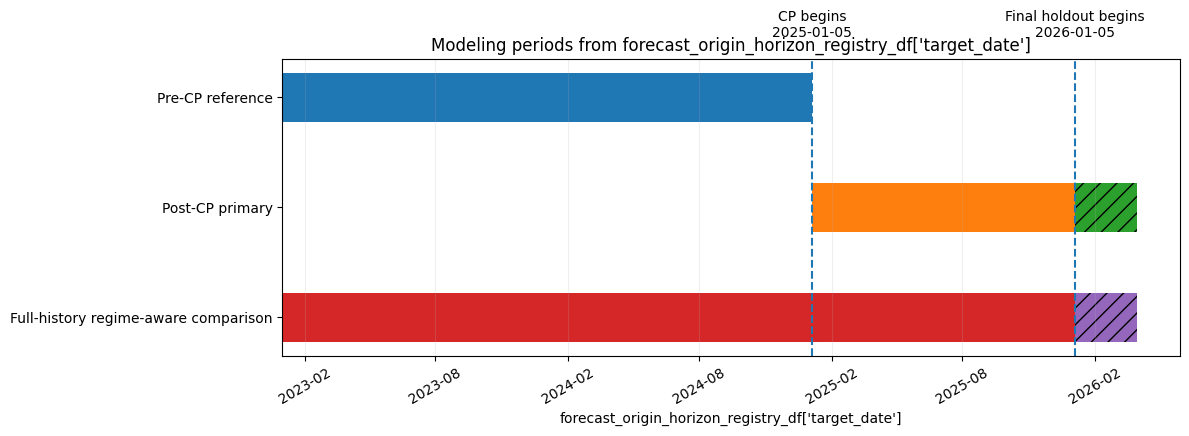

In [8]:
# 4.1.2.2E — Visualize the modeling periods and final holdout
#
# The chart uses the same target-date boundaries encoded in
# forecast_origin_horizon_registry_df rather than introducing a separate set of
# plotting dates.
#
# The striped segment represents the final post-CP holdout. It appears only on
# the two ordinary post-CP forecasting tracks; the pre-CP reference stops before
# congestion pricing begins.

first_target_date = (
    forecast_origin_horizon_registry_df[
        "target_date"
    ].min()
)

pre_cp_end = (
    CP_START_DATE - pd.Timedelta(days=1)
)

post_cp_development_end = (
    FINAL_HOLDOUT_START - pd.Timedelta(days=1)
)

timeline_rows = {
    "Pre-CP reference": 2,
    "Post-CP primary": 1,
    "Full-history regime-aware comparison": 0,
}

fig, ax = plt.subplots(
    figsize=(12, 4.5)
)

def draw_timeline_segment(
    y_position,
    start_date,
    end_date,
    hatch=None,
):
    left = mdates.date2num(start_date)
    width = (
        mdates.date2num(
            end_date + pd.Timedelta(days=1)
        )
        - left
    )

    ax.barh(
        y_position,
        width,
        left=left,
        height=0.45,
        hatch=hatch,
    )

draw_timeline_segment(
    timeline_rows["Pre-CP reference"],
    first_target_date,
    pre_cp_end,
)

draw_timeline_segment(
    timeline_rows["Post-CP primary"],
    CP_START_DATE,
    post_cp_development_end,
)

draw_timeline_segment(
    timeline_rows["Post-CP primary"],
    FINAL_HOLDOUT_START,
    FINAL_HOLDOUT_END,
    hatch="//",
)

draw_timeline_segment(
    timeline_rows[
        "Full-history regime-aware comparison"
    ],
    first_target_date,
    post_cp_development_end,
)

draw_timeline_segment(
    timeline_rows[
        "Full-history regime-aware comparison"
    ],
    FINAL_HOLDOUT_START,
    FINAL_HOLDOUT_END,
    hatch="//",
)

ax.axvline(
    mdates.date2num(CP_START_DATE),
    linestyle="--",
)

ax.axvline(
    mdates.date2num(FINAL_HOLDOUT_START),
    linestyle="--",
)

ax.text(
    mdates.date2num(CP_START_DATE),
    2.55,
    "CP begins\n2025-01-05",
    ha="center",
)

ax.text(
    mdates.date2num(FINAL_HOLDOUT_START),
    2.55,
    "Final holdout begins\n2026-01-05",
    ha="center",
)

ax.set_yticks(
    list(timeline_rows.values())
)

ax.set_yticklabels(
    list(timeline_rows.keys())
)

ax.xaxis_date()

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=6)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y-%m")
)

ax.set_xlabel(
    "forecast_origin_horizon_registry_df['target_date']"
)

ax.set_title(
    "Modeling periods from "
    "forecast_origin_horizon_registry_df['target_date']"
)

ax.grid(
    axis="x",
    alpha=0.2,
)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Findings\. The modeling timeline cleanly separates the three forecasting roles\. The pre\-CP reference remains entirely before congestion pricing, the post\-CP primary uses the congestion\-pricing regime, and the full\-history regime\-aware comparison spans both historical regimes\. The post\-CP primary and full\-history comparison share the same January–March 2026 holdout, providing a common final evaluation period for comparing whether the additional pre\-CP history improves ordinary post\-CP forecasting\.

### Section Summary

The three forecasting tracks now have distinct historical roles but share one common forecast-origin × horizon calendar. The pre-CP reference remains isolated before January 5, 2025, the post-CP primary focuses on mobility under congestion pricing, and the full-history regime-aware comparison can draw on both periods while later models explicitly identify the policy regime. Target-based period assignment correctly handles forecasts that cross the CP and final-holdout boundaries, while the January 5–March 31, 2026 holdout remains identical for the two ordinary post-CP forecasting comparisons.

---

## 4.1.2.3 Construct Rolling Forecast Origins

A **rolling forecast origin** recreates how forecasting would work through time. At each origin, the model can use only observations that have already occurred. The next origin then moves forward by one canonical daypart timestep, allowing the available history to expand as new observations arrive.

The horizon still matters because the same origin can support several different future predictions. If AM Peak is the latest available observation, `h=1` predicts Midday, `h=2` predicts PM Peak, and `h=5` predicts the next day's AM Peak. None of the observations after the AM Peak origin may be used as predictors for any of those forecasts, even when they occur before the longer-horizon target.

`4.1.2.2` established the **master forecast calendar**—the valid forecast origins, their `h=1`, `h=2`, and `h=5` targets, and the period in which each target occurs. This chapter uses that calendar to build the actual backtest design. We first inspect how much pre-CP and post-CP history is available, then choose the initial training periods and rolling cadence, and finally construct the forecast origins that will actually be used for validation.

By the end of this chapter, `rolling_origin_registry_df` will identify the backtest schedule at **modeling track × forecast origin × horizon**, including whether each origin belongs to initial training, rolling validation, or the final holdout. The post-CP primary and full-history regime-aware comparison will use the **same post-CP validation origins and targets**, so their performance can be compared directly; they differ only in how much historical data each model may use. The pre-CP reference will use its own validation calendar entirely before congestion pricing begins.

### From Forecast Calendar to Rolling Backtest Schedule

`4.1.2.2` defines every valid **origin × horizon → target** relationship. `4.1.2.3` keeps those same temporal keys and assigns them to the actual backtest.

---

#### End of 4.1.2.2 — `forecast_origin_horizon_registry_df`

The master forecast calendar contains **one row per valid `observation_sequence_id × horizon`**. No training, validation, or holdout stage has been assigned yet.

| `observation_sequence_id` | `date` | `daypart` | `horizon` | `target_observation_sequence_id` | `target_date` | `target_daypart` | `target_period` |
|---:|---|---|---:|---:|---|---|---|
| 4772 | 2025-08-12 | `am_peak` | 1 | 4773 | 2025-08-12 | `midday` | `post_cp_development` |
| 4772 | 2025-08-12 | `am_peak` | 2 | 4774 | 2025-08-12 | `pm_peak` | `post_cp_development` |
| 4772 | 2025-08-12 | `am_peak` | 5 | 4777 | 2025-08-13 | `am_peak` | `post_cp_development` |
| 5500 | 2026-01-04 | `evening` | 1 | 5501 | 2026-01-05 | `overnight` | `final_post_cp_holdout` |

**What this table says:** which forecasts could exist, where each forecast starts, and when each `h=1`, `h=2`, and `h=5` target occurs.

↓

**Apply the rolling-validation design**

Rolling cadence advances **one canonical daypart timestep at a time**.

---

#### End of 4.1.2.3 — `rolling_origin_registry_df`

**Selected columns from the planned backtest schedule.**

The registry preserves each **origin / horizon / target relationship** and adds `modeling_track` and `stage`. `target_period` is retained separately because policy period and backtest stage are not the same concept.

| `modeling_track` | `stage` | `observation_sequence_id` | `date` | `daypart` | `horizon` | `target_observation_sequence_id` | `target_date` | `target_daypart` | `target_period` |
|---|---|---:|---|---|---:|---:|---|---|---|
| `post_cp_primary` | `initial_training` | 3812 | 2025-02-01 | `am_peak` | 1 | 3813 | 2025-02-01 | `midday` | `post_cp_development` |
| `pre_cp_reference` | `rolling_validation` | 1826 | 2024-01-01 | `overnight` | 1 | 1827 | 2024-01-01 | `am_peak` | `pre_cp` |
| `post_cp_primary` | `rolling_validation` | 4772 | 2025-08-12 | `am_peak` | 1 | 4773 | 2025-08-12 | `midday` | `post_cp_development` |
| `full_history_regime_aware` | `rolling_validation` | 4772 | 2025-08-12 | `am_peak` | 1 | 4773 | 2025-08-12 | `midday` | `post_cp_development` |
| `post_cp_primary` | `final_holdout` | 5500 | 2026-01-04 | `evening` | 1 | 5501 | 2026-01-05 | `overnight` | `final_post_cp_holdout` |
| `full_history_regime_aware` | `final_holdout` | 5500 | 2026-01-04 | `evening` | 1 | 5501 | 2026-01-05 | `overnight` | `final_post_cp_holdout` |

`stage` can be `initial_training`, `rolling_validation`, or `final_holdout`.

The Post-CP Primary and Full-History Regime-Aware tracks use the same **rolling-validation and final-holdout origin × horizon calendar**.

---

### Backtest Design by Modeling Track

#### Pre-CP Reference

- **Initial training:** 2023
- **Rolling validation targets:** 2024
- **After model selection:** refit the selected model on all available pre-CP history through **2025-01-04**

#### Post-CP Primary

- **Initial training history:** 2025-01-05 through 2025-04-04
- **Rolling validation targets:** 2025-04-05 through 2026-01-04
- **Final holdout targets:** 2026-01-05 through 2026-03-31

#### Full-History Regime-Aware

- **Available history:** begins 2023-01-01 and expands through each forecast origin
- **Rolling validation targets:** same as Post-CP Primary
- **Final holdout targets:** same as Post-CP Primary

> **Important boundary rule**
>
> Stage follows the **FUTURE target**, not the origin. For example, origin `5500` is **2026-01-04 Evening**. At `h=1`, its target is `5501`, **2026-01-05 Overnight**, so that forecast belongs to `final_holdout`.
>
> January 1–4, 2025 are excluded from pre-CP model selection, then added back when the selected pre-CP reference model is refit on all available pre-CP history before Chapter 6.

**Measure how much calendar history is available for rolling validation.** Summarize the candidate pre-CP and post-CP target pools at each horizon before choosing the fold schedule.

In [9]:
# 4.1.2.3A — Measure the calendar available for rolling validation
#
# The post-CP primary and full-history comparison share one validation pool.
# Their validation targets fall between January 5, 2025 and January 4, 2026,
# and the forecast origins used for that shared pool must also occur on or
# after January 5, 2025.
#
# The two models will later use the same folds and future targets so the only
# experimental difference is how much historical training data each model may
# use before each forecast origin.
#
# The pre-CP reference uses a separate validation pool containing only targets
# before January 5, 2025.
#
# No fold dates are chosen here. This block measures the available calendar so
# the first training cutoff, validation-window length, and rolling cadence can
# be selected from the actual amount of history.

rolling_validation_pool_df = pd.concat(
    [
        # Pre-CP reference: both forecast origin and target remain before CP.
        forecast_origin_horizon_registry_df.loc[
            forecast_origin_horizon_registry_df[
                "target_period"
            ].eq("pre_cp")
        ],

        # Shared post-CP validation pool: the target belongs to the post-CP
        # development period and the forecast itself originates after CP begins.
        forecast_origin_horizon_registry_df.loc[
            forecast_origin_horizon_registry_df[
                "target_period"
            ].eq("post_cp_development")
            & forecast_origin_horizon_registry_df[
                "date"
            ].ge(CP_START_DATE)
        ],
    ],
    ignore_index=True,
)

# Label the two validation calendars so they can be summarized together while
# remaining clearly separated in the output and subsequent visualization.
rolling_validation_pool_df["validation_pool"] = np.where(
    rolling_validation_pool_df[
        "target_period"
    ].eq("post_cp_development"),
    "Post-CP shared validation pool",
    "Pre-CP reference validation pool",
)

rolling_validation_span_df = (
    rolling_validation_pool_df
    .groupby(
        [
            "validation_pool",
            "horizon",
        ],
        as_index=False,
    )
    .agg(
        first_origin_date=(
            "date",
            "min",
        ),
        last_origin_date=(
            "date",
            "max",
        ),
        first_target_date=(
            "target_date",
            "min",
        ),
        last_target_date=(
            "target_date",
            "max",
        ),
        distinct_target_dates=(
            "target_date",
            "nunique",
        ),
        distinct_forecast_origins=(
            "observation_sequence_id",
            "nunique",
        ),
    )
)

rolling_validation_span_df[
    "calendar_span_days"
] = (
    rolling_validation_span_df[
        "last_target_date"
    ]
    - rolling_validation_span_df[
        "first_target_date"
    ]
).dt.days + 1

display(rolling_validation_span_df)

,validation_pool,horizon,first_origin_date,last_origin_date,first_target_date,last_target_date,distinct_target_dates,distinct_forecast_origins,calendar_span_days
0,Post-CP shared validation pool,1,2025-01-05,2026-01-04,2025-01-05,2026-01-04,365,1824,365
1,Post-CP shared validation pool,2,2025-01-05,2026-01-04,2025-01-05,2026-01-04,365,1823,365
2,Post-CP shared validation pool,5,2025-01-05,2026-01-03,2025-01-06,2026-01-04,364,1820,364
3,Pre-CP reference validation pool,1,2023-01-01,2025-01-04,2023-01-01,2025-01-04,735,3674,735
4,Pre-CP reference validation pool,2,2023-01-01,2025-01-04,2023-01-01,2025-01-04,735,3673,735
5,Pre-CP reference validation pool,5,2023-01-01,2025-01-03,2023-01-02,2025-01-04,734,3670,734


Findings\. The pre\-CP reference provides roughly two years of candidate rolling\-validation history, with 3,674 h=1, 3,673 h=2, and 3,670 h=5 forecast origins\. The shared post\-CP validation pool provides almost one full year, with 1,824, 1,823, and 1,820 valid origins respectively after requiring the forecast origin itself to occur on or after January 5, 2025\. The longer horizons lose only the sequence positions that cannot be formed at the beginning of each regime, leaving substantial chronological history for rolling backtests at all three horizons\.

**Visualize the candidate validation pools by horizon.** Show the actual `first_target_date` → `last_target_date` ranges that are available for the pre-CP and post-CP rolling-validation schedules.

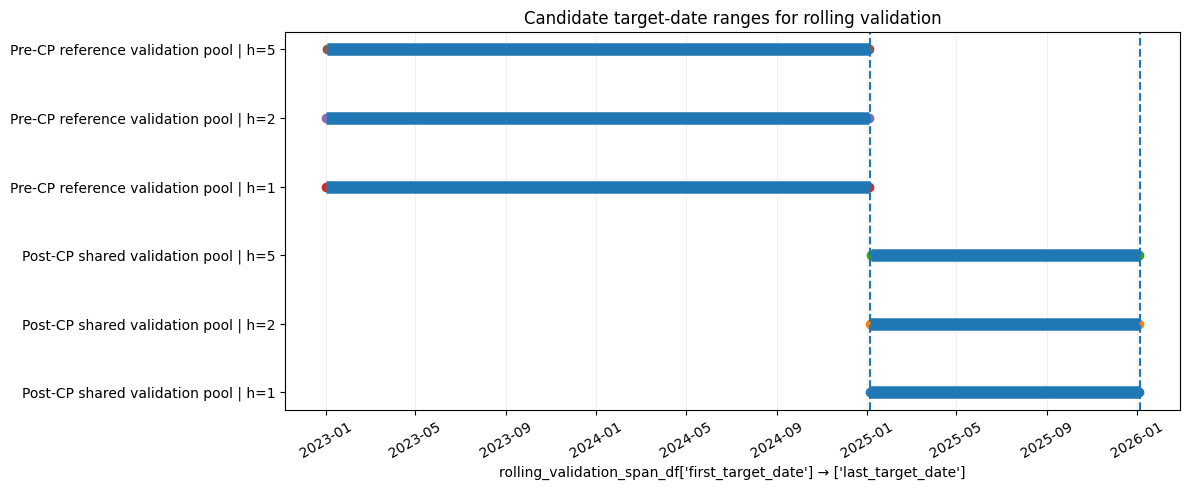

In [10]:
# 4.1.2.3B — Visualize the candidate rolling-validation pools
#
# Each row represents one validation pool at one forecasting horizon.
# The chart uses rolling_validation_span_df directly so the visible ranges are
# the same dates measured in the diagnostic table above.
#
# This view makes it easier to judge how many folds can fit into each period
# without choosing the rolling schedule prematurely.

validation_plot_df = (
    rolling_validation_span_df
    .sort_values(
        [
            "validation_pool",
            "horizon",
        ]
    )
    .reset_index(drop=True)
    .copy()
)

validation_plot_df[
    "plot_label"
] = (
    validation_plot_df[
        "validation_pool"
    ]
    + " | h="
    + validation_plot_df[
        "horizon"
    ].astype(str)
)

fig, ax = plt.subplots(
    figsize=(12, 5)
)

for row_number, row in (
    validation_plot_df.iterrows()
):
    ax.hlines(
        y=row_number,
        xmin=row["first_target_date"],
        xmax=row["last_target_date"],
        linewidth=9,
    )

    ax.scatter(
        [
            row["first_target_date"],
            row["last_target_date"],
        ],
        [
            row_number,
            row_number,
        ],
    )

ax.axvline(
    CP_START_DATE,
    linestyle="--",
)

ax.axvline(
    FINAL_HOLDOUT_START,
    linestyle="--",
)

ax.set_yticks(
    range(len(validation_plot_df))
)

ax.set_yticklabels(
    validation_plot_df["plot_label"]
)

ax.set_xlabel(
    "rolling_validation_span_df"
    "['first_target_date'] → ['last_target_date']"
)

ax.set_title(
    "Candidate target-date ranges for rolling validation"
)

ax.grid(
    axis="x",
    alpha=0.2,
)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Findings\. The validation\-pool timeline shows enough chronological depth to support repeated rolling evaluation in both regimes\. The pre\-CP reference has the longer development window, while the shared post\-CP pool provides nearly a full year before the untouched 2026 holdout\. The three horizons cover almost identical calendar ranges, with only the expected slight delay for h=5, so a common rolling\-validation design can reasonably be used across horizons rather than creating a separate fold schedule for each prediction distance\.

> ✅ Decision — Rolling validation design

Use expanding training windows with a rolling cadence of one canonical daypart timestep\. At each successive observation\_sequence\_id, the model may use only information available through that forecast origin, while the h=1, h=2, and h=5 targets remain future observations\.

\* For the Post\-CP Primary track, use January 5–April 4, 2025 as the initial post\-CP training period, then begin rolling validation on April 5, 2025 and continue through January 4, 2026\.
\* The Full\-History Regime\-Aware track uses the same post\-CP rolling\-validation origin × horizon calendar as the Post\-CP Primary, but may use all available historical observations beginning in 2023\. This allows recurring pre\-CP signals to contribute while later models explicitly represent the congestion\-pricing regime change\.
\* For the Pre\-CP Reference track, use 2023 as the initial training period and the full 2024 calendar year for rolling validation\. January 1–4, 2025 are excluded from model selection, then added back when the selected pre\-CP model is refit on all available pre\-CP history before Chapter 6\.
\* The January 5–March 31, 2026 final holdout remains untouched during model development and selection\. Backtest stage follows the future target date, not the forecast\-origin date\.

Findings\. The candidate\-calendar timeline confirms that both modeling regimes have enough temporal depth to support expanding\-window validation rather than a small set of coarse folds\. The pre\-CP reference provides nearly two full years of candidate target history, while the post\-CP calendar provides almost one complete year before the untouched 2026 holdout\. Coverage across h=1, h=2, and h=5 is nearly identical, so the same rolling cadence can be used across all three prediction distances without materially shortening the available evaluation period\.

The rolling\-validation decision now fixes how the available forecasting calendar will be used\. The Pre\-CP Reference uses 2023 for initial training and 2024 for rolling validation\. The Post\-CP Primary uses January 5–April 4, 2025 for initial training before rolling validation begins with April 5 targets\. The Full\-History Regime\-Aware track uses that same post\-CP validation calendar while retaining access to the longer history beginning in 2023\.

The remaining work in this chapter is to apply those boundaries to \`forecast\_origin\_horizon\_registry\_df\`\. The resulting \`rolling\_origin\_registry\_df\` will preserve every selected origin, horizon, and future target while adding the \`modeling\_track\` and \`stage\` needed by downstream backtests\.

**Encode the selected backtest boundaries.** Store the date boundaries that will drive the three modeling tracks. These constants are execution rules rather than descriptive metadata: they determine which origin × horizon rows are assigned to initial training, rolling validation, and final holdout in the next block.

In [11]:
# 4.1.2.3C — Encode the selected backtest boundaries
#
# These dates implement the rolling-validation decision directly.
#
# Pre-CP Reference:
#   - 2023 supplies the initial supervised training examples.
#   - Targets throughout calendar year 2024 are used for rolling validation.
#   - January 1–4, 2025 are intentionally excluded from model selection and
#     will later be added back when the selected pre-CP model is refit.
#
# Post-CP Primary:
#   - The first ~90 days after congestion pricing provide initial training.
#   - Targets beginning April 5, 2025 enter rolling validation.
#   - January 5–March 31, 2026 remains the untouched final holdout.
#
# Full-History Regime-Aware:
#   - Uses the same post-CP validation and holdout target boundaries as the
#     Post-CP Primary, but can draw on the longer history beginning in 2023.

PRE_CP_INITIAL_TRAINING_END = pd.Timestamp("2023-12-31")

PRE_CP_VALIDATION_START = pd.Timestamp("2024-01-01")
PRE_CP_VALIDATION_END = pd.Timestamp("2024-12-31")

PRE_CP_REFIT_END = pd.Timestamp("2025-01-04")

POST_CP_INITIAL_TRAINING_END = pd.Timestamp("2025-04-04")

POST_CP_VALIDATION_START = pd.Timestamp("2025-04-05")
POST_CP_VALIDATION_END = pd.Timestamp("2026-01-04")

assert PRE_CP_INITIAL_TRAINING_END < PRE_CP_VALIDATION_START
assert PRE_CP_VALIDATION_END < PRE_CP_REFIT_END
assert CP_START_DATE <= POST_CP_INITIAL_TRAINING_END
assert POST_CP_INITIAL_TRAINING_END < POST_CP_VALIDATION_START
assert POST_CP_VALIDATION_END < FINAL_HOLDOUT_START

Build the rolling backtest schedule\. Start from the master origin × horizon calendar created in 4\.1\.2\.2 and assign rows to the three modeling tracks\. Stage membership follows the future target\_date, while each track also enforces the history it is allowed to use\. The Post\-CP Primary therefore cannot use an origin from before January 5, 2025 even when that origin predicts a post\-CP target\.

In [12]:
# 4.1.2.3D — Build the rolling backtest schedule
#
# forecast_origin_horizon_registry_df already defines every valid temporal
# relationship:
#
#   forecast origin -> horizon -> future target
#
# This block does not rebuild those relationships. It selects the rows used by
# each forecasting experiment and adds two fields:
#
#   modeling_track -> which experiment uses the row
#   stage          -> how the row is used within that experiment
#
# A single origin × horizon row can legitimately appear in multiple tracks.
# For example, the Post-CP Primary and Full-History Regime-Aware tracks use the
# same post-CP validation target calendar but differ in the historical data
# available to the model at that origin.

def assign_track_stage(
    source_df,
    modeling_track,
    stage,
    mask,
):
    selected_df = source_df.loc[mask].copy()

    selected_df.insert(
        0,
        "stage",
        stage,
    )

    selected_df.insert(
        0,
        "modeling_track",
        modeling_track,
    )

    return selected_df


target_dates = (
    forecast_origin_horizon_registry_df[
        "target_date"
    ]
)

origin_dates = (
    forecast_origin_horizon_registry_df[
        "date"
    ]
)

rolling_schedule_frames = []


# ------------------------------------------------------------------
# Pre-CP Reference
# ------------------------------------------------------------------
#
# The reference experiment uses 2023 targets for initial training and
# 2024 targets for rolling validation. January 1–4, 2025 are deliberately
# omitted from model selection and will be restored only during the final
# pre-CP refit before Chapter 6.

rolling_schedule_frames.append(
    assign_track_stage(
        forecast_origin_horizon_registry_df,
        modeling_track="pre_cp_reference",
        stage="initial_training",
        mask=target_dates.le(
            PRE_CP_INITIAL_TRAINING_END
        ),
    )
)

rolling_schedule_frames.append(
    assign_track_stage(
        forecast_origin_horizon_registry_df,
        modeling_track="pre_cp_reference",
        stage="rolling_validation",
        mask=target_dates.between(
            PRE_CP_VALIDATION_START,
            PRE_CP_VALIDATION_END,
            inclusive="both",
        ),
    )
)


# ------------------------------------------------------------------
# Post-CP Primary
# ------------------------------------------------------------------
#
# This track is intentionally restricted to the congestion-pricing regime.
# In addition to the target-date stage boundaries, every forecast origin must
# itself occur on or after January 5, 2025.
#
# This origin restriction matters at the CP boundary because the master
# calendar contains a few post-CP targets whose h=1 / h=2 / h=5 origins still
# occur on January 4.

post_cp_origin_ok = origin_dates.ge(
    CP_START_DATE
)

rolling_schedule_frames.append(
    assign_track_stage(
        forecast_origin_horizon_registry_df,
        modeling_track="post_cp_primary",
        stage="initial_training",
        mask=(
            target_dates.between(
                CP_START_DATE,
                POST_CP_INITIAL_TRAINING_END,
                inclusive="both",
            )
            & post_cp_origin_ok
        ),
    )
)

rolling_schedule_frames.append(
    assign_track_stage(
        forecast_origin_horizon_registry_df,
        modeling_track="post_cp_primary",
        stage="rolling_validation",
        mask=(
            target_dates.between(
                POST_CP_VALIDATION_START,
                POST_CP_VALIDATION_END,
                inclusive="both",
            )
            & post_cp_origin_ok
        ),
    )
)

rolling_schedule_frames.append(
    assign_track_stage(
        forecast_origin_horizon_registry_df,
        modeling_track="post_cp_primary",
        stage="final_holdout",
        mask=(
            target_dates.between(
                FINAL_HOLDOUT_START,
                FINAL_HOLDOUT_END,
                inclusive="both",
            )
            & post_cp_origin_ok
        ),
    )
)


# ------------------------------------------------------------------
# Full-History Regime-Aware
# ------------------------------------------------------------------
#
# This comparison receives the full historical calendar beginning in 2023.
# Its validation and holdout calendars intentionally match the Post-CP Primary
# so that later performance comparisons use the same forecast timings.
#
# No CP-era origin restriction is applied to its historical training rows.

rolling_schedule_frames.append(
    assign_track_stage(
        forecast_origin_horizon_registry_df,
        modeling_track="full_history_regime_aware",
        stage="initial_training",
        mask=target_dates.le(
            POST_CP_INITIAL_TRAINING_END
        ),
    )
)

rolling_schedule_frames.append(
    assign_track_stage(
        forecast_origin_horizon_registry_df,
        modeling_track="full_history_regime_aware",
        stage="rolling_validation",
        mask=target_dates.between(
            POST_CP_VALIDATION_START,
            POST_CP_VALIDATION_END,
            inclusive="both",
        ),
    )
)

rolling_schedule_frames.append(
    assign_track_stage(
        forecast_origin_horizon_registry_df,
        modeling_track="full_history_regime_aware",
        stage="final_holdout",
        mask=target_dates.between(
            FINAL_HOLDOUT_START,
            FINAL_HOLDOUT_END,
            inclusive="both",
        ),
    )
)


# Stack all track-specific schedules into one reusable registry.
#
# The temporal columns remain unchanged from the master forecast calendar.
# Duplicated origin × horizon rows across modeling tracks are intentional;
# duplicated rows within the same modeling track are not.
rolling_origin_registry_df = (
    pd.concat(
        rolling_schedule_frames,
        ignore_index=True,
    )
    .sort_values(
        [
            "modeling_track",
            "target_date",
            "target_daypart_order",
            "horizon",
            "observation_sequence_id",
        ]
    )
    .reset_index(drop=True)
)

print(
    "rolling_origin_registry_df:",
    f"{len(rolling_origin_registry_df):,} "
    "track × origin × horizon rows",
)

rolling_origin_registry_df: 35,496 track × origin × horizon rows


Validate the rolling schedule before using it downstream\. Check that horizon arithmetic remains intact, no origin × horizon row is assigned twice within the same track, the Post\-CP Primary never uses a pre\-CP forecast origin, the Pre\-CP Reference stays out of the post\-CP period, and the two post\-CP comparison tracks use identical rolling\-validation and final\-holdout calendars\.

In [13]:
# 4.1.2.3E — Validate the rolling backtest schedule
#
# The rolling registry adds track and stage assignments to the master calendar,
# but must not change the underlying forecast relationships.
#
# These checks focus on the failure modes that would invalidate a later
# backtest:
#
#   - duplicated forecasts inside one modeling track
#   - broken origin -> horizon -> target arithmetic
#   - pre-CP information entering the Post-CP Primary
#   - post-CP targets entering the Pre-CP Reference
#   - different evaluation calendars for the two post-CP comparison tracks

rolling_key = [
    "modeling_track",
    "observation_sequence_id",
    "horizon",
]

duplicate_rolling_rows = int(
    rolling_origin_registry_df.duplicated(
        rolling_key
    ).sum()
)

horizon_alignment_ok = (
    rolling_origin_registry_df[
        "target_observation_sequence_id"
    ]
    ==
    rolling_origin_registry_df[
        "observation_sequence_id"
    ]
    +
    rolling_origin_registry_df[
        "horizon"
    ]
).all()

post_cp_primary_df = (
    rolling_origin_registry_df.loc[
        rolling_origin_registry_df[
            "modeling_track"
        ].eq("post_cp_primary")
    ]
)

post_cp_origin_boundary_ok = (
    post_cp_primary_df["date"]
    .ge(CP_START_DATE)
    .all()
)

pre_cp_reference_df = (
    rolling_origin_registry_df.loc[
        rolling_origin_registry_df[
            "modeling_track"
        ].eq("pre_cp_reference")
    ]
)

pre_cp_reference_boundary_ok = (
    pre_cp_reference_df[
        "target_date"
    ]
    .le(PRE_CP_VALIDATION_END)
    .all()
)

pre_cp_refit_gap_absent = (
    ~pre_cp_reference_df[
        "target_date"
    ].between(
        pd.Timestamp("2025-01-01"),
        PRE_CP_REFIT_END,
        inclusive="both",
    )
).all()

comparison_calendar_key = [
    "observation_sequence_id",
    "horizon",
    "target_observation_sequence_id",
    "target_date",
    "target_daypart",
]

post_validation_calendar = set(
    map(
        tuple,
        rolling_origin_registry_df.loc[
            rolling_origin_registry_df[
                "modeling_track"
            ].eq("post_cp_primary")
            & rolling_origin_registry_df[
                "stage"
            ].eq("rolling_validation"),
            comparison_calendar_key,
        ].to_numpy(),
    )
)

full_validation_calendar = set(
    map(
        tuple,
        rolling_origin_registry_df.loc[
            rolling_origin_registry_df[
                "modeling_track"
            ].eq("full_history_regime_aware")
            & rolling_origin_registry_df[
                "stage"
            ].eq("rolling_validation"),
            comparison_calendar_key,
        ].to_numpy(),
    )
)

post_holdout_calendar = set(
    map(
        tuple,
        rolling_origin_registry_df.loc[
            rolling_origin_registry_df[
                "modeling_track"
            ].eq("post_cp_primary")
            & rolling_origin_registry_df[
                "stage"
            ].eq("final_holdout"),
            comparison_calendar_key,
        ].to_numpy(),
    )
)

full_holdout_calendar = set(
    map(
        tuple,
        rolling_origin_registry_df.loc[
            rolling_origin_registry_df[
                "modeling_track"
            ].eq("full_history_regime_aware")
            & rolling_origin_registry_df[
                "stage"
            ].eq("final_holdout"),
            comparison_calendar_key,
        ].to_numpy(),
    )
)

shared_validation_calendar_ok = (
    post_validation_calendar
    == full_validation_calendar
)

shared_holdout_calendar_ok = (
    post_holdout_calendar
    == full_holdout_calendar
)

rolling_schedule_validation_df = pd.DataFrame(
    [
        {
            "check": "Duplicate track × origin × horizon rows",
            "result": duplicate_rolling_rows,
            "expected": 0,
        },
        {
            "check": "Target sequence ID = origin ID + horizon",
            "result": horizon_alignment_ok,
            "expected": True,
        },
        {
            "check": "Post-CP Primary origins remain post-CP",
            "result": post_cp_origin_boundary_ok,
            "expected": True,
        },
        {
            "check": "Pre-CP Reference targets remain in 2023–2024",
            "result": pre_cp_reference_boundary_ok,
            "expected": True,
        },
        {
            "check": "Jan 1–4, 2025 absent from pre-CP model selection",
            "result": pre_cp_refit_gap_absent,
            "expected": True,
        },
        {
            "check": "Post-CP tracks share validation calendar",
            "result": shared_validation_calendar_ok,
            "expected": True,
        },
        {
            "check": "Post-CP tracks share final-holdout calendar",
            "result": shared_holdout_calendar_ok,
            "expected": True,
        },
    ]
)

assert duplicate_rolling_rows == 0
assert horizon_alignment_ok
assert post_cp_origin_boundary_ok
assert pre_cp_reference_boundary_ok
assert pre_cp_refit_gap_absent
assert shared_validation_calendar_ok
assert shared_holdout_calendar_ok

display(rolling_schedule_validation_df)

,check,result,expected
0,Duplicate track × origin × horizon rows,0,0
1,Target sequence ID = origin ID + horizon,True,True
2,Post-CP Primary origins remain post-CP,True,True
3,Pre-CP Reference targets remain in 2023–2024,True,True
4,"Jan 1–4, 2025 absent from pre-CP model selection",True,True
5,Post-CP tracks share validation calendar,True,True
6,Post-CP tracks share final-holdout calendar,True,True


Findings\. All integrity checks for the constructed rolling schedule pass\. There are zero duplicate modeling\_track × observation\_sequence\_id × horizon rows, every future target sequence ID equals its origin sequence ID plus the stated horizon, and the Post\-CP Primary contains no forecast origins before January 5, 2025\. The Pre\-CP Reference remains confined to 2023–2024 model\-selection targets, with January 1–4, 2025 correctly excluded for later refitting, while the Post\-CP Primary and Full\-History Regime\-Aware tracks have identical rolling\-validation and final\-holdout origin × horizon calendars\. The resulting schedule therefore preserves the intended temporal ordering and leakage boundaries\.

Summarize the completed backtest calendar\. Count the origin × horizon rows assigned to each track and stage and show their actual temporal extent\. This confirms how much initial\-training, rolling\-validation, and final\-holdout calendar each experiment carries before Taxi Zone × Metric eligibility is applied\.

In [14]:
# 4.1.2.3F — Summarize the completed backtest calendar
#
# rolling_origin_registry_df is still purely temporal: it says which forecast
# timings belong to each modeling experiment, but it has not yet filtered Taxi
# Zone × Metric sequences according to observed-data support.
#
# Summarizing by track and stage therefore shows the common backtest calendar
# before sequence eligibility changes the modeling population.

rolling_schedule_summary_df = (
    rolling_origin_registry_df
    .groupby(
        [
            "modeling_track",
            "stage",
        ],
        as_index=False,
    )
    .agg(
        origin_horizon_rows=(
            "observation_sequence_id",
            "size",
        ),
        distinct_forecast_origins=(
            "observation_sequence_id",
            "nunique",
        ),
        first_origin_date=(
            "date",
            "min",
        ),
        last_origin_date=(
            "date",
            "max",
        ),
        first_target_date=(
            "target_date",
            "min",
        ),
        last_target_date=(
            "target_date",
            "max",
        ),
    )
)

display(rolling_schedule_summary_df)

,modeling_track,stage,origin_horizon_rows,distinct_forecast_origins,first_origin_date,last_origin_date,first_target_date,last_target_date
0,full_history_regime_aware,final_holdout,1290,434,2026-01-04,2026-03-31,2026-01-05,2026-03-31
1,full_history_regime_aware,initial_training,12367,4124,2023-01-01,2025-04-04,2023-01-01,2025-04-04
2,full_history_regime_aware,rolling_validation,4125,1379,2025-04-04,2026-01-04,2025-04-05,2026-01-04
3,post_cp_primary,final_holdout,1290,434,2026-01-04,2026-03-31,2026-01-05,2026-03-31
4,post_cp_primary,initial_training,1342,449,2025-01-05,2025-04-04,2025-01-05,2025-04-04
5,post_cp_primary,rolling_validation,4125,1379,2025-04-04,2026-01-04,2025-04-05,2026-01-04
6,pre_cp_reference,initial_training,5467,1824,2023-01-01,2023-12-31,2023-01-01,2023-12-31
7,pre_cp_reference,rolling_validation,5490,1834,2023-12-31,2024-12-31,2024-01-01,2024-12-31


Findings\. The completed temporal backtest schedule contains 35,496 track × origin × horizon rows and reflects the different historical roles of the three modeling tracks\. The Pre\-CP Reference contributes 5,467 initial\-training rows and 5,490 rolling\-validation rows\. The Post\-CP Primary contributes 1,342 initial\-training rows, 4,125 rolling\-validation rows, and 1,290 final\-holdout rows, while the Full\-History Regime\-Aware track uses the same 4,125 validation and 1,290 holdout rows but has 12,367 initial\-training rows because it can draw on history beginning in 2023\. The two post\-CP tracks therefore differ in available historical information while remaining temporally aligned on the forecasts used for model comparison\.

Preview the schedule at row level\. Show representative rows from initial training, pre\-CP rolling validation, shared post\-CP rolling validation, and the final holdout\. The preview makes the two added fields—modeling\_track and stage—concrete while preserving the origin, horizon, and target fields carried forward from 4\.1\.2\.2\.

In [15]:
# 4.1.2.3G — Preview representative rolling-schedule rows
#
# Select examples semantically from the constructed registry rather than
# hard-coding sequence IDs. This lets the table expose the actual canonical
# IDs generated by the source calendar while keeping the examples easy to
# interpret.

preview_masks = [
    (
        rolling_origin_registry_df[
            "modeling_track"
        ].eq("post_cp_primary")
        & rolling_origin_registry_df[
            "stage"
        ].eq("initial_training")
        & rolling_origin_registry_df[
            "date"
        ].eq(pd.Timestamp("2025-02-01"))
        & rolling_origin_registry_df[
            "daypart"
        ].eq("am_peak")
        & rolling_origin_registry_df[
            "horizon"
        ].eq(1)
    ),
    (
        rolling_origin_registry_df[
            "modeling_track"
        ].eq("pre_cp_reference")
        & rolling_origin_registry_df[
            "stage"
        ].eq("rolling_validation")
        & rolling_origin_registry_df[
            "date"
        ].eq(pd.Timestamp("2024-01-01"))
        & rolling_origin_registry_df[
            "daypart"
        ].eq("overnight")
        & rolling_origin_registry_df[
            "horizon"
        ].eq(1)
    ),
    (
        rolling_origin_registry_df[
            "modeling_track"
        ].eq("post_cp_primary")
        & rolling_origin_registry_df[
            "stage"
        ].eq("rolling_validation")
        & rolling_origin_registry_df[
            "date"
        ].eq(pd.Timestamp("2025-08-12"))
        & rolling_origin_registry_df[
            "daypart"
        ].eq("am_peak")
        & rolling_origin_registry_df[
            "horizon"
        ].isin([1, 5])
    ),
    (
        rolling_origin_registry_df[
            "modeling_track"
        ].eq("full_history_regime_aware")
        & rolling_origin_registry_df[
            "stage"
        ].eq("rolling_validation")
        & rolling_origin_registry_df[
            "date"
        ].eq(pd.Timestamp("2025-08-12"))
        & rolling_origin_registry_df[
            "daypart"
        ].eq("am_peak")
        & rolling_origin_registry_df[
            "horizon"
        ].eq(1)
    ),
    (
        rolling_origin_registry_df[
            "stage"
        ].eq("final_holdout")
        & rolling_origin_registry_df[
            "date"
        ].eq(pd.Timestamp("2026-01-04"))
        & rolling_origin_registry_df[
            "daypart"
        ].eq("evening")
        & rolling_origin_registry_df[
            "horizon"
        ].eq(1)
    ),
]

rolling_schedule_preview_df = (
    rolling_origin_registry_df.loc[
        np.logical_or.reduce(
            preview_masks
        ),
        [
            "modeling_track",
            "stage",
            "observation_sequence_id",
            "date",
            "daypart",
            "horizon",
            "target_observation_sequence_id",
            "target_date",
            "target_daypart",
            "target_period",
        ],
    ]
    .sort_values(
        [
            "stage",
            "modeling_track",
            "date",
            "horizon",
        ]
    )
    .reset_index(drop=True)
)

display(rolling_schedule_preview_df)

,modeling_track,stage,observation_sequence_id,date,daypart,horizon,target_observation_sequence_id,target_date,target_daypart,target_period
0,full_history_regime_aware,final_holdout,5500,2026-01-04,evening,1,5501,2026-01-05,overnight,final_post_cp_holdout
1,post_cp_primary,final_holdout,5500,2026-01-04,evening,1,5501,2026-01-05,overnight,final_post_cp_holdout
2,post_cp_primary,initial_training,3812,2025-02-01,am_peak,1,3813,2025-02-01,midday,post_cp_development
3,full_history_regime_aware,rolling_validation,4772,2025-08-12,am_peak,1,4773,2025-08-12,midday,post_cp_development
4,post_cp_primary,rolling_validation,4772,2025-08-12,am_peak,1,4773,2025-08-12,midday,post_cp_development
5,post_cp_primary,rolling_validation,4772,2025-08-12,am_peak,5,4777,2025-08-13,am_peak,post_cp_development
6,pre_cp_reference,rolling_validation,1826,2024-01-01,overnight,1,1827,2024-01-01,am_peak,pre_cp


Findings\. The row\-level preview confirms that the track and stage assignments preserve the underlying forecast relationships exactly\. A Post\-CP Primary training example at sequence position 3812 predicts Midday from the February 1, 2025 AM Peak origin; a Pre\-CP Reference validation example at position 1826 predicts the January 1, 2024 AM Peak from Overnight; and the August 12, 2025 AM Peak origin appears in both post\-CP comparison tracks on the shared rolling\-validation calendar\. The preview also verifies the boundary rule directly: the January 4, 2026 Evening origin at position 5500 predicts January 5 Overnight at h=1, so that forecast is assigned to final\_holdout in both post\-CP tracks\.

## 4.1.2.4 Construct the Post-CP-Only Track

The rolling calendar defines **when** the Post-CP Primary will train and validate, but the track also needs a fixed definition of **which Taxi Zone × Metric sequences are eligible to participate**. The 80% support rule established in `4.1.1` still applies, but eligibility must be determined using only training history legitimately available to this track.

`4.1.2.4A` showed that support changes very little as the Post-CP training window expands. Only 15 structurally available sequences become newly eligible later in validation, so we fixed eligibility at the **first rolling-validation origin**. This keeps the evaluated population constant through time while preventing later validation observations from influencing membership in the backtest.

The remaining blocks apply that decision. We first freeze the qualifying sequence cohort, then validate that later-only sequences remain excluded, and finally pair the resulting sequence population conceptually with the already constructed Post-CP origin × horizon calendar.

**By the end of this section, `post_cp_primary_sequence_registry_df` will contain the fixed Taxi Zone × Metric population for the Post-CP Primary track.** Together with the Post-CP rows of `rolling_origin_registry_df`, it will fully define both dimensions of the experiment: **which sequences are modeled and when their forecasts are evaluated**. The two registries remain separate so this setup notebook does not unnecessarily materialize a very large sequence × origin × horizon Cartesian product.

---

Measure Post\-CP sequence support at the beginning and end of rolling validation\. For every Taxi Zone × Metric sequence, calculate observed coverage using only history available through the earliest rolling\-validation origin and compare it with coverage available by the final rolling\-validation origin\. This shows whether expanding history materially changes which sequences satisfy the 80% rule\.

In [16]:
# 4.1.2.4A — Measure Post-CP support as the rolling history expands
#
# The earlier 4.1.1 post_cp_development_support_ok flag used the complete
# January 5, 2025–January 4, 2026 development period. It cannot be reused
# directly for the first rolling forecasts because those forecasts occur much
# earlier and do not yet have access to the full year's observations.
#
# For a leakage-safe comparison, identify:
#
#   first_validation_origin_id
#       The earliest sequence position from which any Post-CP rolling-
#       validation forecast is generated.
#
#   last_validation_origin_id
#       The latest forecast origin used during Post-CP rolling validation.
#
# Coverage at the first origin represents the history available when rolling
# validation begins. Coverage at the last origin shows how much eligibility
# could improve as the expanding training window accumulates observations.

MIN_TRAINING_COVERAGE = 0.80

post_cp_validation_rows_df = (
    rolling_origin_registry_df.loc[
        rolling_origin_registry_df[
            "modeling_track"
        ].eq("post_cp_primary")
        & rolling_origin_registry_df[
            "stage"
        ].eq("rolling_validation")
    ]
)

first_validation_origin_id = int(
    post_cp_validation_rows_df[
        "observation_sequence_id"
    ].min()
)

last_validation_origin_id = int(
    post_cp_validation_rows_df[
        "observation_sequence_id"
    ].max()
)

post_cp_history_start_id = int(
    forecast_sequence_df.loc[
        pd.to_datetime(
            forecast_sequence_df["date"]
        ).ge(CP_START_DATE),
        "observation_sequence_id",
    ].min()
)


def calculate_support_through_origin(
    cutoff_origin_id,
    coverage_label,
):
    history_df = (
        forecast_sequence_df.loc[
            forecast_sequence_df[
                "observation_sequence_id"
            ].between(
                post_cp_history_start_id,
                cutoff_origin_id,
                inclusive="both",
            ),
            [
                "taxi_zone_id",
                "zone",
                "borough",
                "metric",
                "forecast_sequence_id",
                "observation_sequence_id",
                "observed_value",
            ],
        ]
    )

    support_df = (
        history_df
        .groupby(
            [
                "taxi_zone_id",
                "zone",
                "borough",
                "metric",
                "forecast_sequence_id",
            ],
            as_index=False,
        )
        .agg(
            possible_rows=(
                "observation_sequence_id",
                "size",
            ),
            observed_rows=(
                "observed_value",
                "count",
            ),
        )
    )

    support_df[
        "observed_share"
    ] = (
        support_df["observed_rows"]
        / support_df["possible_rows"]
    )

    support_df = support_df.merge(
        forecast_support_df[
            [
                "forecast_sequence_id",
                "structurally_available",
            ]
        ],
        on="forecast_sequence_id",
        how="left",
        validate="one_to_one",
    )

    assert support_df[
        "structurally_available"
    ].notna().all()

    support_df[
        "support_ok"
    ] = (
        support_df[
            "structurally_available"
        ].astype(bool)
        & support_df[
            "observed_share"
        ].ge(
            MIN_TRAINING_COVERAGE
        )
    )

    return support_df.rename(
        columns={
            "possible_rows":
                f"{coverage_label}_possible_rows",
            "observed_rows":
                f"{coverage_label}_observed_rows",
            "observed_share":
                f"{coverage_label}_observed_share",
            "support_ok":
                f"{coverage_label}_support_ok",
        }
    )


first_origin_support_df = (
    calculate_support_through_origin(
        first_validation_origin_id,
        "first_origin",
    )
)

last_origin_support_df = (
    calculate_support_through_origin(
        last_validation_origin_id,
        "last_origin",
    )
)

post_cp_support_evolution_df = (
    first_origin_support_df.merge(
        last_origin_support_df[
            [
                "forecast_sequence_id",
                "last_origin_possible_rows",
                "last_origin_observed_rows",
                "last_origin_observed_share",
                "last_origin_support_ok",
            ]
        ],
        on="forecast_sequence_id",
        how="left",
        validate="one_to_one",
    )
)

post_cp_support_evolution_df[
    "becomes_eligible_later"
] = (
    ~post_cp_support_evolution_df[
        "first_origin_support_ok"
    ]
    & post_cp_support_evolution_df[
        "last_origin_support_ok"
    ]
)

post_cp_support_evolution_summary_df = (
    post_cp_support_evolution_df
    .groupby(
        "metric",
        as_index=False,
    )
    .agg(
        total_sequences=(
            "forecast_sequence_id",
            "size",
        ),
        structurally_available=(
            "structurally_available",
            "sum",
        ),
        eligible_at_first_origin=(
            "first_origin_support_ok",
            "sum",
        ),
        eligible_at_last_origin=(
            "last_origin_support_ok",
            "sum",
        ),
        becomes_eligible_later=(
            "becomes_eligible_later",
            "sum",
        ),
        median_first_origin_coverage=(
            "first_origin_observed_share",
            "median",
        ),
        median_last_origin_coverage=(
            "last_origin_observed_share",
            "median",
        ),
    )
)

display(
    post_cp_support_evolution_summary_df.style.format(
        {
            "median_first_origin_coverage": "{:.3f}",
            "median_last_origin_coverage": "{:.3f}",
        }
    )
)

,metric,total_sequences,structurally_available,eligible_at_first_origin,eligible_at_last_origin,becomes_eligible_later,median_first_origin_coverage,median_last_origin_coverage
0,fhvhv_avg_trip_speed,263,262,256,257,1,1.000,1.000
1,fhvhv_trip_count,263,263,257,258,1,1.000,1.000
2,subway_ridership,263,156,149,149,0,1.000,0.997
3,taxi_avg_trip_speed,263,262,189,201,12,0.933,0.970
4,taxi_trip_count,263,263,257,258,1,1.000,1.000


Findings\. Post\-CP sequence eligibility is highly stable as the expanding training window grows\. Of the 1,206 structurally available Taxi Zone × Metric sequences, 1,108 satisfy the 80% support rule at the first rolling\-validation origin and 1,123 satisfy it by the final origin, meaning only 15 sequences become newly eligible later\. Twelve of those 15 are taxi\_avg\_trip\_speed, whose eligible population increases from 189 to 201 as median observed coverage rises from 0\.933 to 0\.970; each of the FHVHV speed, FHVHV trip\-count, and Taxi trip\-count metrics gains only one sequence, while Subway remains unchanged at 149\. Median coverage is otherwise essentially complete throughout the validation period\. Because dynamic eligibility would add only a small number of sequences while changing the evaluated population over time, these results strongly favor fixing the eligible cohort using support available at the first rolling origin for a consistent, leakage\-safe backtest\.

> ✅ Decision — Fix sequence eligibility at the first rolling origin
Apply the 80% training\-support rule using only the history available at the first rolling\-validation origin, then keep that eligible Taxi Zone × Metric cohort fixed throughout the Post\-CP backtest\. Do not allow sequences to enter the evaluation population later as the expanding training window accumulates additional observations\.

The support diagnostic shows that this choice sacrifices very little coverage: only 15 of 1,206 structurally available sequences become newly eligible by the final rolling origin, including 12 Taxi speed sequences and only one sequence each for FHVHV speed, FHVHV trip count, and Taxi trip count\. Subway eligibility does not change\.

A fixed cohort therefore preserves a consistent apples\-to\-apples evaluation population across the entire rolling backtest while remaining fully leakage\-safe\. The expanding window may provide additional observations for model fitting, but it will not change which sequences are eligible for evaluation\.

**Freeze the Post-CP Primary sequence cohort.** Retain only the Taxi Zone × Metric sequences that are structurally available and satisfy the 80% observed-support threshold using history available at the first rolling-validation origin. This sequence registry becomes the fixed modeling population for the Post-CP Primary track.

In [17]:
# 4.1.2.4B — Freeze the Post-CP Primary sequence cohort
#
# The HITL decision above established a fixed-cohort policy:
#
#   1. Evaluate support using only information available at the first
#      Post-CP rolling-validation origin.
#   2. Retain sequences meeting the 80% observed-support threshold.
#   3. Keep that sequence population unchanged throughout rolling validation
#      and the final holdout.
#
# post_cp_support_evolution_df already contains the leakage-safe support
# calculation needed for this decision. first_origin_support_ok incorporates
# both structural availability and the 80% observed-support requirement.
#
# We deliberately do NOT use last_origin_support_ok here. Doing so would allow
# future validation-period observations to determine which sequences enter
# the backtest.

post_cp_primary_sequence_registry_df = (
    post_cp_support_evolution_df.loc[
        post_cp_support_evolution_df[
            "first_origin_support_ok"
        ],
        [
            "taxi_zone_id",
            "zone",
            "borough",
            "metric",
            "forecast_sequence_id",
            "structurally_available",
            "first_origin_possible_rows",
            "first_origin_observed_rows",
            "first_origin_observed_share",
        ],
    ]
    .copy()
)

# Add the modeling-track label because the sequence registry will later be
# combined with the corresponding registries for the other forecasting tracks.
post_cp_primary_sequence_registry_df.insert(
    0,
    "modeling_track",
    "post_cp_primary",
)

# The cutoff sequence ID records exactly when eligibility was frozen.
#
# This is executable provenance rather than descriptive metadata: downstream
# code can verify that the cohort was established at the first validation
# origin rather than from later observations.
post_cp_primary_sequence_registry_df[
    "eligibility_cutoff_observation_sequence_id"
] = first_validation_origin_id

# Rename the support fields so their meaning remains clear after this table is
# separated from the diagnostic dataframe created in 4.1.2.4A.
post_cp_primary_sequence_registry_df = (
    post_cp_primary_sequence_registry_df.rename(
        columns={
            "first_origin_possible_rows":
                "eligibility_possible_rows",
            "first_origin_observed_rows":
                "eligibility_observed_rows",
            "first_origin_observed_share":
                "eligibility_observed_share",
        }
    )
    .sort_values(
        [
            "metric",
            "taxi_zone_id",
        ]
    )
    .reset_index(drop=True)
)

post_cp_primary_cohort_summary_df = (
    post_cp_primary_sequence_registry_df
    .groupby(
        "metric",
        as_index=False,
    )
    .agg(
        eligible_sequences=(
            "forecast_sequence_id",
            "size",
        ),
        median_eligibility_coverage=(
            "eligibility_observed_share",
            "median",
        ),
        minimum_eligibility_coverage=(
            "eligibility_observed_share",
            "min",
        ),
    )
)

display(
    post_cp_primary_cohort_summary_df.style.format(
        {
            "median_eligibility_coverage": "{:.3f}",
            "minimum_eligibility_coverage": "{:.3f}",
        }
    )
)

,metric,eligible_sequences,median_eligibility_coverage,minimum_eligibility_coverage
0,fhvhv_avg_trip_speed,256,1.000,0.865
1,fhvhv_trip_count,257,1.000,0.879
2,subway_ridership,149,1.000,0.962
3,taxi_avg_trip_speed,189,0.987,0.809
4,taxi_trip_count,257,1.000,0.879


Findings\. The fixed Post\-CP Primary cohort contains 1,108 Taxi Zone × Metric sequences that satisfy both structural availability and the 80% support threshold using only history available at the first rolling\-validation origin\. Eligibility is strongest for the trip\-count and FHVHV metrics, with 256 FHVHV speed, 257 FHVHV trip\-count, 257 Taxi trip\-count, and 149 Subway sequences retained; Taxi speed is the most restrictive target with 189 eligible sequences\. Median eligibility coverage is 1\.000 for every metric except Taxi speed at 0\.987, and even the lowest retained coverage remains above the required threshold, ranging from 0\.809 for Taxi speed to 0\.962 for Subway\. The frozen cohort therefore preserves broad coverage while enforcing the leakage\-safe first\-origin eligibility rule\.

**Validate the frozen Post-CP cohort.** Confirm that every retained sequence satisfies the selected first-origin support rule, no sequence appears more than once, none of the 15 sequences that become eligible only later has entered the cohort, and the frozen population exactly reproduces the first-origin eligibility counts measured in `4.1.2.4A`.

In [18]:
# 4.1.2.4C — Validate the frozen Post-CP Primary cohort
#
# The most important property of this registry is that eligibility depends
# only on support available when rolling validation begins.
#
# In particular, sequences that cross the 80% threshold later must remain
# excluded. Their later improvement can affect neither validation membership
# nor final-holdout membership.

post_cp_cohort_duplicate_count = int(
    post_cp_primary_sequence_registry_df.duplicated(
        "forecast_sequence_id"
    ).sum()
)

post_cp_cohort_all_structurally_available = (
    post_cp_primary_sequence_registry_df[
        "structurally_available"
    ]
    .astype(bool)
    .all()
)

post_cp_cohort_all_meet_threshold = (
    post_cp_primary_sequence_registry_df[
        "eligibility_observed_share"
    ]
    .ge(MIN_TRAINING_COVERAGE)
    .all()
)

# Sequences that failed support at the first origin but became eligible later
# were identified explicitly in 4.1.2.4A. None may appear in the frozen cohort.
later_only_sequence_ids = set(
    post_cp_support_evolution_df.loc[
        post_cp_support_evolution_df[
            "becomes_eligible_later"
        ],
        "forecast_sequence_id",
    ]
)

frozen_sequence_ids = set(
    post_cp_primary_sequence_registry_df[
        "forecast_sequence_id"
    ]
)

later_only_sequences_in_frozen_cohort = len(
    later_only_sequence_ids
    & frozen_sequence_ids
)

# The total size of the frozen registry must equal the number reported as
# eligible_at_first_origin in the support-evolution diagnostic.
expected_first_origin_eligible_count = int(
    post_cp_support_evolution_summary_df[
        "eligible_at_first_origin"
    ].sum()
)

actual_frozen_cohort_count = len(
    post_cp_primary_sequence_registry_df
)

post_cp_fixed_cohort_validation_df = pd.DataFrame(
    [
        {
            "check": "Duplicate forecast_sequence_id rows",
            "result": post_cp_cohort_duplicate_count,
            "expected": 0,
        },
        {
            "check": "All retained sequences structurally available",
            "result": post_cp_cohort_all_structurally_available,
            "expected": True,
        },
        {
            "check": "All retained sequences meet first-origin 80% support",
            "result": post_cp_cohort_all_meet_threshold,
            "expected": True,
        },
        {
            "check": "Later-only eligible sequences included",
            "result": later_only_sequences_in_frozen_cohort,
            "expected": 0,
        },
        {
            "check": "Frozen cohort sequence count",
            "result": actual_frozen_cohort_count,
            "expected": expected_first_origin_eligible_count,
        },
    ]
)

assert post_cp_cohort_duplicate_count == 0
assert post_cp_cohort_all_structurally_available
assert post_cp_cohort_all_meet_threshold
assert later_only_sequences_in_frozen_cohort == 0
assert (
    actual_frozen_cohort_count
    == expected_first_origin_eligible_count
)

display(post_cp_fixed_cohort_validation_df)

,check,result,expected
0,Duplicate forecast_sequence_id rows,0,0
1,All retained sequences structurally available,True,True
2,All retained sequences meet first-origin 80% support,True,True
3,Later-only eligible sequences included,0,0
4,Frozen cohort sequence count,1108,1108


Findings\. All fixed\-cohort integrity checks pass\. The registry contains zero duplicate forecast\_sequence\_id rows, every retained sequence is structurally available, and every sequence satisfies the first\-origin 80% support threshold\. None of the 15 sequences that become eligible only later in the expanding validation window enters the frozen population, and the resulting cohort contains exactly 1,108 sequences, matching the first\-origin eligibility count from 4\.1\.2\.4A\. The implemented registry therefore reproduces the selected fixed\-cohort policy exactly\.

**Connect the fixed cohort to the Post-CP backtest calendar without materializing a large Cartesian product.** The sequence registry determines *which* Taxi Zone × Metric series participate, while `rolling_origin_registry_df` determines *when* forecasts are made and evaluated. Summarize those two components together so the downstream modeling grain is explicit without unnecessarily expanding millions of rows in this setup notebook.

In [19]:
# 4.1.2.4D — Summarize the completed Post-CP Primary track
#
# The forecasting experiment has two independent dimensions:
#
#   post_cp_primary_sequence_registry_df
#       -> which Taxi Zone × Metric sequences are eligible
#
#   rolling_origin_registry_df
#       -> which origin × horizon timings belong to each backtest stage
#
# There is no need to materialize their full Cartesian product here.
# Downstream modeling notebooks can join the sequence population to the actual
# forecasting rows when they construct model matrices.
#
# Keeping the registries separate avoids duplicating millions of rows while
# preserving all information needed to recreate the modeling grain exactly.

post_cp_primary_calendar_summary_df = (
    rolling_origin_registry_df.loc[
        rolling_origin_registry_df[
            "modeling_track"
        ].eq("post_cp_primary")
    ]
    .groupby(
        "stage",
        as_index=False,
    )
    .agg(
        origin_horizon_rows=(
            "observation_sequence_id",
            "size",
        ),
        distinct_forecast_origins=(
            "observation_sequence_id",
            "nunique",
        ),
        first_target_date=(
            "target_date",
            "min",
        ),
        last_target_date=(
            "target_date",
            "max",
        ),
    )
)

post_cp_primary_metric_counts_df = (
    post_cp_primary_sequence_registry_df
    .groupby(
        "metric",
        as_index=False,
    )
    .agg(
        eligible_sequences=(
            "forecast_sequence_id",
            "size",
        )
    )
)

# Cross the small aggregate summaries—not the underlying row-level tables—to
# show how many sequence × origin × horizon combinations each stage and metric
# could contribute before future target-value availability is applied.
post_cp_primary_track_summary_df = (
    post_cp_primary_calendar_summary_df.assign(
        _join_key=1
    )
    .merge(
        post_cp_primary_metric_counts_df.assign(
            _join_key=1
        ),
        on="_join_key",
        how="inner",
        validate="many_to_many",
    )
    .drop(columns="_join_key")
)

post_cp_primary_track_summary_df[
    "scheduled_sequence_horizon_rows"
] = (
    post_cp_primary_track_summary_df[
        "origin_horizon_rows"
    ]
    * post_cp_primary_track_summary_df[
        "eligible_sequences"
    ]
)

post_cp_primary_track_summary_df = (
    post_cp_primary_track_summary_df[
        [
            "stage",
            "metric",
            "eligible_sequences",
            "distinct_forecast_origins",
            "origin_horizon_rows",
            "first_target_date",
            "last_target_date",
            "scheduled_sequence_horizon_rows",
        ]
    ]
    .sort_values(
        [
            "stage",
            "metric",
        ]
    )
    .reset_index(drop=True)
)

display(post_cp_primary_track_summary_df)

,stage,metric,eligible_sequences,distinct_forecast_origins,origin_horizon_rows,first_target_date,last_target_date,scheduled_sequence_horizon_rows
0,final_holdout,fhvhv_avg_trip_speed,256,434,1290,2026-01-05,2026-03-31,330240
1,final_holdout,fhvhv_trip_count,257,434,1290,2026-01-05,2026-03-31,331530
2,final_holdout,subway_ridership,149,434,1290,2026-01-05,2026-03-31,192210
3,final_holdout,taxi_avg_trip_speed,189,434,1290,2026-01-05,2026-03-31,243810
4,final_holdout,taxi_trip_count,257,434,1290,2026-01-05,2026-03-31,331530
5,initial_training,fhvhv_avg_trip_speed,256,449,1342,2025-01-05,2025-04-04,343552
6,initial_training,fhvhv_trip_count,257,449,1342,2025-01-05,2025-04-04,344894
7,initial_training,subway_ridership,149,449,1342,2025-01-05,2025-04-04,199958
8,initial_training,taxi_avg_trip_speed,189,449,1342,2025-01-05,2025-04-04,253638
9,initial_training,taxi_trip_count,257,449,1342,2025-01-05,2025-04-04,344894


Findings\. The completed Post\-CP Primary design combines the fixed 1,108\-sequence cohort with a temporal schedule containing 1,342 origin × horizon rows across 449 distinct initial\-training origins, 4,125 rows across 1,379 rolling\-validation origins, and 1,290 rows across 434 final\-holdout origins\. The target windows remain exactly as designed: January 5–April 4, 2025 for initial training, April 5, 2025–January 4, 2026 for rolling validation, and January 5–March 31, 2026 for the final holdout\. Keeping sequence eligibility and forecast timing in separate registries preserves the complete experiment definition without materializing roughly 7\.49 million potential sequence × origin × horizon combinations in this setup notebook\.

### Section Summary

The Post-CP Primary forecasting track is now fully specified along both required dimensions: **post_cp_primary_sequence_registry_df** defines which Taxi Zone × Metric sequences participate, while the Post-CP rows of **rolling_origin_registry_df** define when their forecasts are trained and evaluated. Eligibility is frozen at the first rolling-validation origin using the 80% training-support rule, producing a leakage-safe cohort of 1,108 sequences that remains constant throughout validation and the final holdout. Validation confirms that no later-only sequence enters the population and that all retained sequences satisfy the structural and coverage requirements. Together, the fixed sequence registry and rolling calendar provide a reproducible Post-CP modeling design without unnecessarily expanding their full Cartesian product.

---

## 4.1.2.5 Construct the Full-History Regime-Aware Track

The Full-History Regime-Aware track uses the same rolling-validation and final-holdout **origin × horizon calendar** as the Post-CP Primary, but it differs in the historical information available to the model. At the first shared rolling-validation origin, the Post-CP Primary can use only observations collected since January 5, 2025, whereas the Full-History track may use the complete forecasting history beginning in 2023.

Because the 80% support rule is evaluated using each track's legitimate training history, the longer historical window can produce a different eligible Taxi Zone × Metric population. That difference matters for interpretation: two tracks can share exactly the same forecast calendar while still being scored on different sequence populations.

We therefore first calculate Full-History support using all observations available through the same first rolling-validation origin used by the Post-CP Primary. We then compare that eligible population directly with the already frozen Post-CP cohort.

**By the end of this diagnostic block, `track_eligibility_overlap_summary_df` will show how the two ordinary forecasting tracks differ in sequence eligibility at the shared first validation origin.** It will identify the sequences eligible for both tracks, those supported only by the Post-CP Primary window, and those supported only by the longer Full-History window. That evidence will support the next HITL decision: whether the main head-to-head model comparison should use each track's native eligible population or a common intersection.

**Measure Full-History support at the first shared rolling origin.** Calculate observed coverage for every Taxi Zone × Metric sequence from the beginning of the forecasting history through the same first validation origin used by the Post-CP Primary. This preserves the shared forecast timing while giving the Full-History track access to its legitimately longer training window.

In [20]:
# 4.1.2.5A — Measure Full-History support at the first shared rolling origin
#
# The Full-History Regime-Aware track shares the Post-CP validation calendar,
# so its eligibility cutoff is the SAME first rolling-validation origin.
#
# What changes is the beginning of the training history:
#
#   Post-CP Primary:
#       January 5, 2025 -> first validation origin
#
#   Full-History Regime-Aware:
#       beginning of study history -> first validation origin
#
# Applying the 80% rule separately to these two training windows preserves the
# track-specific support policy established earlier in the notebook.

full_history_start_id = int(
    forecast_sequence_df[
        "observation_sequence_id"
    ].min()
)


def calculate_support_between_origins(
    start_origin_id,
    cutoff_origin_id,
):
    """Calculate sequence support using only the specified historical window."""

    history_df = (
        forecast_sequence_df.loc[
            forecast_sequence_df[
                "observation_sequence_id"
            ].between(
                start_origin_id,
                cutoff_origin_id,
                inclusive="both",
            ),
            [
                "taxi_zone_id",
                "zone",
                "borough",
                "metric",
                "forecast_sequence_id",
                "observation_sequence_id",
                "observed_value",
            ],
        ]
    )

    support_df = (
        history_df
        .groupby(
            [
                "taxi_zone_id",
                "zone",
                "borough",
                "metric",
                "forecast_sequence_id",
            ],
            as_index=False,
        )
        .agg(
            full_history_possible_rows=(
                "observation_sequence_id",
                "size",
            ),
            full_history_observed_rows=(
                "observed_value",
                "count",
            ),
        )
    )

    support_df[
        "full_history_observed_share"
    ] = (
        support_df[
            "full_history_observed_rows"
        ]
        / support_df[
            "full_history_possible_rows"
        ]
    )

    # Structural availability is inherited from the canonical support registry.
    # This prevents a sequence from becoming eligible merely because its
    # numeric coverage happens to exceed 80% when one or more required
    # dayparts are structurally unavailable.
    support_df = support_df.merge(
        forecast_support_df[
            [
                "forecast_sequence_id",
                "structurally_available",
            ]
        ],
        on="forecast_sequence_id",
        how="left",
        validate="one_to_one",
    )

    assert support_df[
        "structurally_available"
    ].notna().all()

    support_df[
        "full_history_support_ok"
    ] = (
        support_df[
            "structurally_available"
        ].astype(bool)
        & support_df[
            "full_history_observed_share"
        ].ge(
            MIN_TRAINING_COVERAGE
        )
    )

    return support_df


full_history_first_origin_support_df = (
    calculate_support_between_origins(
        start_origin_id=full_history_start_id,
        cutoff_origin_id=first_validation_origin_id,
    )
)

full_history_support_summary_df = (
    full_history_first_origin_support_df
    .groupby(
        "metric",
        as_index=False,
    )
    .agg(
        total_sequences=(
            "forecast_sequence_id",
            "size",
        ),
        structurally_available=(
            "structurally_available",
            "sum",
        ),
        full_history_eligible=(
            "full_history_support_ok",
            "sum",
        ),
        median_full_history_coverage=(
            "full_history_observed_share",
            "median",
        ),
        minimum_full_history_coverage=(
            "full_history_observed_share",
            "min",
        ),
    )
)

display(
    full_history_support_summary_df.style.format(
        {
            "median_full_history_coverage": "{:.3f}",
            "minimum_full_history_coverage": "{:.3f}",
        }
    )
)

,metric,total_sequences,structurally_available,full_history_eligible,median_full_history_coverage,minimum_full_history_coverage
0,fhvhv_avg_trip_speed,263,262,257,1.000,0.001
1,fhvhv_trip_count,263,263,258,1.000,0.025
2,subway_ridership,263,156,155,0.995,0.000
3,taxi_avg_trip_speed,263,262,123,0.727,0.000
4,taxi_trip_count,263,263,258,1.000,0.025


Findings\. Applying the same 80% support rule to the longer Full\-History training window yields 1,051 eligible sequences at the first shared rolling origin\. FHVHV speed, FHVHV trip count, Subway, and Taxi trip count retain nearly all structurally available sequences, with 257, 258, 155, and 258 eligible respectively\. Taxi speed behaves differently: only 123 of 262 structurally available sequences qualify, and its median Full\-History coverage is 0\.727, below the 0\.80 threshold\. The longer historical window therefore does not automatically increase eligibility; for Taxi speed, incorporating the sparser earlier history lowers the observed\-support share for many zones and produces a substantially narrower Full\-History cohort\.

**Compare Full-History eligibility with the frozen Post-CP Primary cohort.** The two tracks share an evaluation calendar but may not naturally produce the same eligible Taxi Zone × Metric population. Quantify the intersection and the sequences available to only one track before deciding how their eventual head-to-head performance comparison should be scoped.

In [21]:
# 4.1.2.5B — Compare track-specific eligibility populations
#
# The two ordinary post-CP forecasting tracks intentionally share the same
# rolling-validation and final-holdout calendar. That alone does NOT guarantee
# that their eligible Taxi Zone × Metric populations are identical.
#
# Each track's 80% support rule is evaluated using its own legitimate training
# history:
#
#   post_cp_primary
#       -> post-CP history available at the first validation origin
#
#   full_history_regime_aware
#       -> all history available at that same origin
#
# This diagnostic measures the overlap before we decide whether later model
# comparisons should use each native cohort or a common comparison cohort.

post_cp_eligibility_lookup_df = (
    post_cp_support_evolution_df[
        [
            "forecast_sequence_id",
            "first_origin_support_ok",
        ]
    ]
    .rename(
        columns={
            "first_origin_support_ok":
                "post_cp_primary_eligible",
        }
    )
)

track_eligibility_comparison_df = (
    full_history_first_origin_support_df
    .merge(
        post_cp_eligibility_lookup_df,
        on="forecast_sequence_id",
        how="left",
        validate="one_to_one",
    )
)

assert track_eligibility_comparison_df[
    "post_cp_primary_eligible"
].notna().all()

track_eligibility_comparison_df[
    "eligible_both"
] = (
    track_eligibility_comparison_df[
        "post_cp_primary_eligible"
    ]
    & track_eligibility_comparison_df[
        "full_history_support_ok"
    ]
)

track_eligibility_comparison_df[
    "post_cp_only"
] = (
    track_eligibility_comparison_df[
        "post_cp_primary_eligible"
    ]
    & ~track_eligibility_comparison_df[
        "full_history_support_ok"
    ]
)

track_eligibility_comparison_df[
    "full_history_only"
] = (
    ~track_eligibility_comparison_df[
        "post_cp_primary_eligible"
    ]
    & track_eligibility_comparison_df[
        "full_history_support_ok"
    ]
)

track_eligibility_overlap_summary_df = (
    track_eligibility_comparison_df
    .groupby(
        "metric",
        as_index=False,
    )
    .agg(
        structurally_available=(
            "structurally_available",
            "sum",
        ),
        post_cp_primary_eligible=(
            "post_cp_primary_eligible",
            "sum",
        ),
        full_history_eligible=(
            "full_history_support_ok",
            "sum",
        ),
        eligible_both=(
            "eligible_both",
            "sum",
        ),
        post_cp_only=(
            "post_cp_only",
            "sum",
        ),
        full_history_only=(
            "full_history_only",
            "sum",
        ),
    )
)

# Add one total row so the scale of any cohort mismatch is immediately visible.
track_eligibility_overlap_total_df = pd.DataFrame(
    [
        {
            "metric": "ALL METRICS",
            "structurally_available":
                int(
                    track_eligibility_overlap_summary_df[
                        "structurally_available"
                    ].sum()
                ),
            "post_cp_primary_eligible":
                int(
                    track_eligibility_overlap_summary_df[
                        "post_cp_primary_eligible"
                    ].sum()
                ),
            "full_history_eligible":
                int(
                    track_eligibility_overlap_summary_df[
                        "full_history_eligible"
                    ].sum()
                ),
            "eligible_both":
                int(
                    track_eligibility_overlap_summary_df[
                        "eligible_both"
                    ].sum()
                ),
            "post_cp_only":
                int(
                    track_eligibility_overlap_summary_df[
                        "post_cp_only"
                    ].sum()
                ),
            "full_history_only":
                int(
                    track_eligibility_overlap_summary_df[
                        "full_history_only"
                    ].sum()
                ),
        }
    ]
)

track_eligibility_overlap_summary_df = pd.concat(
    [
        track_eligibility_overlap_summary_df,
        track_eligibility_overlap_total_df,
    ],
    ignore_index=True,
)

display(track_eligibility_overlap_summary_df)

,metric,structurally_available,post_cp_primary_eligible,full_history_eligible,eligible_both,post_cp_only,full_history_only
0,fhvhv_avg_trip_speed,262,256,257,256,0,1
1,fhvhv_trip_count,263,257,258,257,0,1
2,subway_ridership,156,149,155,149,0,6
3,taxi_avg_trip_speed,262,189,123,123,66,0
4,taxi_trip_count,263,257,258,257,0,1
5,ALL METRICS,1206,1108,1051,1042,66,9


Findings\. The two post\-CP forecasting tracks have a large common forecastable population: 1,042 Taxi Zone × Metric sequences are eligible under both training\-history rules\. The track\-specific differences are comparatively small: 66 additional sequences are eligible only for the Post\-CP Primary and 9 only for the Full\-History track\. These differences are concentrated in a few metrics rather than spread broadly across the forecasting population\. All 66 Post\-CP\-only sequences are taxi\_avg\_trip\_speed, while the nine Full\-History\-only sequences consist of six Subway sequences and one each from FHVHV speed, FHVHV trip count, and Taxi trip count\. Using the common intersection would therefore retain 94\.0% of the Post\-CP Primary cohort and 99\.1% of the Full\-History cohort, providing 1,042 directly comparable sequences evaluated on the same forecast calendar\.

Visualize the eligible\-population overlap\. Show the common 1,042\-sequence comparison cohort as the central result, with the 66 Post\-CP\-only and 9 Full\-History\-only sequences explicitly positioned as small track\-specific additions\.

In [22]:
# 4.1.2.5C — Visualize overlap between the two post-CP eligible populations
#
# The purpose of this figure is to make the cohort arithmetic immediately clear:
#
#   Post-CP Primary total:          1,108
#       - Shared with Full-History: 1,042
#       - Post-CP only:                66
#
#   Full-History total:            1,051
#       - Shared with Post-CP:      1,042
#       - Full-History only:            9
#
# The circles are intentionally schematic rather than area-proportional.
# The important analytical message is the very large shared population and
# the comparatively small track-specific populations.

import plotly.graph_objects as go


# ------------------------------------------------------------------
# Cohort counts from 4.1.2.5B
# ------------------------------------------------------------------

SHARED_ELIGIBLE = 1_042
POST_CP_ONLY = 66
FULL_HISTORY_ONLY = 9

POST_CP_TOTAL = SHARED_ELIGIBLE + POST_CP_ONLY
FULL_HISTORY_TOTAL = SHARED_ELIGIBLE + FULL_HISTORY_ONLY

POST_CP_SHARED_PCT = (
    SHARED_ELIGIBLE / POST_CP_TOTAL
)

FULL_HISTORY_SHARED_PCT = (
    SHARED_ELIGIBLE / FULL_HISTORY_TOTAL
)


# ------------------------------------------------------------------
# Build a schematic Venn diagram.
#
# Plotly does not have a native Venn mark, so overlapping circle shapes are
# used directly. Their sizes are kept similar on purpose: encoding the exact
# population sizes through circle area would make the 9-sequence region nearly
# invisible and would make the chart harder to read.
# ------------------------------------------------------------------

fig = go.Figure()

# Post-CP Primary circle.
fig.add_shape(
    type="circle",
    x0=0.8,
    y0=0.8,
    x1=4.8,
    y1=4.8,
    line=dict(
        color="#006D77",
        width=3,
    ),
    fillcolor="rgba(0, 109, 119, 0.22)",
)

# Full-History Regime-Aware circle.
fig.add_shape(
    type="circle",
    x0=3.0,
    y0=0.8,
    x1=7.0,
    y1=4.8,
    line=dict(
        color="#E29578",
        width=3,
    ),
    fillcolor="rgba(226, 149, 120, 0.22)",
)


# ------------------------------------------------------------------
# Labels inside the three logical regions.
# ------------------------------------------------------------------

# Post-CP-only region.
fig.add_annotation(
    x=1.75,
    y=2.8,
    text=(
        "<b>66</b><br>"
        "Post-CP only"
    ),
    showarrow=False,
    font=dict(size=17),
    align="center",
)

# Shared intersection — intentionally the strongest visual element.
fig.add_annotation(
    x=3.90,
    y=2.8,
    text=(
        "<b>1,042</b><br>"
        "<b>eligible in both</b><br>"
        "<span style='font-size:12px'>Primary comparison cohort</span>"
    ),
    showarrow=False,
    font=dict(size=21),
    align="center",
)

# Full-History-only region.
fig.add_annotation(
    x=6.05,
    y=2.8,
    text=(
        "<b>9</b><br>"
        "Full-History only"
    ),
    showarrow=False,
    font=dict(size=17),
    align="center",
)


# ------------------------------------------------------------------
# Track labels and native-cohort totals.
# ------------------------------------------------------------------

fig.add_annotation(
    x=1.9,
    y=5.15,
    text=(
        "<b>Post-CP Primary</b><br>"
        f"{POST_CP_TOTAL:,} eligible sequences"
    ),
    showarrow=False,
    font=dict(
        size=15,
        color="#006D77",
    ),
    align="center",
)

fig.add_annotation(
    x=5.9,
    y=5.15,
    text=(
        "<b>Full-History Regime-Aware</b><br>"
        f"{FULL_HISTORY_TOTAL:,} eligible sequences"
    ),
    showarrow=False,
    font=dict(
        size=15,
        color="#E29578",
    ),
    align="center",
)


# ------------------------------------------------------------------
# Add the two percentages beneath the diagram.
#
# These percentages reinforce that choosing the common intersection sacrifices
# very little of either track's native eligible population.
# ------------------------------------------------------------------

fig.add_annotation(
    x=3.9,
    y=0.25,
    text=(
        f"Shared cohort retains "
        f"<b>{POST_CP_SHARED_PCT:.1%}</b> of Post-CP Primary "
        f"and <b>{FULL_HISTORY_SHARED_PCT:.1%}</b> of Full-History"
    ),
    showarrow=False,
    font=dict(size=14),
    align="center",
)


# ------------------------------------------------------------------
# Reader-facing layout.
# ------------------------------------------------------------------

fig.update_layout(
    title=dict(
        text=(
            "<b>Eligible Forecasting Populations Overlap Almost Completely</b>"
            "<br>"
            "<sup>1,042 Taxi Zone × Metric sequences can be evaluated "
            "under both training-history rules</sup>"
        ),
        x=0.5,
        xanchor="center",
    ),
    width=900,
    height=600,
    margin=dict(
        l=40,
        r=40,
        t=110,
        b=50,
    ),
    xaxis=dict(
        visible=False,
        range=[0, 7.8],
        fixedrange=True,
    ),
    yaxis=dict(
        visible=False,
        range=[0, 5.8],
        scaleanchor="x",
        scaleratio=1,
        fixedrange=True,
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
)

fig.show()

Findings\. The Venn diagram makes the population relationship clear: the two post\-CP forecasting tracks share a very large common cohort of 1,042 Taxi Zone × Metric sequences, while only 66 sequences are unique to the Post\-CP Primary and 9 are unique to the Full\-History Regime\-Aware track\. The common intersection therefore retains 94\.0% of the Post\-CP Primary cohort and 99\.1% of the Full\-History cohort, confirming that nearly the entire forecasting population can be evaluated on identical sequences as well as the same origin × horizon calendar\. The non\-overlapping sequences are best interpreted as small track\-specific additions rather than as the main forecastable population\.

Show where the common\-cohort restriction costs coverage\. Break each track’s native eligible population into sequences retained in the shared comparison cohort versus sequences available only to that track\. This reveals whether the reduction is broadly distributed across metrics or concentrated in a particular forecasting target\.

In [23]:
# 4.1.2.5D — Show common-cohort retention by metric
#
# The Venn diagram summarizes the overall population overlap:
#
#   1,042 sequences eligible for both tracks
#      66 sequences eligible only for Post-CP Primary
#       9 sequences eligible only for Full-History
#
# This chart adds the metric-level detail needed to understand WHERE those
# non-overlapping sequences come from.
#
# Each metric therefore gets two horizontal bars:
#
#   Post-CP Primary
#       shared sequences + Post-CP-only sequences
#
#   Full-History Regime-Aware
#       shared sequences + Full-History-only sequences
#
# The "Shared comparison cohort" portion is identical for the two bars within
# a metric because those are the sequences that can be scored apples-to-apples.
# The track-only portion shows what would be excluded from that track if the
# primary head-to-head comparison is restricted to the common intersection.

import pandas as pd
import plotly.express as px


# ------------------------------------------------------------------
# Start from the overlap summary produced in 4.1.2.5B.
#
# Exclude the ALL METRICS row because the purpose of this chart is to expose
# how the overlap differs across the five individual forecast targets.
# ------------------------------------------------------------------

metric_overlap_df = (
    track_eligibility_overlap_summary_df.loc[
        track_eligibility_overlap_summary_df[
            "metric"
        ].ne("ALL METRICS")
    ]
    .copy()
)


# ------------------------------------------------------------------
# Build one row per metric × modeling track × cohort component.
#
# For Post-CP Primary:
#   native cohort = eligible_both + post_cp_only
#
# For Full-History:
#   native cohort = eligible_both + full_history_only
#
# This construction uses the actual diagnostic counts rather than hard-coded
# numbers so the visualization stays tied to the analytical output.
# ------------------------------------------------------------------

stacked_bar_rows = []

for _, row in metric_overlap_df.iterrows():

    metric = row["metric"]

    shared_count = int(
        row["eligible_both"]
    )

    post_cp_only_count = int(
        row["post_cp_only"]
    )

    full_history_only_count = int(
        row["full_history_only"]
    )

    # Post-CP Primary native cohort.
    stacked_bar_rows.extend(
        [
            {
                "metric": metric,
                "modeling_track": "Post-CP Primary",
                "cohort_component": "Shared comparison cohort",
                "sequence_count": shared_count,
            },
            {
                "metric": metric,
                "modeling_track": "Post-CP Primary",
                "cohort_component": "Track-only sequences",
                "sequence_count": post_cp_only_count,
            },
        ]
    )

    # Full-History Regime-Aware native cohort.
    stacked_bar_rows.extend(
        [
            {
                "metric": metric,
                "modeling_track": "Full-History Regime-Aware",
                "cohort_component": "Shared comparison cohort",
                "sequence_count": shared_count,
            },
            {
                "metric": metric,
                "modeling_track": "Full-History Regime-Aware",
                "cohort_component": "Track-only sequences",
                "sequence_count": full_history_only_count,
            },
        ]
    )


metric_cohort_retention_df = pd.DataFrame(
    stacked_bar_rows
)


# ------------------------------------------------------------------
# Give the metrics reader-facing labels while preserving the canonical metric
# names in the source analytical tables.
# ------------------------------------------------------------------

metric_label_lookup = {
    "fhvhv_avg_trip_speed": "FHVHV speed",
    "fhvhv_trip_count": "FHVHV trips",
    "subway_ridership": "Subway ridership",
    "taxi_avg_trip_speed": "Taxi speed",
    "taxi_trip_count": "Taxi trips",
}

metric_cohort_retention_df[
    "metric_label"
] = (
    metric_cohort_retention_df[
        "metric"
    ]
    .map(metric_label_lookup)
)


# ------------------------------------------------------------------
# Combine metric and track into the y-axis label.
#
# Putting the two tracks next to each other within each metric makes the
# difference between the native cohort and the shared comparison cohort easy
# to inspect without requiring a second chart.
# ------------------------------------------------------------------

metric_cohort_retention_df[
    "bar_label"
] = (
    metric_cohort_retention_df[
        "metric_label"
    ]
    + " — "
    + metric_cohort_retention_df[
        "modeling_track"
    ]
)


# Explicit ordering keeps each pair together and gives the chart a stable,
# reader-friendly sequence.
bar_order = [
    "FHVHV speed — Post-CP Primary",
    "FHVHV speed — Full-History Regime-Aware",
    "FHVHV trips — Post-CP Primary",
    "FHVHV trips — Full-History Regime-Aware",
    "Subway ridership — Post-CP Primary",
    "Subway ridership — Full-History Regime-Aware",
    "Taxi speed — Post-CP Primary",
    "Taxi speed — Full-History Regime-Aware",
    "Taxi trips — Post-CP Primary",
    "Taxi trips — Full-History Regime-Aware",
]


# ------------------------------------------------------------------
# Draw horizontal stacked bars.
#
# The shared portion shows what is retained for the primary apples-to-apples
# comparison. The track-only portion shows what is lost from that track's
# native eligible population when we restrict the comparison to the common
# intersection.
# ------------------------------------------------------------------

fig = px.bar(
    metric_cohort_retention_df,
    x="sequence_count",
    y="bar_label",
    color="cohort_component",
    orientation="h",
    barmode="stack",
    text="sequence_count",
    category_orders={
        "bar_label": bar_order,
        "cohort_component": [
            "Shared comparison cohort",
            "Track-only sequences",
        ],
    },
    color_discrete_map={
        "Shared comparison cohort": "#006D77",
        "Track-only sequences": "#E29578",
    },
    labels={
        "sequence_count": "Eligible Taxi Zone × Metric sequences",
        "bar_label": "",
        "cohort_component": "",
    },
)


# Hide labels for zero-sized track-only segments and keep non-zero counts
# visible inside their corresponding portion of the bar.
fig.update_traces(
    texttemplate="%{text}",
    textposition="inside",
)


fig.update_layout(
    title=dict(
        text=(
            "<b>Most Eligible Sequences Are Retained in the Common Cohort</b>"
            "<br>"
            "<sup>Track-specific eligibility differences are concentrated "
            "primarily in Taxi speed</sup>"
        ),
        x=0.5,
        xanchor="center",
    ),
    xaxis_title="Eligible sequences",
    yaxis_title="",
    legend_title_text="",
    width=940,
    height=680,
    margin=dict(
        l=250,
        r=40,
        t=105,
        b=60,
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
)

fig.update_yaxes(
    autorange="reversed"
)

fig.show()

Findings\. The metric\-level stacked bars show that the small amount of cohort mismatch is highly concentrated rather than broadly distributed\. FHVHV speed, FHVHV trip count, Subway ridership, and Taxi trip count retain essentially their full eligible populations in the shared cohort, with only 1, 1, 6, and 1 Full\-History\-only sequences, respectively\. By contrast, Taxi speed contributes 123 shared sequences plus 66 additional Post\-CP\-only sequences, accounting for nearly all of the difference between the two native cohorts\. This concentration is consistent with the more uneven historical availability of yellow\-taxi speed observations across Taxi Zones and reinforces that the 1,042\-sequence common cohort preserves almost all usable information outside this single metric\-specific coverage difference\.

**Freeze the Full-History native sequence cohort.** Convert the support diagnostic already calculated at the first shared rolling-validation origin into a permanent sequence registry. This registry represents everything the Full-History Regime-Aware track can legitimately model under its own training-history support rule; it is retained separately from the narrower 1,042-sequence population used for the primary head-to-head comparison.

In [24]:
# 4.1.2.5E — Freeze the Full-History native sequence cohort
#
# PURPOSE
# -------
# 4.1.2.5A measured support for every Taxi Zone × Metric sequence using the
# Full-History track's legitimate training window:
#
#     first forecasting sequence position
#         ->
#     first shared Post-CP rolling-validation origin
#
# That support snapshot is now converted into a permanent sequence registry.
#
# IMPORTANT DISTINCTION
# ---------------------
# This is the NATIVE Full-History population, not the common comparison cohort.
#
#   full_history_sequence_registry_df
#       -> all sequences that Full-History can legitimately model
#
#   common comparison cohort (constructed in 4.1.2.5F)
#       -> only sequences eligible under BOTH ordinary post-CP tracks
#
# We preserve both because they answer different questions:
#
#   Native cohort:
#       "How broadly can this forecasting strategy operate?"
#
#   Common cohort:
#       "How do the two strategies perform on exactly the same population?"
#
# ELIGIBILITY / LEAKAGE RULE
# --------------------------
# Eligibility remains frozen at the first rolling-validation origin. Later
# validation observations may improve the model's expanding training history,
# but they may NOT cause a previously ineligible sequence to enter the
# evaluation population.

full_history_sequence_registry_df = (
    full_history_first_origin_support_df.loc[
        full_history_first_origin_support_df[
            "full_history_support_ok"
        ],
        [
            "taxi_zone_id",
            "zone",
            "borough",
            "metric",
            "forecast_sequence_id",
            "structurally_available",
            "full_history_possible_rows",
            "full_history_observed_rows",
            "full_history_observed_share",
        ],
    ]
    .copy()
)


# -------------------------------------------------------------------------
# Add an explicit modeling-track identifier.
#
# Keeping this field inside the registry makes the object self-describing
# when it is exported or consumed by later modeling notebooks.
# -------------------------------------------------------------------------

full_history_sequence_registry_df.insert(
    0,
    "modeling_track",
    "full_history_regime_aware",
)


# -------------------------------------------------------------------------
# Preserve the exact historical boundaries used to determine eligibility.
#
# These fields are provenance, not features. They allow later notebooks to
# verify that sequence membership was determined entirely from information
# available before rolling validation began.
# -------------------------------------------------------------------------

full_history_sequence_registry_df[
    "eligibility_history_start_observation_sequence_id"
] = full_history_start_id

full_history_sequence_registry_df[
    "eligibility_cutoff_observation_sequence_id"
] = first_validation_origin_id


# -------------------------------------------------------------------------
# Standardize the support-column names.
#
# The temporary diagnostic columns from 4.1.2.5A contain the prefix
# "full_history_". Once the rows become a formal track registry, generic
# eligibility names are clearer and parallel the Post-CP Primary registry.
# -------------------------------------------------------------------------

full_history_sequence_registry_df = (
    full_history_sequence_registry_df
    .rename(
        columns={
            "full_history_possible_rows":
                "eligibility_possible_rows",
            "full_history_observed_rows":
                "eligibility_observed_rows",
            "full_history_observed_share":
                "eligibility_observed_share",
        }
    )
    .sort_values(
        [
            "metric",
            "taxi_zone_id",
        ]
    )
    .reset_index(drop=True)
)


# -------------------------------------------------------------------------
# Reader-facing summary.
#
# Show how many sequences survive by forecast target and the distribution of
# observed support among the retained sequences.
#
# The minimum should never fall below MIN_TRAINING_COVERAGE because that
# threshold is part of the eligibility definition.
# -------------------------------------------------------------------------

full_history_native_cohort_summary_df = (
    full_history_sequence_registry_df
    .groupby(
        "metric",
        as_index=False,
    )
    .agg(
        eligible_sequences=(
            "forecast_sequence_id",
            "size",
        ),
        median_eligibility_coverage=(
            "eligibility_observed_share",
            "median",
        ),
        minimum_eligibility_coverage=(
            "eligibility_observed_share",
            "min",
        ),
    )
)

display(
    full_history_native_cohort_summary_df.style.format(
        {
            "median_eligibility_coverage": "{:.3f}",
            "minimum_eligibility_coverage": "{:.3f}",
        }
    )
)

,metric,eligible_sequences,median_eligibility_coverage,minimum_eligibility_coverage
0,fhvhv_avg_trip_speed,257,1.000,0.841
1,fhvhv_trip_count,258,1.000,0.848
2,subway_ridership,155,1.000,0.842
3,taxi_avg_trip_speed,123,0.998,0.802
4,taxi_trip_count,258,1.000,0.848


Findings\. The frozen Full\-History Regime\-Aware native cohort contains 1,051 eligible Taxi Zone × Metric sequences, exactly reproducing the support population identified at the first shared rolling\-validation origin\. Coverage remains broad for FHVHV speed, FHVHV trip count, Subway ridership, and Taxi trip count, with 257, 258, 155, and 258 eligible sequences respectively, while Taxi speed remains the most restrictive target with 123 eligible sequences\. Among the sequences actually retained, median historical coverage is effectively complete—1\.000 for every metric except Taxi speed at 0\.998—and minimum retained coverage ranges from 0\.802 to 0\.848, confirming that every frozen sequence satisfies the required 80% training\-support threshold\. The resulting registry therefore preserves the Full\-History track's complete native modeling population using only information available before rolling validation begins\.

**Materialize the common Post-CP comparison cohort.** Retain only Taxi Zone × Metric sequences that satisfy the support rule for both the Post-CP Primary and Full-History Regime-Aware tracks. This registry becomes the population for the primary apples-to-apples performance comparison, while the two native registries remain available for coverage diagnostics.

In [25]:
# 4.1.2.5F — Materialize the common Post-CP comparison cohort
#
# PURPOSE
# -------
# 4.1.2.5B classified every forecast sequence into one of four logical states:
#
#   eligible_both
#       -> eligible for Post-CP Primary AND Full-History
#
#   post_cp_only
#       -> eligible only for Post-CP Primary
#
#   full_history_only
#       -> eligible only for Full-History
#
#   neither
#       -> eligible for neither track
#
# The HITL decision selected a HYBRID population policy:
#
#   PRIMARY MODEL COMPARISON
#       use the common intersection
#
#   COVERAGE DIAGNOSTICS
#       preserve each track's complete native cohort
#
# The common comparison registry therefore contains only `eligible_both`
# sequences. This removes sequence-population composition as a competing
# explanation when comparing forecast errors between the two tracks.

post_cp_common_comparison_sequence_registry_df = (
    track_eligibility_comparison_df.loc[
        track_eligibility_comparison_df[
            "eligible_both"
        ],
        [
            "taxi_zone_id",
            "zone",
            "borough",
            "metric",
            "forecast_sequence_id",
        ],
    ]
    .copy()
)


# -------------------------------------------------------------------------
# Give the population a stable identifier.
#
# This is deliberately a comparison-population label rather than a modeling
# track because the SAME sequences will be used to evaluate TWO tracks.
# -------------------------------------------------------------------------

post_cp_common_comparison_sequence_registry_df.insert(
    0,
    "comparison_population",
    "post_cp_common_intersection",
)


# -------------------------------------------------------------------------
# Preserve the reason every row belongs in this registry.
#
# These flags are redundant with the construction logic but useful provenance:
# if the table is exported independently, a reader can still see explicitly
# that every retained sequence qualified under both support rules.
# -------------------------------------------------------------------------

post_cp_common_comparison_sequence_registry_df[
    "post_cp_primary_eligible"
] = True

post_cp_common_comparison_sequence_registry_df[
    "full_history_regime_aware_eligible"
] = True


# -------------------------------------------------------------------------
# Freeze deterministic ordering for reproducible downstream joins / exports.
# -------------------------------------------------------------------------

post_cp_common_comparison_sequence_registry_df = (
    post_cp_common_comparison_sequence_registry_df
    .sort_values(
        [
            "metric",
            "taxi_zone_id",
        ]
    )
    .reset_index(drop=True)
)


# -------------------------------------------------------------------------
# Reader-facing output.
#
# The five metric counts should sum to the previously observed common
# intersection of 1,042 sequences.
# -------------------------------------------------------------------------

post_cp_common_comparison_summary_df = (
    post_cp_common_comparison_sequence_registry_df
    .groupby(
        "metric",
        as_index=False,
    )
    .agg(
        common_eligible_sequences=(
            "forecast_sequence_id",
            "size",
        )
    )
)

display(post_cp_common_comparison_summary_df)

,metric,common_eligible_sequences
0,fhvhv_avg_trip_speed,256
1,fhvhv_trip_count,257
2,subway_ridership,149
3,taxi_avg_trip_speed,123
4,taxi_trip_count,257


Findings\. The common Post\-CP comparison registry contains 1,042 Taxi Zone × Metric sequences eligible under both training\-history rules, comprising 256 FHVHV speed, 257 FHVHV trip\-count, 149 Subway, 123 Taxi\-speed, and 257 Taxi trip\-count sequences\. These counts reproduce the intersection diagnosed earlier and establish a single fixed population on which the Post\-CP Primary and Full\-History Regime\-Aware tracks can be evaluated using the same sequences as well as the same origin × horizon calendar\. The broader native cohorts remain intact for coverage reporting, while this 1,042\-sequence registry cleanly isolates the population used for the primary head\-to\-head forecasting comparison\.

**Validate the Full-History native cohort and common comparison cohort.** Confirm that the native registry exactly reproduces the previously diagnosed Full-History eligibility population, that the common registry contains no duplicate sequences, and—most importantly—that it equals the exact set intersection of the two native post-CP forecasting cohorts rather than merely having the expected row count.



In [26]:
# 4.1.2.5G — Validate the Full-History and common comparison cohorts
#
# PURPOSE
# -------
# This block validates BOTH sequence registries created after the HITL decision:
#
#   full_history_sequence_registry_df
#       -> Full-History native eligible population
#
#   post_cp_common_comparison_sequence_registry_df
#       -> common population used for the primary track comparison
#
# A correct row count alone is not sufficient. The common registry must contain
# exactly the forecast_sequence_id values present in BOTH native cohorts.
#
# These checks protect against:
#   - accidental duplicate sequence rows;
#   - inclusion of structurally unavailable sequences;
#   - inclusion of sequences below the 80% support threshold;
#   - accidental construction of a similarly sized but incorrect intersection.


# -------------------------------------------------------------------------
# Validate the Full-History native registry.
# -------------------------------------------------------------------------

full_history_duplicate_count = int(
    full_history_sequence_registry_df
    .duplicated(
        "forecast_sequence_id"
    )
    .sum()
)

full_history_all_structurally_available = bool(
    full_history_sequence_registry_df[
        "structurally_available"
    ]
    .astype(bool)
    .all()
)

full_history_all_meet_threshold = bool(
    full_history_sequence_registry_df[
        "eligibility_observed_share"
    ]
    .ge(MIN_TRAINING_COVERAGE)
    .all()
)


# -------------------------------------------------------------------------
# Validate uniqueness in the common registry.
#
# `forecast_sequence_id` is the canonical Taxi Zone × Metric sequence key, so
# there must be exactly one registry row per ID.
# -------------------------------------------------------------------------

common_comparison_duplicate_count = int(
    post_cp_common_comparison_sequence_registry_df
    .duplicated(
        "forecast_sequence_id"
    )
    .sum()
)


# -------------------------------------------------------------------------
# Recover expected counts from the diagnostic table produced in 4.1.2.5B.
#
# This avoids hard-coding 1,051 or 1,042 into validation logic. The notebook
# should validate against its own previously computed analytical results.
# -------------------------------------------------------------------------

all_metrics_overlap_row = (
    track_eligibility_overlap_summary_df.loc[
        track_eligibility_overlap_summary_df[
            "metric"
        ].eq("ALL METRICS")
    ]
    .iloc[0]
)

expected_full_history_count = int(
    all_metrics_overlap_row[
        "full_history_eligible"
    ]
)

expected_common_count = int(
    all_metrics_overlap_row[
        "eligible_both"
    ]
)

actual_full_history_count = int(
    len(full_history_sequence_registry_df)
)

actual_common_count = int(
    len(post_cp_common_comparison_sequence_registry_df)
)


# -------------------------------------------------------------------------
# Validate the intersection by sequence identity, not only by count.
#
# The Post-CP native registry was frozen in 4.1.2.4.
# The Full-History native registry was frozen in 4.1.2.5E.
#
# Their mathematical set intersection is the required head-to-head
# comparison population.
# -------------------------------------------------------------------------

post_cp_native_ids = set(
    post_cp_primary_sequence_registry_df[
        "forecast_sequence_id"
    ]
)

full_history_native_ids = set(
    full_history_sequence_registry_df[
        "forecast_sequence_id"
    ]
)

common_comparison_ids = set(
    post_cp_common_comparison_sequence_registry_df[
        "forecast_sequence_id"
    ]
)

expected_intersection_ids = (
    post_cp_native_ids
    & full_history_native_ids
)

common_is_exact_intersection = (
    common_comparison_ids
    == expected_intersection_ids
)


# -------------------------------------------------------------------------
# Collect the checks into one reader-facing QA table before asserting them.
# -------------------------------------------------------------------------

post_cp_comparison_population_validation_df = pd.DataFrame(
    [
        {
            "check":
                "Duplicate Full-History sequence IDs",
            "result":
                full_history_duplicate_count,
            "expected":
                0,
        },
        {
            "check":
                "All Full-History sequences structurally available",
            "result":
                full_history_all_structurally_available,
            "expected":
                True,
        },
        {
            "check":
                "All Full-History sequences meet 80% support",
            "result":
                full_history_all_meet_threshold,
            "expected":
                True,
        },
        {
            "check":
                "Full-History native cohort count",
            "result":
                actual_full_history_count,
            "expected":
                expected_full_history_count,
        },
        {
            "check":
                "Duplicate common-comparison sequence IDs",
            "result":
                common_comparison_duplicate_count,
            "expected":
                0,
        },
        {
            "check":
                "Common comparison cohort count",
            "result":
                actual_common_count,
            "expected":
                expected_common_count,
        },
        {
            "check":
                "Common cohort equals exact native-cohort intersection",
            "result":
                common_is_exact_intersection,
            "expected":
                True,
        },
    ]
)


# -------------------------------------------------------------------------
# Fail immediately if the implementation disagrees with the selected policy.
# -------------------------------------------------------------------------

assert full_history_duplicate_count == 0
assert full_history_all_structurally_available
assert full_history_all_meet_threshold
assert actual_full_history_count == expected_full_history_count

assert common_comparison_duplicate_count == 0
assert actual_common_count == expected_common_count
assert common_is_exact_intersection

display(post_cp_comparison_population_validation_df)

,check,result,expected
0,Duplicate Full-History sequence IDs,0,0
1,All Full-History sequences structurally available,True,True
2,All Full-History sequences meet 80% support,True,True
3,Full-History native cohort count,1051,1051
4,Duplicate common-comparison sequence IDs,0,0
5,Common comparison cohort count,1042,1042
6,Common cohort equals exact native-cohort intersection,True,True


Findings\. All integrity checks for the finalized Full\-History and common\-comparison cohorts pass\. The Full\-History registry contains zero duplicate sequence IDs, every retained sequence is structurally available and satisfies the 80% training\-support requirement, and its 1,051 rows exactly match the expected native\-cohort count\. The common comparison registry likewise contains zero duplicates and exactly 1,042 sequences, and explicit set comparison confirms that these IDs equal the precise intersection of the Post\-CP Primary and Full\-History native cohorts\. The implemented registries therefore reproduce both the selected eligibility rules and the hybrid comparison\-population policy without membership or duplication errors\.

**Summarize the finalized Post-CP comparison populations.** Put the native Post-CP Primary cohort, native Full-History cohort, and common head-to-head cohort side by side by metric. This is the final population handoff for the two ordinary post-CP forecasting tracks and makes the distinction between native coverage and directly comparable coverage explicit.



In [27]:
# 4.1.2.5H — Summarize the finalized Post-CP comparison populations
#
# PURPOSE
# -------
# Three sequence populations must remain distinct downstream:
#
#   post_cp_primary_native
#       -> everything supported by the Post-CP-only training window
#
#   full_history_native
#       -> everything supported by the longer 2023+ training window
#
#   common_comparison
#       -> sequences eligible under BOTH rules and therefore used for the
#          primary apples-to-apples performance comparison
#
# This table is intentionally compact. It is not a new metadata framework;
# it is the final reader-facing summary of the cohort decision already made.


# -------------------------------------------------------------------------
# Start from the exact overlap counts generated in 4.1.2.5B.
#
# The ALL METRICS row is temporarily removed so percentages can first be
# calculated cleanly at the individual forecast-target level.
# -------------------------------------------------------------------------

post_cp_comparison_population_summary_df = (
    track_eligibility_overlap_summary_df.loc[
        track_eligibility_overlap_summary_df[
            "metric"
        ].ne("ALL METRICS"),
        [
            "metric",
            "post_cp_primary_eligible",
            "full_history_eligible",
            "eligible_both",
            "post_cp_only",
            "full_history_only",
        ],
    ]
    .rename(
        columns={
            "post_cp_primary_eligible":
                "post_cp_primary_native",
            "full_history_eligible":
                "full_history_native",
            "eligible_both":
                "common_comparison",
        }
    )
    .copy()
)


# -------------------------------------------------------------------------
# Calculate the share of each native cohort retained in the common comparison.
#
# These are population-retention percentages, NOT model performance metrics.
# -------------------------------------------------------------------------

post_cp_comparison_population_summary_df[
    "post_cp_retained_in_common_pct"
] = (
    post_cp_comparison_population_summary_df[
        "common_comparison"
    ]
    / post_cp_comparison_population_summary_df[
        "post_cp_primary_native"
    ]
)

post_cp_comparison_population_summary_df[
    "full_history_retained_in_common_pct"
] = (
    post_cp_comparison_population_summary_df[
        "common_comparison"
    ]
    / post_cp_comparison_population_summary_df[
        "full_history_native"
    ]
)


# -------------------------------------------------------------------------
# Add an overall row derived from the metric-level counts.
#
# Deriving rather than hard-coding the totals makes this summary robust to any
# future upstream support-policy change.
# -------------------------------------------------------------------------

overall_post_cp_population_row = pd.DataFrame(
    [
        {
            "metric": "ALL METRICS",
            "post_cp_primary_native":
                int(
                    post_cp_comparison_population_summary_df[
                        "post_cp_primary_native"
                    ].sum()
                ),
            "full_history_native":
                int(
                    post_cp_comparison_population_summary_df[
                        "full_history_native"
                    ].sum()
                ),
            "common_comparison":
                int(
                    post_cp_comparison_population_summary_df[
                        "common_comparison"
                    ].sum()
                ),
            "post_cp_only":
                int(
                    post_cp_comparison_population_summary_df[
                        "post_cp_only"
                    ].sum()
                ),
            "full_history_only":
                int(
                    post_cp_comparison_population_summary_df[
                        "full_history_only"
                    ].sum()
                ),
        }
    ]
)

overall_post_cp_population_row[
    "post_cp_retained_in_common_pct"
] = (
    overall_post_cp_population_row[
        "common_comparison"
    ]
    / overall_post_cp_population_row[
        "post_cp_primary_native"
    ]
)

overall_post_cp_population_row[
    "full_history_retained_in_common_pct"
] = (
    overall_post_cp_population_row[
        "common_comparison"
    ]
    / overall_post_cp_population_row[
        "full_history_native"
    ]
)


# -------------------------------------------------------------------------
# Append the overall line and present percentages with one decimal place.
# -------------------------------------------------------------------------

post_cp_comparison_population_summary_df = pd.concat(
    [
        post_cp_comparison_population_summary_df,
        overall_post_cp_population_row,
    ],
    ignore_index=True,
)

display(
    post_cp_comparison_population_summary_df.style.format(
        {
            "post_cp_retained_in_common_pct": "{:.1%}",
            "full_history_retained_in_common_pct": "{:.1%}",
        }
    )
)

,metric,post_cp_primary_native,full_history_native,common_comparison,post_cp_only,full_history_only,post_cp_retained_in_common_pct,full_history_retained_in_common_pct
0,fhvhv_avg_trip_speed,256,257,256,0,1,100.0%,99.6%
1,fhvhv_trip_count,257,258,257,0,1,100.0%,99.6%
2,subway_ridership,149,155,149,0,6,100.0%,96.1%
3,taxi_avg_trip_speed,189,123,123,66,0,65.1%,100.0%
4,taxi_trip_count,257,258,257,0,1,100.0%,99.6%
5,ALL METRICS,1108,1051,1042,66,9,94.0%,99.1%


Findings\. The finalized population handoff confirms that the 1,042\-sequence common cohort retains 94\.0% of the 1,108\-sequence Post\-CP Primary population and 99\.1% of the 1,051\-sequence Full\-History population, so the primary apples\-to\-apples comparison sacrifices little overall coverage\. FHVHV speed, FHVHV trip count, and Taxi trip count retain 100\.0% of the Post\-CP cohort and 99\.6% of the Full\-History cohort, while Subway retains 100\.0% and 96\.1%, respectively\. Taxi speed is the only substantial exception: all 123 Full\-History\-eligible sequences are shared, but they represent only 65\.1% of the 189 Post\-CP\-eligible Taxi\-speed sequences, accounting for the 66 Post\-CP\-only cases\. The common cohort therefore provides broad and nearly complete cross\-track coverage while isolating the one metric where historical support materially changes the eligible population\.

### Section Summary

The Full\-History Regime\-Aware track is now fully specified at the sequence\-population level\. Applying the 80% support rule to all legitimate history available at the first shared rolling\-validation origin produces a native cohort of 1,051 Taxi Zone × Metric sequences, compared with 1,108 for the Post\-CP Primary\. The two populations overlap on 1,042 sequences, with only 66 Post\-CP\-only and 9 Full\-History\-only sequences; the difference is concentrated overwhelmingly in Taxi speed\. Following the selected hybrid policy, both native cohorts are preserved to describe each strategy's available coverage, while the 1,042\-sequence intersection is frozen as the primary head\-to\-head comparison population\. Validation confirms that the Full\-History registry satisfies all structural and support requirements and that the common registry is the exact set intersection of the two native cohorts\. Together with their already shared rolling\-validation and final\-holdout origin × horizon calendar, these registries establish a reproducible apples\-to\-apples framework for comparing whether access to pre\-CP history improves forecasting of post\-CP mobility\.

## 4.1.2.6 Construct the Pre-CP Reference Track

Pre-CP observations serve two related but distinct roles in the forecasting framework. The **Full-History Regime-Aware track** already uses pre-CP observations as additional historical and seasonal information when forecasting actual post-CP mobility. The **Pre-CP Reference track** has a different purpose: its model selection occurs entirely within the pre-congestion-pricing regime so the selected model can later be refit on all available pre-CP history and applied to the post-CP period as a forecast-based no-CP reference path for Chapter 6.

The Pre-CP Reference therefore uses **2023 as its initial training history and 2024 for rolling validation**. January 1–4, 2025 remain outside model selection and will be added only during the final pre-CP refit after a model specification has been chosen.

The same leakage rule used for the two post-CP tracks applies here. Sequence eligibility must be determined using only the history legitimately available when Pre-CP rolling validation begins. Later 2024 validation observations can expand the model’s fitting history but cannot determine which Taxi Zone × Metric sequences enter the validation population.

We first freeze the native Pre-CP Reference cohort using that initial support window. We then compare it with the **1,042-sequence common Post-CP forecasting cohort** already selected above. The overlap does not determine whether a Pre-CP model can exist; rather, it shows how many sequences can be followed consistently from ordinary post-CP forecasting into the later observed-versus-counterfactual analysis.

**By the end of this diagnostic sequence, `pre_cp_reference_sequence_registry_df` will define the native Pre-CP Reference population, while `pre_cp_post_cp_overlap_summary_df` will quantify its overlap with the common Post-CP forecasting cohort.** A Venn diagram and metric-level retention chart will then provide the evidence for the next HITL decision about which population should anchor the primary Chapter 6 counterfactual comparison.

---

**Measure Pre-CP support at the first rolling-validation origin.** Calculate observed sequence coverage using only information available from the beginning of the forecasting history through the earliest origin that produces a 2024 validation target. This establishes the leakage-safe support snapshot used to freeze the native Pre-CP Reference cohort.

In [28]:
# 4.1.2.6A — Measure Pre-CP support at the first rolling-validation origin
#
# PURPOSE
# -------
# The Pre-CP Reference model-selection design is:
#
#   2023
#       -> initial historical training period
#
#   2024
#       -> rolling-validation TARGET period
#
#   January 1-4, 2025
#       -> deliberately excluded from model selection and reserved for the
#          final pre-CP refit after the model specification is chosen
#
# IMPORTANT TARGET-TIMING DETAIL
# ------------------------------
# Backtest stage membership follows the FUTURE TARGET timestamp rather than
# the origin timestamp. Therefore an origin in the final dayparts of
# December 31, 2023 may already belong to rolling validation when h=1, h=2,
# or h=5 points into January 1, 2024.
#
# We therefore derive the first validation origin directly from
# rolling_origin_registry_df rather than assuming a calendar cutoff.


# -------------------------------------------------------------------------
# Isolate the Pre-CP Reference rolling-validation schedule.
#
# There may be multiple rows per observation_sequence_id because the registry
# is stored at origin × horizon. Taking the minimum sequence ID therefore
# finds the earliest information state involved in any 2024 validation
# forecast.
# -------------------------------------------------------------------------

pre_cp_validation_rows_df = (
    rolling_origin_registry_df.loc[
        rolling_origin_registry_df[
            "modeling_track"
        ].eq("pre_cp_reference")
        & rolling_origin_registry_df[
            "stage"
        ].eq("rolling_validation")
    ]
    .copy()
)

first_pre_cp_validation_origin_id = int(
    pre_cp_validation_rows_df[
        "observation_sequence_id"
    ].min()
)

last_pre_cp_validation_origin_id = int(
    pre_cp_validation_rows_df[
        "observation_sequence_id"
    ].max()
)


# -------------------------------------------------------------------------
# Pre-CP training history begins at the first canonical forecasting sequence
# position in the study window.
# -------------------------------------------------------------------------

pre_cp_history_start_id = int(
    forecast_sequence_df[
        "observation_sequence_id"
    ].min()
)


def calculate_pre_cp_support_through_origin(
    cutoff_origin_id,
):
    """
    Measure Taxi Zone × Metric support using only history available through
    one leakage-safe Pre-CP forecast origin.

    The denominator preserves every canonical sequence position in the chosen
    history window. Missing observations are NOT dropped before coverage is
    calculated because doing so would artificially inflate support.
    """

    # ---------------------------------------------------------------------
    # Restrict the canonical long forecasting panel to information available
    # no later than the requested origin.
    #
    # Because forecast_sequence_df preserves missing observations at the
    # canonical sequence grain, row count gives the legitimate number of
    # possible historical observations while observed_value.count() gives
    # the number actually observed.
    # ---------------------------------------------------------------------

    history_df = (
        forecast_sequence_df.loc[
            forecast_sequence_df[
                "observation_sequence_id"
            ].between(
                pre_cp_history_start_id,
                cutoff_origin_id,
                inclusive="both",
            ),
            [
                "taxi_zone_id",
                "zone",
                "borough",
                "metric",
                "forecast_sequence_id",
                "observation_sequence_id",
                "observed_value",
            ],
        ]
        .copy()
    )


    # ---------------------------------------------------------------------
    # Calculate observed coverage separately for every Taxi Zone × Metric
    # forecast sequence.
    # ---------------------------------------------------------------------

    support_df = (
        history_df
        .groupby(
            [
                "taxi_zone_id",
                "zone",
                "borough",
                "metric",
                "forecast_sequence_id",
            ],
            as_index=False,
        )
        .agg(
            pre_cp_possible_rows=(
                "observation_sequence_id",
                "size",
            ),
            pre_cp_observed_rows=(
                "observed_value",
                "count",
            ),
        )
    )

    support_df[
        "pre_cp_observed_share"
    ] = (
        support_df[
            "pre_cp_observed_rows"
        ]
        / support_df[
            "pre_cp_possible_rows"
        ]
    )


    # ---------------------------------------------------------------------
    # Reapply structural availability from the canonical 4.1.1 support
    # registry.
    #
    # Numeric coverage alone is not enough. A sequence whose required
    # dayparts are structurally unavailable cannot become forecasting-eligible
    # merely because the remaining observations happen to exceed 80%.
    # ---------------------------------------------------------------------

    support_df = support_df.merge(
        forecast_support_df[
            [
                "forecast_sequence_id",
                "structurally_available",
            ]
        ],
        on="forecast_sequence_id",
        how="left",
        validate="one_to_one",
    )

    assert support_df[
        "structurally_available"
    ].notna().all()


    # ---------------------------------------------------------------------
    # Apply the same 80% minimum-training-support policy used throughout
    # 4.1.2, but using ONLY this track's legitimate training history.
    # ---------------------------------------------------------------------

    support_df[
        "pre_cp_support_ok"
    ] = (
        support_df[
            "structurally_available"
        ].astype(bool)
        & support_df[
            "pre_cp_observed_share"
        ].ge(
            MIN_TRAINING_COVERAGE
        )
    )

    return support_df


# -------------------------------------------------------------------------
# Freeze the support snapshot at the earliest Pre-CP validation origin.
# -------------------------------------------------------------------------

pre_cp_first_origin_support_df = (
    calculate_pre_cp_support_through_origin(
        first_pre_cp_validation_origin_id
    )
)


# -------------------------------------------------------------------------
# Summarize the support result by forecast target before freezing the cohort.
# -------------------------------------------------------------------------

pre_cp_support_summary_df = (
    pre_cp_first_origin_support_df
    .groupby(
        "metric",
        as_index=False,
    )
    .agg(
        total_sequences=(
            "forecast_sequence_id",
            "size",
        ),
        structurally_available=(
            "structurally_available",
            "sum",
        ),
        pre_cp_eligible=(
            "pre_cp_support_ok",
            "sum",
        ),
        median_pre_cp_coverage=(
            "pre_cp_observed_share",
            "median",
        ),
        minimum_pre_cp_coverage=(
            "pre_cp_observed_share",
            "min",
        ),
    )
)

display(
    pre_cp_support_summary_df.style.format(
        {
            "median_pre_cp_coverage": "{:.3f}",
            "minimum_pre_cp_coverage": "{:.3f}",
        }
    )
)

,metric,total_sequences,structurally_available,pre_cp_eligible,median_pre_cp_coverage,minimum_pre_cp_coverage
0,fhvhv_avg_trip_speed,263,262,257,1.000,0.000
1,fhvhv_trip_count,263,263,258,1.000,0.026
2,subway_ridership,263,156,156,0.999,0.000
3,taxi_avg_trip_speed,263,262,110,0.627,0.001
4,taxi_trip_count,263,263,258,1.000,0.026


Findings\. Using only the initial pre\-CP history legitimately available when 2024 rolling validation begins yields 1,039 eligible Taxi Zone × Metric sequences\. FHVHV speed, FHVHV trip count, Subway ridership, and Taxi trip count retain 257, 258, 156, and 258 sequences respectively, while Taxi speed is again the principal support constraint with only 110 of 262 structurally available sequences qualifying\. Median coverage is essentially complete for the other four targets but falls to 0\.627 for Taxi speed, indicating substantially more uneven yellow\-taxi speed availability during the 2023 training period\. The very low minimum coverage values in the diagnostic reflect sequences that fail eligibility rather than retained models; the next block will restrict the native Pre\-CP Reference registry to sequences meeting the 80% threshold\.

**Freeze and validate the native Pre-CP Reference cohort.** Convert the first-origin support result into the permanent Pre-CP Reference sequence registry, then confirm that every retained sequence is structurally available, satisfies the 80% support threshold, and appears only once.

In [29]:
# 4.1.2.6B — Freeze and validate the native Pre-CP Reference cohort
#
# PURPOSE
# -------
# The support snapshot in 4.1.2.6A determines which Taxi Zone × Metric
# sequences are legitimately available when Pre-CP rolling validation begins.
#
# As with the Post-CP Primary, this cohort is FIXED:
#
#   expanding training history
#       -> may improve model fitting later in 2024
#
#   expanding training history
#       -> may NOT add new sequences to the validation population
#
# This protects the model-selection population from future validation data.


# -------------------------------------------------------------------------
# Keep only sequences that satisfy BOTH:
#
#   1. canonical structural availability;
#   2. >=80% observed support in the legitimate initial training history.
# -------------------------------------------------------------------------

pre_cp_reference_sequence_registry_df = (
    pre_cp_first_origin_support_df.loc[
        pre_cp_first_origin_support_df[
            "pre_cp_support_ok"
        ],
        [
            "taxi_zone_id",
            "zone",
            "borough",
            "metric",
            "forecast_sequence_id",
            "structurally_available",
            "pre_cp_possible_rows",
            "pre_cp_observed_rows",
            "pre_cp_observed_share",
        ],
    ]
    .copy()
)


# -------------------------------------------------------------------------
# Make the registry self-describing.
# -------------------------------------------------------------------------

pre_cp_reference_sequence_registry_df.insert(
    0,
    "modeling_track",
    "pre_cp_reference",
)


# -------------------------------------------------------------------------
# Preserve the exact historical window used to determine membership.
# -------------------------------------------------------------------------

pre_cp_reference_sequence_registry_df[
    "eligibility_history_start_observation_sequence_id"
] = pre_cp_history_start_id

pre_cp_reference_sequence_registry_df[
    "eligibility_cutoff_observation_sequence_id"
] = first_pre_cp_validation_origin_id


# -------------------------------------------------------------------------
# Standardize eligibility support names so all track-level registries expose
# the same conceptual fields.
# -------------------------------------------------------------------------

pre_cp_reference_sequence_registry_df = (
    pre_cp_reference_sequence_registry_df
    .rename(
        columns={
            "pre_cp_possible_rows":
                "eligibility_possible_rows",
            "pre_cp_observed_rows":
                "eligibility_observed_rows",
            "pre_cp_observed_share":
                "eligibility_observed_share",
        }
    )
    .sort_values(
        [
            "metric",
            "taxi_zone_id",
        ]
    )
    .reset_index(drop=True)
)


# -------------------------------------------------------------------------
# Validate registry integrity.
# -------------------------------------------------------------------------

pre_cp_duplicate_count = int(
    pre_cp_reference_sequence_registry_df
    .duplicated(
        "forecast_sequence_id"
    )
    .sum()
)

pre_cp_all_structurally_available = bool(
    pre_cp_reference_sequence_registry_df[
        "structurally_available"
    ]
    .astype(bool)
    .all()
)

pre_cp_all_meet_threshold = bool(
    pre_cp_reference_sequence_registry_df[
        "eligibility_observed_share"
    ]
    .ge(MIN_TRAINING_COVERAGE)
    .all()
)

expected_pre_cp_count = int(
    pre_cp_support_summary_df[
        "pre_cp_eligible"
    ].sum()
)

actual_pre_cp_count = int(
    len(pre_cp_reference_sequence_registry_df)
)

assert pre_cp_duplicate_count == 0
assert pre_cp_all_structurally_available
assert pre_cp_all_meet_threshold
assert actual_pre_cp_count == expected_pre_cp_count


# -------------------------------------------------------------------------
# Reader-facing output.
#
# Report the retained cohort by target plus its support distribution.
# -------------------------------------------------------------------------

pre_cp_native_cohort_summary_df = (
    pre_cp_reference_sequence_registry_df
    .groupby(
        "metric",
        as_index=False,
    )
    .agg(
        eligible_sequences=(
            "forecast_sequence_id",
            "size",
        ),
        median_eligibility_coverage=(
            "eligibility_observed_share",
            "median",
        ),
        minimum_eligibility_coverage=(
            "eligibility_observed_share",
            "min",
        ),
    )
)

display(
    pre_cp_native_cohort_summary_df.style.format(
        {
            "median_eligibility_coverage": "{:.3f}",
            "minimum_eligibility_coverage": "{:.3f}",
        }
    )
)

,metric,eligible_sequences,median_eligibility_coverage,minimum_eligibility_coverage
0,fhvhv_avg_trip_speed,257,1.000,0.854
1,fhvhv_trip_count,258,1.000,0.855
2,subway_ridership,156,1.000,0.866
3,taxi_avg_trip_speed,110,0.999,0.811
4,taxi_trip_count,258,1.000,0.855


**Findings.** The frozen Pre-CP Reference cohort contains 1,039 eligible Taxi Zone × Metric sequences satisfying both structural availability and the 80% support requirement using only history available before rolling validation begins. Coverage is nearly complete for the retained sequences: median eligibility coverage is 1.000 for FHVHV speed, FHVHV trip count, Subway ridership, and Taxi trip count and 0.999 for Taxi speed, while minimum retained coverage ranges from 0.811 to 0.866 and therefore remains safely above the required threshold. FHVHV speed, FHVHV trip count, Subway ridership, and Taxi trip count retain 257, 258, 156, and 258 sequences respectively; Taxi speed remains the most restrictive target with 110 eligible sequences. The resulting registry therefore provides a broad, leakage-safe native population for Pre-CP Reference model selection.

**Compare the native Pre-CP Reference population with the common Post-CP cohort.** Measure how many sequences have legitimate support in both forecasting regimes, and identify whether any cross-regime mismatch is concentrated in particular target metrics. This creates the population evidence needed before choosing the primary Chapter 6 counterfactual comparison cohort.

In [30]:
# 4.1.2.6C — Compare Pre-CP eligibility with the common Post-CP cohort
#
# PURPOSE
# -------
# We now have:
#
#   pre_cp_reference_sequence_registry_df
#       -> native population that can support a legitimate Pre-CP Reference
#
#   post_cp_common_comparison_sequence_registry_df
#       -> 1,042-sequence common population used for the ordinary post-CP
#          forecasting comparison
#
# The next question is NOT whether Pre-CP-only sequences can be modeled.
# They can, provided they passed the support rule above.
#
# Instead, we ask:
#
#   "Which sequences can be carried consistently through BOTH the ordinary
#    post-CP forecasting comparison and the later Chapter 6 counterfactual
#    analysis?"
#
# That cross-regime intersection is a candidate primary Chapter 6 population.


# -------------------------------------------------------------------------
# Convert the already frozen common Post-CP cohort to a lookup set.
# -------------------------------------------------------------------------

post_cp_common_ids = set(
    post_cp_common_comparison_sequence_registry_df[
        "forecast_sequence_id"
    ]
)


# -------------------------------------------------------------------------
# Begin with the complete 1,315-sequence Pre-CP support universe.
#
# Using pre_cp_first_origin_support_df rather than only the eligible registry
# lets us classify every sequence into mutually exclusive overlap categories.
# -------------------------------------------------------------------------

pre_cp_post_cp_comparison_df = (
    pre_cp_first_origin_support_df[
        [
            "taxi_zone_id",
            "zone",
            "borough",
            "metric",
            "forecast_sequence_id",
            "pre_cp_support_ok",
        ]
    ]
    .copy()
)


# -------------------------------------------------------------------------
# Flag whether each sequence belongs to the already selected common Post-CP
# forecasting cohort.
# -------------------------------------------------------------------------

pre_cp_post_cp_comparison_df[
    "post_cp_common_eligible"
] = (
    pre_cp_post_cp_comparison_df[
        "forecast_sequence_id"
    ]
    .isin(post_cp_common_ids)
)


# -------------------------------------------------------------------------
# Classify the overlap.
#
# eligible_both_regimes:
#   candidate population for a fully aligned cross-regime comparison
#
# pre_cp_only:
#   legitimate Pre-CP Reference sequence that is outside the common Post-CP
#   forecasting benchmark
#
# post_cp_common_only:
#   common Post-CP forecasting sequence that lacks enough 2023 support for
#   leakage-safe Pre-CP Reference model selection
# -------------------------------------------------------------------------

pre_cp_post_cp_comparison_df[
    "eligible_both_regimes"
] = (
    pre_cp_post_cp_comparison_df[
        "pre_cp_support_ok"
    ]
    & pre_cp_post_cp_comparison_df[
        "post_cp_common_eligible"
    ]
)

pre_cp_post_cp_comparison_df[
    "pre_cp_only"
] = (
    pre_cp_post_cp_comparison_df[
        "pre_cp_support_ok"
    ]
    & ~pre_cp_post_cp_comparison_df[
        "post_cp_common_eligible"
    ]
)

pre_cp_post_cp_comparison_df[
    "post_cp_common_only"
] = (
    ~pre_cp_post_cp_comparison_df[
        "pre_cp_support_ok"
    ]
    & pre_cp_post_cp_comparison_df[
        "post_cp_common_eligible"
    ]
)


# -------------------------------------------------------------------------
# Summarize the overlap separately for each forecast target.
# -------------------------------------------------------------------------

pre_cp_post_cp_overlap_summary_df = (
    pre_cp_post_cp_comparison_df
    .groupby(
        "metric",
        as_index=False,
    )
    .agg(
        pre_cp_native_eligible=(
            "pre_cp_support_ok",
            "sum",
        ),
        post_cp_common_eligible=(
            "post_cp_common_eligible",
            "sum",
        ),
        eligible_both_regimes=(
            "eligible_both_regimes",
            "sum",
        ),
        pre_cp_only=(
            "pre_cp_only",
            "sum",
        ),
        post_cp_common_only=(
            "post_cp_common_only",
            "sum",
        ),
    )
)


# -------------------------------------------------------------------------
# Add one overall row so the scale of the intersection is obvious before the
# HITL decision.
# -------------------------------------------------------------------------

pre_cp_post_cp_overlap_total_df = pd.DataFrame(
    [
        {
            "metric": "ALL METRICS",
            "pre_cp_native_eligible":
                int(
                    pre_cp_post_cp_overlap_summary_df[
                        "pre_cp_native_eligible"
                    ].sum()
                ),
            "post_cp_common_eligible":
                int(
                    pre_cp_post_cp_overlap_summary_df[
                        "post_cp_common_eligible"
                    ].sum()
                ),
            "eligible_both_regimes":
                int(
                    pre_cp_post_cp_overlap_summary_df[
                        "eligible_both_regimes"
                    ].sum()
                ),
            "pre_cp_only":
                int(
                    pre_cp_post_cp_overlap_summary_df[
                        "pre_cp_only"
                    ].sum()
                ),
            "post_cp_common_only":
                int(
                    pre_cp_post_cp_overlap_summary_df[
                        "post_cp_common_only"
                    ].sum()
                ),
        }
    ]
)

pre_cp_post_cp_overlap_summary_df = pd.concat(
    [
        pre_cp_post_cp_overlap_summary_df,
        pre_cp_post_cp_overlap_total_df,
    ],
    ignore_index=True,
)

display(pre_cp_post_cp_overlap_summary_df)

,metric,pre_cp_native_eligible,post_cp_common_eligible,eligible_both_regimes,pre_cp_only,post_cp_common_only
0,fhvhv_avg_trip_speed,257,256,256,1,0
1,fhvhv_trip_count,258,257,257,1,0
2,subway_ridership,156,149,149,7,0
3,taxi_avg_trip_speed,110,123,110,0,13
4,taxi_trip_count,258,257,257,1,0
5,ALL METRICS,1039,1042,1029,10,13


**Findings.** The native Pre-CP Reference and common Post-CP forecasting populations overlap on 1,029 Taxi Zone × Metric sequences, leaving only 10 Pre-CP-only sequences and 13 Post-CP-common-only sequences. The mismatch is highly concentrated: the 10 Pre-CP-only sequences consist of seven Subway sequences and one each from FHVHV speed, FHVHV trip count, and Taxi trip count, while all 13 Post-CP-common-only sequences are Taxi speed. The common intersection therefore retains 99.0% of the 1,039-sequence Pre-CP Reference cohort and 98.8% of the 1,042-sequence common Post-CP cohort, showing that essentially the entire forecasting population can be carried consistently across the pre- and post-CP analytical frameworks.

**Visualize the overall cross-regime overlap.** Use the same schematic Venn-diagram language as the preceding Post-CP comparison so the population arithmetic remains visually consistent across the notebook. Make the shared cross-regime population the dominant label and treat the two non-overlapping populations explicitly as exceptions.

In [31]:
# 4.1.2.6D — Visualize the cross-regime eligible-population overlap
#
# PURPOSE
# -------
# The table in 4.1.2.6C provides exact counts, but the HITL decision depends on
# understanding the relationship among three populations:
#
#   shared cross-regime
#       -> eligible for Pre-CP Reference AND common Post-CP forecasting
#
#   Pre-CP only
#       -> eligible only for the native Pre-CP Reference
#
#   Post-CP common only
#       -> belongs to the 1,042-sequence Post-CP common cohort but lacks enough
#          initial Pre-CP support
#
# The circles are intentionally SCHEMATIC rather than area-proportional.
# Very small exception populations should remain visible instead of becoming
# unreadable slivers.

import plotly.graph_objects as go


# -------------------------------------------------------------------------
# Retrieve the exact overall counts from the ALL METRICS row.
# -------------------------------------------------------------------------

overall_cross_regime_overlap = (
    pre_cp_post_cp_overlap_summary_df.loc[
        pre_cp_post_cp_overlap_summary_df[
            "metric"
        ].eq("ALL METRICS")
    ]
    .iloc[0]
)

SHARED_CROSS_REGIME = int(
    overall_cross_regime_overlap[
        "eligible_both_regimes"
    ]
)

PRE_CP_ONLY = int(
    overall_cross_regime_overlap[
        "pre_cp_only"
    ]
)

POST_CP_COMMON_ONLY = int(
    overall_cross_regime_overlap[
        "post_cp_common_only"
    ]
)

PRE_CP_NATIVE_TOTAL = int(
    overall_cross_regime_overlap[
        "pre_cp_native_eligible"
    ]
)

POST_CP_COMMON_TOTAL = int(
    overall_cross_regime_overlap[
        "post_cp_common_eligible"
    ]
)


# -------------------------------------------------------------------------
# Calculate how much of each source population survives in the intersection.
# -------------------------------------------------------------------------

PRE_CP_RETAINED_PCT = (
    SHARED_CROSS_REGIME
    / PRE_CP_NATIVE_TOTAL
)

POST_CP_RETAINED_PCT = (
    SHARED_CROSS_REGIME
    / POST_CP_COMMON_TOTAL
)


# -------------------------------------------------------------------------
# Draw the schematic circles.
# -------------------------------------------------------------------------

fig = go.Figure()

# Native Pre-CP Reference population.
fig.add_shape(
    type="circle",
    x0=0.8,
    y0=0.8,
    x1=4.8,
    y1=4.8,
    line=dict(
        color="#006D77",
        width=3,
    ),
    fillcolor="rgba(0, 109, 119, 0.22)",
)

# Common Post-CP forecasting population.
fig.add_shape(
    type="circle",
    x0=3.0,
    y0=0.8,
    x1=7.0,
    y1=4.8,
    line=dict(
        color="#E29578",
        width=3,
    ),
    fillcolor="rgba(226, 149, 120, 0.22)",
)


# -------------------------------------------------------------------------
# Label the three population regions.
#
# The shared count receives the strongest typography because it is the
# candidate population under consideration for Chapter 6.
# -------------------------------------------------------------------------

fig.add_annotation(
    x=1.75,
    y=2.8,
    text=(
        f"<b>{PRE_CP_ONLY:,}</b><br>"
        "Pre-CP only"
    ),
    showarrow=False,
    font=dict(size=17),
    align="center",
)

fig.add_annotation(
    x=3.90,
    y=2.8,
    text=(
        f"<b>{SHARED_CROSS_REGIME:,}</b><br>"
        "<b>eligible in both</b><br>"
        "<span style='font-size:12px'>Candidate cross-regime cohort</span>"
    ),
    showarrow=False,
    font=dict(size=21),
    align="center",
)

fig.add_annotation(
    x=6.05,
    y=2.8,
    text=(
        f"<b>{POST_CP_COMMON_ONLY:,}</b><br>"
        "Post-CP common only"
    ),
    showarrow=False,
    font=dict(size=17),
    align="center",
)


# -------------------------------------------------------------------------
# Label the complete source populations.
# -------------------------------------------------------------------------

fig.add_annotation(
    x=1.9,
    y=5.15,
    text=(
        "<b>Pre-CP Reference</b><br>"
        f"{PRE_CP_NATIVE_TOTAL:,} eligible sequences"
    ),
    showarrow=False,
    font=dict(
        size=15,
        color="#006D77",
    ),
    align="center",
)

fig.add_annotation(
    x=5.9,
    y=5.15,
    text=(
        "<b>Common Post-CP Cohort</b><br>"
        f"{POST_CP_COMMON_TOTAL:,} eligible sequences"
    ),
    showarrow=False,
    font=dict(
        size=15,
        color="#E29578",
    ),
    align="center",
)


# -------------------------------------------------------------------------
# Make the population tradeoff explicit beneath the diagram.
# -------------------------------------------------------------------------

fig.add_annotation(
    x=3.9,
    y=0.25,
    text=(
        f"Intersection retains "
        f"<b>{PRE_CP_RETAINED_PCT:.1%}</b> of Pre-CP Reference "
        f"and <b>{POST_CP_RETAINED_PCT:.1%}</b> of the common Post-CP cohort"
    ),
    showarrow=False,
    font=dict(size=14),
    align="center",
)


# -------------------------------------------------------------------------
# Reader-facing chart layout.
# -------------------------------------------------------------------------

fig.update_layout(
    title=dict(
        text=(
            "<b>Cross-Regime Forecasting Population Overlap</b>"
            "<br>"
            "<sup>Sequences with support for both the Pre-CP Reference "
            "and common Post-CP forecasting framework</sup>"
        ),
        x=0.5,
        xanchor="center",
    ),
    width=900,
    height=600,
    margin=dict(
        l=40,
        r=40,
        t=110,
        b=50,
    ),
    xaxis=dict(
        visible=False,
        range=[0, 7.8],
        fixedrange=True,
    ),
    yaxis=dict(
        visible=False,
        range=[0, 5.8],
        scaleanchor="x",
        scaleratio=1,
        fixedrange=True,
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
)

fig.show()

**Findings.** The cross-regime Venn diagram confirms that the two populations are almost completely aligned: 1,029 sequences are eligible in both frameworks, compared with only 10 unique to the Pre-CP Reference and 13 unique to the common Post-CP cohort. Restricting the primary cross-regime analysis to the intersection would therefore retain 99.0% of the Pre-CP Reference population and 98.8% of the common Post-CP population. The population cost of requiring consistent eligibility across both regimes is consequently very small, while the benefit is a single fixed set of Taxi Zone × Metric sequences that can be followed directly from forecasting evaluation into the Chapter 6 counterfactual analysis.

**Show where the cross-regime restriction changes coverage.** Pair the Venn diagram with a metric-level stacked bar chart showing, for each forecasting target, how much of the native Pre-CP and common Post-CP populations survives in the cross-regime intersection. This reveals whether any apparent population loss is broad or driven primarily by one target.

In [32]:
# 4.1.2.6E — Show cross-regime cohort retention by metric
#
# PURPOSE
# -------
# The Venn diagram answers:
#
#     "How much overlap is there overall?"
#
# This chart answers:
#
#     "Which metrics account for the non-overlapping sequences?"
#
# Each forecast target receives TWO bars:
#
#   Pre-CP Reference
#       shared cross-regime sequences + Pre-CP-only sequences
#
#   Common Post-CP Cohort
#       shared cross-regime sequences + Post-CP-common-only sequences
#
# This is the same visual grammar used in 4.1.2.5D so readers can compare the
# two population decisions without relearning the chart.


import plotly.express as px


# -------------------------------------------------------------------------
# Remove the ALL METRICS row because this chart is specifically about metric
# composition; the Venn diagram already communicates the overall totals.
# -------------------------------------------------------------------------

metric_cross_regime_overlap_df = (
    pre_cp_post_cp_overlap_summary_df.loc[
        pre_cp_post_cp_overlap_summary_df[
            "metric"
        ].ne("ALL METRICS")
    ]
    .copy()
)


# -------------------------------------------------------------------------
# Reshape the overlap summary into long form suitable for stacked bars.
#
# For each metric, the "shared" component must be identical in the two source
# population bars. Only the population-specific remainder should differ.
# -------------------------------------------------------------------------

stacked_bar_rows = []

for _, row in metric_cross_regime_overlap_df.iterrows():

    metric = row["metric"]

    shared_count = int(
        row["eligible_both_regimes"]
    )

    pre_cp_only_count = int(
        row["pre_cp_only"]
    )

    post_cp_common_only_count = int(
        row["post_cp_common_only"]
    )

    # Native Pre-CP Reference bar.
    stacked_bar_rows.extend(
        [
            {
                "metric": metric,
                "population": "Pre-CP Reference",
                "cohort_component":
                    "Shared cross-regime cohort",
                "sequence_count":
                    shared_count,
            },
            {
                "metric": metric,
                "population": "Pre-CP Reference",
                "cohort_component":
                    "Population-only sequences",
                "sequence_count":
                    pre_cp_only_count,
            },
        ]
    )

    # Common Post-CP forecasting bar.
    stacked_bar_rows.extend(
        [
            {
                "metric": metric,
                "population": "Common Post-CP Cohort",
                "cohort_component":
                    "Shared cross-regime cohort",
                "sequence_count":
                    shared_count,
            },
            {
                "metric": metric,
                "population": "Common Post-CP Cohort",
                "cohort_component":
                    "Population-only sequences",
                "sequence_count":
                    post_cp_common_only_count,
            },
        ]
    )

cross_regime_metric_retention_df = pd.DataFrame(
    stacked_bar_rows
)


# -------------------------------------------------------------------------
# Replace canonical metric field names only for reader-facing chart labels.
# The analytical tables retain their original canonical names.
# -------------------------------------------------------------------------

metric_label_lookup = {
    "fhvhv_avg_trip_speed":
        "FHVHV speed",
    "fhvhv_trip_count":
        "FHVHV trips",
    "subway_ridership":
        "Subway ridership",
    "taxi_avg_trip_speed":
        "Taxi speed",
    "taxi_trip_count":
        "Taxi trips",
}

cross_regime_metric_retention_df[
    "metric_label"
] = (
    cross_regime_metric_retention_df[
        "metric"
    ]
    .map(metric_label_lookup)
)


# -------------------------------------------------------------------------
# Combine target and population into the y-axis label so each pair remains
# visually adjacent.
# -------------------------------------------------------------------------

cross_regime_metric_retention_df[
    "bar_label"
] = (
    cross_regime_metric_retention_df[
        "metric_label"
    ]
    + " — "
    + cross_regime_metric_retention_df[
        "population"
    ]
)

bar_order = [
    "FHVHV speed — Pre-CP Reference",
    "FHVHV speed — Common Post-CP Cohort",
    "FHVHV trips — Pre-CP Reference",
    "FHVHV trips — Common Post-CP Cohort",
    "Subway ridership — Pre-CP Reference",
    "Subway ridership — Common Post-CP Cohort",
    "Taxi speed — Pre-CP Reference",
    "Taxi speed — Common Post-CP Cohort",
    "Taxi trips — Pre-CP Reference",
    "Taxi trips — Common Post-CP Cohort",
]


# -------------------------------------------------------------------------
# Draw the horizontal stacked bars.
#
# Dark teal:
#   sequences retained in a fully aligned cross-regime comparison
#
# Terracotta:
#   legitimate sequences belonging only to one source population
# -------------------------------------------------------------------------

fig = px.bar(
    cross_regime_metric_retention_df,
    x="sequence_count",
    y="bar_label",
    color="cohort_component",
    orientation="h",
    barmode="stack",
    text="sequence_count",
    category_orders={
        "bar_label": bar_order,
        "cohort_component": [
            "Shared cross-regime cohort",
            "Population-only sequences",
        ],
    },
    color_discrete_map={
        "Shared cross-regime cohort":
            "#006D77",
        "Population-only sequences":
            "#E29578",
    },
    labels={
        "sequence_count":
            "Eligible Taxi Zone × Metric sequences",
        "bar_label":
            "",
        "cohort_component":
            "",
    },
)


# -------------------------------------------------------------------------
# Place the exact count inside each non-zero bar segment.
# -------------------------------------------------------------------------

fig.update_traces(
    texttemplate="%{text}",
    textposition="inside",
)


# -------------------------------------------------------------------------
# Reader-facing layout.
# -------------------------------------------------------------------------

fig.update_layout(
    title=dict(
        text=(
            "<b>Cross-Regime Cohort Retention by Forecast Target</b>"
            "<br>"
            "<sup>Where sequence coverage changes when eligibility "
            "is required in both regimes</sup>"
        ),
        x=0.5,
        xanchor="center",
    ),
    xaxis_title="Eligible sequences",
    yaxis_title="",
    legend_title_text="",
    width=940,
    height=640,
    margin=dict(
        l=250,
        r=40,
        t=105,
        b=60,
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
)

fig.update_yaxes(
    autorange="reversed"
)

fig.show()

**Findings.** The metric-level retention view shows that the limited cross-regime mismatch is localized rather than systemic. FHVHV speed, FHVHV trip count, and Taxi trip count each lose only one Pre-CP-only sequence, while all of their common Post-CP sequences remain represented in the intersection. Subway contributes seven additional Pre-CP-only sequences, whereas Taxi speed shows the opposite pattern: all 110 Pre-CP-eligible Taxi-speed sequences are retained, with 13 additional sequences belonging only to the common Post-CP cohort. Every metric therefore retains the overwhelming majority of its usable population, reinforcing that the 1,029-sequence intersection provides broad cross-modal coverage without materially narrowing the forecasting analysis.

> ✅ Decision — Use the common cross\-regime intersection for the primary Chapter 6 population

Use the 1,029 Taxi Zone × Metric sequences eligible for both the Pre\-CP Reference and the common Post\-CP forecasting cohort as the canonical population for the primary Chapter 6 observed\-versus\-counterfactual analysis\.

The intersection retains 99\.0% of the native Pre\-CP Reference cohort and 98\.8% of the common Post\-CP cohort, so requiring consistent eligibility across regimes removes only 23 non\-overlapping sequences while providing a much cleaner analytical framework\. Every sequence in the primary Chapter 6 population will therefore have both a legitimate pre\-CP reference model and representation in the established post\-CP forecasting population\.

The native Pre\-CP Reference and Post\-CP registries should still be preserved for coverage and population diagnostics, but their population\-specific sequences should not be mixed into the primary cross\-regime performance or counterfactual summaries\. This keeps the principal Chapter 6 results fixed on the same 1,029 sequences across both regimes\.

**Materialize the common cross-regime comparison cohort.** Convert the selected 1,029-sequence intersection into a permanent registry. This population will anchor the primary Chapter 6 observed-versus-counterfactual analysis, while the broader native Pre-CP and common Post-CP registries remain available separately for coverage diagnostics.

In [33]:
# 4.1.2.6F — Materialize the common cross-regime comparison cohort
#
# PURPOSE
# -------
# 4.1.2.6C classified every Taxi Zone × Metric sequence according to whether
# it belongs to:
#
#   the native Pre-CP Reference population;
#   the common Post-CP forecasting population;
#   both populations;
#   or neither population.
#
# The HITL decision selected the intersection (`eligible_both_regimes`) as
# the PRIMARY population for Chapter 6.
#
# This registry therefore answers:
#
#   "Which exact Taxi Zone × Metric sequences can be followed consistently
#    from the forecasting framework into the later Pre-CP-reference
#    counterfactual comparison?"
#
# IMPORTANT
# ---------
# This registry does NOT replace:
#
#   pre_cp_reference_sequence_registry_df
#       -> complete native Pre-CP Reference coverage
#
#   post_cp_common_comparison_sequence_registry_df
#       -> complete ordinary Post-CP head-to-head comparison population
#
# All three populations remain useful, but for different analytical purposes.


# -------------------------------------------------------------------------
# Retain only sequences explicitly classified as eligible under BOTH the
# native Pre-CP Reference rule and the common Post-CP forecasting rule.
# -------------------------------------------------------------------------

cross_regime_comparison_sequence_registry_df = (
    pre_cp_post_cp_comparison_df.loc[
        pre_cp_post_cp_comparison_df[
            "eligible_both_regimes"
        ],
        [
            "taxi_zone_id",
            "zone",
            "borough",
            "metric",
            "forecast_sequence_id",
        ],
    ]
    .copy()
)


# -------------------------------------------------------------------------
# Use a comparison-population identifier rather than a modeling-track name.
#
# These rows do not represent a fourth forecasting model. They identify the
# common target population on which multiple analyses can be aligned.
# -------------------------------------------------------------------------

cross_regime_comparison_sequence_registry_df.insert(
    0,
    "comparison_population",
    "cross_regime_common_intersection",
)


# -------------------------------------------------------------------------
# Preserve explicit membership provenance.
#
# These flags are logically guaranteed by the construction above, but they
# make the reason for each row's inclusion recoverable if the registry is
# consumed independently downstream.
# -------------------------------------------------------------------------

cross_regime_comparison_sequence_registry_df[
    "pre_cp_reference_eligible"
] = True

cross_regime_comparison_sequence_registry_df[
    "post_cp_common_eligible"
] = True


# -------------------------------------------------------------------------
# Freeze deterministic row ordering for reproducible exports and joins.
# -------------------------------------------------------------------------

cross_regime_comparison_sequence_registry_df = (
    cross_regime_comparison_sequence_registry_df
    .sort_values(
        [
            "metric",
            "taxi_zone_id",
        ]
    )
    .reset_index(drop=True)
)


# -------------------------------------------------------------------------
# Reader-facing summary.
#
# The metric-level counts should reproduce the 1,029-sequence intersection
# diagnosed in 4.1.2.6C–E.
# -------------------------------------------------------------------------

cross_regime_comparison_summary_df = (
    cross_regime_comparison_sequence_registry_df
    .groupby(
        "metric",
        as_index=False,
    )
    .agg(
        cross_regime_sequences=(
            "forecast_sequence_id",
            "size",
        )
    )
)

display(cross_regime_comparison_summary_df)

,metric,cross_regime_sequences
0,fhvhv_avg_trip_speed,256
1,fhvhv_trip_count,257
2,subway_ridership,149
3,taxi_avg_trip_speed,110
4,taxi_trip_count,257


**Findings.** The materialized cross-regime comparison cohort retains 256 FHVHV-speed, 257 FHVHV-trip-count, 149 Subway-ridership, 110 Taxi-speed, and 257 Taxi-trip-count sequences. The resulting population remains broad across all five forecast targets, with only Taxi speed showing a noticeably smaller eligible population than the other metrics. This registry now provides the explicit Taxi Zone × Metric membership needed for the primary cross-regime analysis, while the subsequent validation block confirms its overall size and verifies that it is the exact intersection of the native Pre-CP Reference and common Post-CP forecasting populations.

**Validate the selected cross-regime cohort.** Confirm that the new registry contains no duplicate sequence IDs, has the expected 1,029-row size, reproduces the metric-level overlap counts, and equals the exact mathematical intersection of the native Pre-CP Reference and common Post-CP forecasting populations.

In [34]:
# 4.1.2.6G — Validate the common cross-regime comparison cohort
#
# PURPOSE
# -------
# A row count of 1,029 is necessary but not sufficient.
#
# We must prove that the registry contains the EXACT sequence IDs that occur
# in BOTH source populations:
#
#   pre_cp_reference_sequence_registry_df
#       INTERSECT
#   post_cp_common_comparison_sequence_registry_df
#
# The block also verifies that the metric composition matches the diagnostic
# results from 4.1.2.6C rather than merely matching the overall count.


# -------------------------------------------------------------------------
# Basic uniqueness check.
#
# forecast_sequence_id is the canonical Taxi Zone × Metric identifier.
# -------------------------------------------------------------------------

cross_regime_duplicate_count = int(
    cross_regime_comparison_sequence_registry_df
    .duplicated(
        "forecast_sequence_id"
    )
    .sum()
)


# -------------------------------------------------------------------------
# Recover the expected overall count from the already executed overlap
# diagnostic rather than hard-coding 1,029 into the QA logic.
# -------------------------------------------------------------------------

cross_regime_overlap_total_row = (
    pre_cp_post_cp_overlap_summary_df.loc[
        pre_cp_post_cp_overlap_summary_df[
            "metric"
        ].eq("ALL METRICS")
    ]
    .iloc[0]
)

expected_cross_regime_count = int(
    cross_regime_overlap_total_row[
        "eligible_both_regimes"
    ]
)

actual_cross_regime_count = int(
    len(
        cross_regime_comparison_sequence_registry_df
    )
)


# -------------------------------------------------------------------------
# Compare sequence identity explicitly.
# -------------------------------------------------------------------------

pre_cp_native_ids = set(
    pre_cp_reference_sequence_registry_df[
        "forecast_sequence_id"
    ]
)

post_cp_common_ids = set(
    post_cp_common_comparison_sequence_registry_df[
        "forecast_sequence_id"
    ]
)

cross_regime_ids = set(
    cross_regime_comparison_sequence_registry_df[
        "forecast_sequence_id"
    ]
)

expected_cross_regime_ids = (
    pre_cp_native_ids
    & post_cp_common_ids
)

cross_regime_is_exact_intersection = (
    cross_regime_ids
    == expected_cross_regime_ids
)


# -------------------------------------------------------------------------
# Validate metric composition independently of the total.
#
# Sorting the indexes before comparison prevents ordering differences from
# being mistaken for content differences.
# -------------------------------------------------------------------------

expected_cross_regime_metric_counts = (
    pre_cp_post_cp_overlap_summary_df.loc[
        pre_cp_post_cp_overlap_summary_df[
            "metric"
        ].ne("ALL METRICS")
    ]
    .set_index("metric")[
        "eligible_both_regimes"
    ]
    .astype(int)
    .sort_index()
)

actual_cross_regime_metric_counts = (
    cross_regime_comparison_sequence_registry_df
    .groupby("metric")
    .size()
    .astype(int)
    .sort_index()
)

cross_regime_metric_counts_match = (
    actual_cross_regime_metric_counts.equals(
        expected_cross_regime_metric_counts
    )
)


# -------------------------------------------------------------------------
# Reader-facing QA table.
# -------------------------------------------------------------------------

cross_regime_population_validation_df = pd.DataFrame(
    [
        {
            "check":
                "Duplicate cross-regime sequence IDs",
            "result":
                cross_regime_duplicate_count,
            "expected":
                0,
        },
        {
            "check":
                "Cross-regime cohort count",
            "result":
                actual_cross_regime_count,
            "expected":
                expected_cross_regime_count,
        },
        {
            "check":
                "Cross-regime cohort equals exact population intersection",
            "result":
                cross_regime_is_exact_intersection,
            "expected":
                True,
        },
        {
            "check":
                "Cross-regime metric counts reproduce overlap diagnostic",
            "result":
                cross_regime_metric_counts_match,
            "expected":
                True,
        },
    ]
)


# -------------------------------------------------------------------------
# Fail immediately if the materialized registry differs from the selected
# cross-regime population policy.
# -------------------------------------------------------------------------

assert cross_regime_duplicate_count == 0
assert actual_cross_regime_count == expected_cross_regime_count
assert cross_regime_is_exact_intersection
assert cross_regime_metric_counts_match

display(cross_regime_population_validation_df)

,check,result,expected
0,Duplicate cross-regime sequence IDs,0,0
1,Cross-regime cohort count,1029,1029
2,Cross-regime cohort equals exact population intersection,True,True
3,Cross-regime metric counts reproduce overlap diagnostic,True,True


**Findings.** All validation checks for the selected cross-regime population pass. The registry contains zero duplicate sequence IDs, its 1,029 rows exactly match the expected intersection size, its sequence IDs equal the precise mathematical intersection of the 1,039-sequence native Pre-CP Reference cohort and the 1,042-sequence common Post-CP cohort, and its metric-level counts reproduce the earlier overlap diagnostic exactly. The materialized registry therefore implements the selected population policy without membership, duplication, or aggregation errors and can be treated as the authoritative Chapter 6 comparison population.

### 4.1.2.6 Summary

The Pre-CP Reference framework produces a native cohort of 1,039 Taxi Zone × Metric sequences using only information available before 2024 rolling validation begins. Comparing that population with the 1,042-sequence common Post-CP forecasting cohort reveals an exceptionally large 1,029-sequence cross-regime intersection, retaining 99.0% of the Pre-CP population and 98.8% of the Post-CP population. Only 10 sequences are unique to the Pre-CP Reference and 13 to the common Post-CP cohort, with those differences concentrated primarily in Subway ridership and Taxi speed rather than distributed broadly across targets. The 1,029-sequence intersection was therefore selected and validated as the primary Chapter 6 population, while the larger native cohorts remain available for coverage reporting. This gives the later counterfactual analysis a fixed set of sequences with legitimate support on both sides of the policy boundary.

## 4.1.2.7 Finalize the Pre-CP Refit and Counterfactual Application Contract

The Pre-CP Reference now has a fixed native population and a fixed 1,029-sequence population for primary cross-regime comparison, but one temporal distinction remains to be formalized. Model **selection** ends with the 2024 rolling-validation period; after the winning model specification is chosen, the Pre-CP Reference may be **refit using all legitimate pre-CP observations through January 4, 2025**. Only then is that frozen pre-CP model carried forward into the post-CP period to produce the Chapter 6 no-CP reference path.

This separation is important. January 1–4, 2025 were deliberately excluded from model selection so they could not influence validation results, but there is no reason to discard those observations once model selection is complete. They become additional legitimate pre-CP history for the final refit. Conversely, observations beginning January 5, 2025 are post-policy outcomes and must never enter the Pre-CP Reference fitting window.

**By the end of this section, `pre_cp_refit_application_contract_df` will define the exact model-selection, final-refit, and counterfactual-application boundaries, while `forecasting_track_contract_registry_df` will provide a compact executable contract for all three forecasting tracks.**

**Freeze the Pre-CP final-refit and counterfactual-application boundaries.** Derive the model-selection endpoint from the rolling-validation registry, set the final refit endpoint to the final pre-CP day, and map both sides of the policy boundary back to canonical sequence positions.

In [35]:
# 4.1.2.7A — Freeze the Pre-CP refit and counterfactual application boundaries
#
# PURPOSE
# -------
# Pre-CP Reference development has three distinct temporal phases:
#
#   1. MODEL SELECTION
#      2023 initial history + 2024 rolling validation
#
#   2. FINAL PRE-CP REFIT
#      After model selection is complete, add all still-pre-CP observations
#      through January 4, 2025.
#
#   3. COUNTERFACTUAL APPLICATION
#      Beginning January 5, 2025, apply the frozen Pre-CP Reference forward
#      without allowing actual post-CP observations to update that model.
#
# The boundaries are derived here once and exported later so Chapter 6 does
# not need to reconstruct or reinterpret them.


# -------------------------------------------------------------------------
# Canonical policy boundary.
# -------------------------------------------------------------------------

CP_START_DATE = pd.Timestamp("2025-01-05")

PRE_CP_FINAL_REFIT_END_DATE = (
    CP_START_DATE
    - pd.Timedelta(days=1)
)

COUNTERFACTUAL_APPLICATION_START_DATE = (
    CP_START_DATE
)


# -------------------------------------------------------------------------
# Recover the actual end of Pre-CP model-selection targets from the rolling
# schedule itself.
#
# The Pre-CP Reference has no 2025 model-selection targets: January 1–4, 2025
# were intentionally withheld from model selection and become refit-only data.
# -------------------------------------------------------------------------

pre_cp_model_selection_rows_df = (
    rolling_origin_registry_df.loc[
        rolling_origin_registry_df[
            "modeling_track"
        ].eq("pre_cp_reference")
        & rolling_origin_registry_df[
            "stage"
        ].isin(
            [
                "initial_training",
                "rolling_validation",
            ]
        )
    ]
    .copy()
)

pre_cp_model_selection_target_dates = (
    pd.to_datetime(
        pre_cp_model_selection_rows_df[
            "target_date"
        ]
    )
    .dt.normalize()
)

PRE_CP_MODEL_SELECTION_TARGET_END_DATE = (
    pre_cp_model_selection_target_dates.max()
)


# -------------------------------------------------------------------------
# The refit-only interval begins immediately after the last target date used
# for model selection and ends on the final day before congestion pricing.
#
# Under the selected design this should resolve to January 1–4, 2025.
# -------------------------------------------------------------------------

PRE_CP_REFIT_ONLY_START_DATE = (
    PRE_CP_MODEL_SELECTION_TARGET_END_DATE
    + pd.Timedelta(days=1)
)


# -------------------------------------------------------------------------
# Map the final pre-CP day and first post-CP day to canonical sequence IDs.
#
# Each calendar date contains five canonical daypart positions.
#
# Final refit:
#   may use through the final position on January 4.
#
# Counterfactual application:
#   begins at the first position on January 5.
#
# This explicit mapping makes the boundary usable by later sequence-based
# modeling code without relying only on calendar-date comparisons.
# -------------------------------------------------------------------------

forecast_sequence_dates = (
    pd.to_datetime(
        forecast_sequence_df[
            "date"
        ]
    )
    .dt.normalize()
)

pre_cp_final_refit_end_observation_sequence_id = int(
    forecast_sequence_df.loc[
        forecast_sequence_dates.eq(
            PRE_CP_FINAL_REFIT_END_DATE
        ),
        "observation_sequence_id",
    ]
    .max()
)

counterfactual_application_start_observation_sequence_id = int(
    forecast_sequence_df.loc[
        forecast_sequence_dates.eq(
            COUNTERFACTUAL_APPLICATION_START_DATE
        ),
        "observation_sequence_id",
    ]
    .min()
)

COUNTERFACTUAL_APPLICATION_END_DATE = (
    forecast_sequence_dates.max()
)


# -------------------------------------------------------------------------
# Materialize the boundary contract.
#
# This is intentionally a one-row executable handoff rather than a prose-only
# note: downstream notebooks can read these values directly.
# -------------------------------------------------------------------------

pre_cp_refit_application_contract_df = pd.DataFrame(
    [
        {
            "modeling_track":
                "pre_cp_reference",
            "model_selection_target_end_date":
                PRE_CP_MODEL_SELECTION_TARGET_END_DATE,
            "refit_only_start_date":
                PRE_CP_REFIT_ONLY_START_DATE,
            "final_refit_end_date":
                PRE_CP_FINAL_REFIT_END_DATE,
            "final_refit_end_observation_sequence_id":
                pre_cp_final_refit_end_observation_sequence_id,
            "counterfactual_application_start_date":
                COUNTERFACTUAL_APPLICATION_START_DATE,
            "counterfactual_application_start_observation_sequence_id":
                counterfactual_application_start_observation_sequence_id,
            "counterfactual_application_end_date":
                COUNTERFACTUAL_APPLICATION_END_DATE,
            "native_pre_cp_sequence_count":
                len(
                    pre_cp_reference_sequence_registry_df
                ),
            "primary_cross_regime_sequence_count":
                len(
                    cross_regime_comparison_sequence_registry_df
                ),
        }
    ]
)

display(pre_cp_refit_application_contract_df)

,modeling_track,model_selection_target_end_date,refit_only_start_date,final_refit_end_date,final_refit_end_observation_sequence_id,counterfactual_application_start_date,counterfactual_application_start_observation_sequence_id,counterfactual_application_end_date,native_pre_cp_sequence_count,primary_cross_regime_sequence_count
0,pre_cp_reference,2024-12-31,2025-01-01,2025-01-04,3675,2025-01-05,3676,2026-03-31,1039,1029


**Findings.** The finalized Pre-CP temporal contract cleanly separates model selection, final refitting, and counterfactual application. Pre-CP model-selection targets end on December 31, 2024; January 1–4, 2025 are then added only during the final refit, which ends on January 4, 2025 at canonical sequence position 3,675. Counterfactual application begins immediately on January 5 at position 3,676 and may extend through the study endpoint of March 31, 2026. The contract therefore uses all legitimate pre-CP information before freezing the reference model while preventing actual post-CP observations from entering its fitting window. It also preserves both the 1,039-sequence native Pre-CP population and the selected 1,029-sequence primary cross-regime population for their distinct downstream roles.

> 📝 Note — Why January 1–4, 2025 are refit\-only\. The Pre\-CP Reference uses calendar year 2024 as the complete rolling\-validation period, which keeps model selection clean and avoids horizon\-specific targets crossing the January 5 congestion\-pricing boundary\. January 1–4 are still legitimate pre\-CP observations, so once the model specification is selected, those four days are added during the final refit\. They are not a separate holdout or evaluation period; they simply provide the last available pre\-CP observations before the frozen reference model is carried forward from January 5 onward\.

**Create the final forecasting-track contract registry.** Consolidate the already selected temporal roles and sequence populations into one compact handoff table. This registry does not replace the detailed rolling-origin or sequence registries; it provides downstream modeling notebooks with the high-level boundaries and population names needed to apply those registries correctly.

In [36]:
# 4.1.2.7B — Create the final forecasting-track contract registry
#
# PURPOSE
# -------
# The notebook now contains detailed registries for:
#
#   forecast timing;
#   native sequence eligibility;
#   Post-CP common comparison eligibility;
#   cross-regime comparison eligibility;
#   and Pre-CP final-refit/application boundaries.
#
# This compact track-level contract tells downstream modeling code how those
# pieces fit together.
#
# It is executable metadata because the date boundaries and population names
# directly govern later training, validation, holdout, and counterfactual
# application logic.


# -------------------------------------------------------------------------
# Helper: derive TARGET-date boundaries from the existing rolling schedule.
#
# Stage membership follows the future target date, so these ranges should be
# taken from rolling_origin_registry_df rather than inferred from origins.
# -------------------------------------------------------------------------

def get_track_stage_target_bounds(
    modeling_track,
    stage,
):
    """Return minimum and maximum target date for one track × stage."""

    stage_rows = (
        rolling_origin_registry_df.loc[
            rolling_origin_registry_df[
                "modeling_track"
            ].eq(modeling_track)
            & rolling_origin_registry_df[
                "stage"
            ].eq(stage)
        ]
    )

    if stage_rows.empty:
        return pd.NaT, pd.NaT

    stage_dates = (
        pd.to_datetime(
            stage_rows[
                "target_date"
            ]
        )
        .dt.normalize()
    )

    return (
        stage_dates.min(),
        stage_dates.max(),
    )


# -------------------------------------------------------------------------
# Derive all stage-date ranges from the schedule.
# -------------------------------------------------------------------------

post_cp_initial_start, post_cp_initial_end = (
    get_track_stage_target_bounds(
        "post_cp_primary",
        "initial_training",
    )
)

post_cp_validation_start, post_cp_validation_end = (
    get_track_stage_target_bounds(
        "post_cp_primary",
        "rolling_validation",
    )
)

post_cp_holdout_start, post_cp_holdout_end = (
    get_track_stage_target_bounds(
        "post_cp_primary",
        "final_holdout",
    )
)

full_history_initial_start, full_history_initial_end = (
    get_track_stage_target_bounds(
        "full_history_regime_aware",
        "initial_training",
    )
)

full_history_validation_start, full_history_validation_end = (
    get_track_stage_target_bounds(
        "full_history_regime_aware",
        "rolling_validation",
    )
)

full_history_holdout_start, full_history_holdout_end = (
    get_track_stage_target_bounds(
        "full_history_regime_aware",
        "final_holdout",
    )
)

pre_cp_initial_start, pre_cp_initial_end = (
    get_track_stage_target_bounds(
        "pre_cp_reference",
        "initial_training",
    )
)

pre_cp_validation_start, pre_cp_validation_end = (
    get_track_stage_target_bounds(
        "pre_cp_reference",
        "rolling_validation",
    )
)


# -------------------------------------------------------------------------
# Canonical study-history start.
# -------------------------------------------------------------------------

STUDY_HISTORY_START_DATE = (
    forecast_sequence_dates.min()
)


# -------------------------------------------------------------------------
# Build one row per modeling track.
#
# Native sequence counts describe deployable coverage under each track's own
# support rule.
#
# primary_comparison_population identifies the population used when comparing
# that track in the project's primary analytical contrast.
# -------------------------------------------------------------------------

forecasting_track_contract_registry_df = pd.DataFrame(
    [
        {
            "modeling_track":
                "post_cp_primary",
            "track_role":
                "Primary ordinary post-CP forecasting system",
            "training_history_start_date":
                CP_START_DATE,
            "initial_training_target_start_date":
                post_cp_initial_start,
            "initial_training_target_end_date":
                post_cp_initial_end,
            "rolling_validation_target_start_date":
                post_cp_validation_start,
            "rolling_validation_target_end_date":
                post_cp_validation_end,
            "final_holdout_target_start_date":
                post_cp_holdout_start,
            "final_holdout_target_end_date":
                post_cp_holdout_end,
            "final_refit_end_date":
                pd.NaT,
            "counterfactual_application_start_date":
                pd.NaT,
            "native_sequence_registry":
                "post_cp_primary_sequence_registry",
            "native_sequence_count":
                len(
                    post_cp_primary_sequence_registry_df
                ),
            "primary_comparison_population":
                "post_cp_common_intersection",
            "primary_comparison_sequence_count":
                len(
                    post_cp_common_comparison_sequence_registry_df
                ),
        },
        {
            "modeling_track":
                "full_history_regime_aware",
            "track_role":
                "Ordinary post-CP comparison using pre-CP and post-CP history",
            "training_history_start_date":
                STUDY_HISTORY_START_DATE,
            "initial_training_target_start_date":
                full_history_initial_start,
            "initial_training_target_end_date":
                full_history_initial_end,
            "rolling_validation_target_start_date":
                full_history_validation_start,
            "rolling_validation_target_end_date":
                full_history_validation_end,
            "final_holdout_target_start_date":
                full_history_holdout_start,
            "final_holdout_target_end_date":
                full_history_holdout_end,
            "final_refit_end_date":
                pd.NaT,
            "counterfactual_application_start_date":
                pd.NaT,
            "native_sequence_registry":
                "full_history_sequence_registry",
            "native_sequence_count":
                len(
                    full_history_sequence_registry_df
                ),
            "primary_comparison_population":
                "post_cp_common_intersection",
            "primary_comparison_sequence_count":
                len(
                    post_cp_common_comparison_sequence_registry_df
                ),
        },
        {
            "modeling_track":
                "pre_cp_reference",
            "track_role":
                "Pre-CP model selection and later no-CP counterfactual reference",
            "training_history_start_date":
                STUDY_HISTORY_START_DATE,
            "initial_training_target_start_date":
                pre_cp_initial_start,
            "initial_training_target_end_date":
                pre_cp_initial_end,
            "rolling_validation_target_start_date":
                pre_cp_validation_start,
            "rolling_validation_target_end_date":
                pre_cp_validation_end,
            "final_holdout_target_start_date":
                pd.NaT,
            "final_holdout_target_end_date":
                pd.NaT,
            "final_refit_end_date":
                PRE_CP_FINAL_REFIT_END_DATE,
            "counterfactual_application_start_date":
                COUNTERFACTUAL_APPLICATION_START_DATE,
            "native_sequence_registry":
                "pre_cp_reference_sequence_registry",
            "native_sequence_count":
                len(
                    pre_cp_reference_sequence_registry_df
                ),
            "primary_comparison_population":
                "cross_regime_common_intersection",
            "primary_comparison_sequence_count":
                len(
                    cross_regime_comparison_sequence_registry_df
                ),
        },
    ]
)

display(forecasting_track_contract_registry_df)

,modeling_track,track_role,training_history_start_date,initial_training_target_start_date,initial_training_target_end_date,rolling_validation_target_start_date,rolling_validation_target_end_date,final_holdout_target_start_date,final_holdout_target_end_date,final_refit_end_date,counterfactual_application_start_date,native_sequence_registry,native_sequence_count,primary_comparison_population,primary_comparison_sequence_count
0,post_cp_primary,Primary ordinary post-CP forecasting system,2025-01-05,2025-01-05,2025-04-04,2025-04-05,2026-01-04,2026-01-05,2026-03-31,NaT,NaT,post_cp_primary_sequence_registry,1108,post_cp_common_intersection,1042
1,full_history_regime_aware,Ordinary post-CP comparison using pre-CP and post-CP history,2023-01-01,2023-01-01,2025-04-04,2025-04-05,2026-01-04,2026-01-05,2026-03-31,NaT,NaT,full_history_sequence_registry,1051,post_cp_common_intersection,1042
2,pre_cp_reference,Pre-CP model selection and later no-CP counterfactual reference,2023-01-01,2023-01-01,2023-12-31,2024-01-01,2024-12-31,NaT,NaT,2025-01-04,2025-01-05,pre_cp_reference_sequence_registry,1039,cross_regime_common_intersection,1029


**Findings.** The final track registry consolidates the three forecasting strategies into distinct and internally consistent temporal contracts. The Post-CP Primary begins its history on January 5, 2025, uses targets through April 4 for initial training, April 5, 2025–January 4, 2026 for rolling validation, and January 5–March 31, 2026 for final holdout; its native population is 1,108 sequences and its primary comparison population is the 1,042-sequence Post-CP intersection. The Full-History Regime-Aware track uses history beginning January 1, 2023 but shares exactly the same post-CP validation and holdout calendar, with 1,051 native sequences and the same 1,042-sequence comparison population. The Pre-CP Reference uses 2023 for initial training and calendar year 2024 for rolling validation, has no ordinary final holdout, refits through January 4, 2025, and then supports post-CP counterfactual application using the 1,029-sequence cross-regime population. The registry therefore preserves both the distinct informational roles of the three tracks and the shared calendars required for valid comparisons.

**Validate the separation between Pre-CP model selection, final refitting, and post-CP counterfactual application.** Confirm that no January 2025 observations entered model selection, that the refit ends exactly on January 4, that the counterfactual starts exactly on January 5, and that the canonical sequence positions are contiguous across the regime boundary.

In [37]:
# 4.1.2.7C — Validate the Pre-CP refit and application contract
#
# PURPOSE
# -------
# The Pre-CP Reference must satisfy four temporal requirements:
#
#   1. model selection uses no January 2025 target observations;
#   2. January 1–4, 2025 become available only AFTER model selection;
#   3. the final refit ends on January 4, 2025;
#   4. counterfactual application begins on January 5, 2025.
#
# We also verify sequence continuity across the policy boundary so there is
# no omitted or duplicated canonical timestep.


# -------------------------------------------------------------------------
# Define the intentionally withheld refit-only dates.
# -------------------------------------------------------------------------

refit_only_dates = pd.date_range(
    start=PRE_CP_REFIT_ONLY_START_DATE,
    end=PRE_CP_FINAL_REFIT_END_DATE,
    freq="D",
)


# -------------------------------------------------------------------------
# Confirm those dates never appear as Pre-CP model-selection targets.
# -------------------------------------------------------------------------

refit_only_dates_absent_from_model_selection = (
    len(
        set(refit_only_dates)
        & set(pre_cp_model_selection_target_dates)
    )
    == 0
)


# -------------------------------------------------------------------------
# Boundary and continuity checks.
# -------------------------------------------------------------------------

model_selection_ends_in_2024 = (
    PRE_CP_MODEL_SELECTION_TARGET_END_DATE
    == pd.Timestamp("2024-12-31")
)

final_refit_ends_day_before_cp = (
    PRE_CP_FINAL_REFIT_END_DATE
    == (
        CP_START_DATE
        - pd.Timedelta(days=1)
    )
)

counterfactual_starts_on_cp_date = (
    COUNTERFACTUAL_APPLICATION_START_DATE
    == CP_START_DATE
)

sequence_boundary_is_contiguous = (
    counterfactual_application_start_observation_sequence_id
    == (
        pre_cp_final_refit_end_observation_sequence_id
        + 1
    )
)

cross_regime_population_is_subset_of_pre_cp = (
    set(
        cross_regime_comparison_sequence_registry_df[
            "forecast_sequence_id"
        ]
    )
    .issubset(
        set(
            pre_cp_reference_sequence_registry_df[
                "forecast_sequence_id"
            ]
        )
    )
)

cross_regime_population_is_subset_of_post_cp_common = (
    set(
        cross_regime_comparison_sequence_registry_df[
            "forecast_sequence_id"
        ]
    )
    .issubset(
        set(
            post_cp_common_comparison_sequence_registry_df[
                "forecast_sequence_id"
            ]
        )
    )
)


# -------------------------------------------------------------------------
# Reader-facing contract QA.
# -------------------------------------------------------------------------

pre_cp_refit_contract_validation_df = pd.DataFrame(
    [
        {
            "check":
                "Pre-CP model-selection targets end on 2024-12-31",
            "result":
                model_selection_ends_in_2024,
            "expected":
                True,
        },
        {
            "check":
                "Refit-only dates are absent from model selection",
            "result":
                refit_only_dates_absent_from_model_selection,
            "expected":
                True,
        },
        {
            "check":
                "Final Pre-CP refit ends day before CP",
            "result":
                final_refit_ends_day_before_cp,
            "expected":
                True,
        },
        {
            "check":
                "Counterfactual application begins on CP start date",
            "result":
                counterfactual_starts_on_cp_date,
            "expected":
                True,
        },
        {
            "check":
                "Canonical sequence boundary is contiguous",
            "result":
                sequence_boundary_is_contiguous,
            "expected":
                True,
        },
        {
            "check":
                "Cross-regime cohort is subset of native Pre-CP cohort",
            "result":
                cross_regime_population_is_subset_of_pre_cp,
            "expected":
                True,
        },
        {
            "check":
                "Cross-regime cohort is subset of common Post-CP cohort",
            "result":
                cross_regime_population_is_subset_of_post_cp_common,
            "expected":
                True,
        },
    ]
)

assert model_selection_ends_in_2024
assert refit_only_dates_absent_from_model_selection
assert final_refit_ends_day_before_cp
assert counterfactual_starts_on_cp_date
assert sequence_boundary_is_contiguous
assert cross_regime_population_is_subset_of_pre_cp
assert cross_regime_population_is_subset_of_post_cp_common

display(pre_cp_refit_contract_validation_df)

,check,result,expected
0,Pre-CP model-selection targets end on 2024-12-31,True,True
1,Refit-only dates are absent from model selection,True,True
2,Final Pre-CP refit ends day before CP,True,True
3,Counterfactual application begins on CP start date,True,True
4,Canonical sequence boundary is contiguous,True,True
5,Cross-regime cohort is subset of native Pre-CP cohort,True,True
6,Cross-regime cohort is subset of common Post-CP cohort,True,True


**Findings.** All seven checks of the Pre-CP refit and application contract pass. Model-selection targets end exactly on December 31, 2024, the January 1–4 refit-only dates are absent from model selection, the final Pre-CP refit ends one day before congestion pricing begins, and counterfactual application starts exactly on January 5. The canonical sequence boundary is also contiguous, moving directly from position 3,675 to 3,676 with no omitted or duplicated timestep. Finally, the selected 1,029-sequence cross-regime population is confirmed to be a subset of both the native Pre-CP Reference and common Post-CP cohorts. These checks establish a clean temporal and population boundary for carrying the frozen Pre-CP model into the post-CP counterfactual period.

### 4.1.2.7 Summary

The Pre-CP Reference contract now cleanly separates model selection, final refitting, and counterfactual application. Model selection uses 2023 as initial training history and calendar year 2024 for rolling validation; after the model specification is selected, January 1–4, 2025 are added as legitimate pre-CP observations during the final refit. The resulting model is frozen at the end of January 4 and carried forward from the January 5 congestion-pricing boundary without incorporating actual post-CP outcomes into its fitting history. All date and sequence-position boundaries are contiguous and validated, and the final track registry records the distinct histories, validation periods, holdouts, native populations, and primary comparison populations for all three forecasting strategies. This provides downstream modeling and Chapter 6 with an explicit executable contract rather than requiring those notebooks to reinterpret the forecasting design.

> 📝 Predictors are broader than forecast targets\. The five retained forecasting metrics define the outcomes evaluated in this framework; they do not limit the eventual predictor set\. Variables such as Bus speed may still enter multivariate, tree\-based, or neural forecasting models when they are available at or before the forecast origin\. Predictor construction, lagging, missingness treatment, and leakage\-safe feature availability will be defined separately from target\-sequence eligibility\. The simple univariate baselines can remain target\-history\-only, while richer models may draw on broader mobility and contextual information\.

## 4.1.2.8 Validate and Export the Final Forecasting Experiment Contract

The forecasting design is now fully specified across all three modeling tracks, including rolling-origin schedules, forecast horizons, native sequence populations, common comparison cohorts, the final post-CP holdout, and the Pre-CP refit and counterfactual-application boundary. The remaining task is to verify that these pieces still agree with one another as a complete experiment and then persist the validated contract for downstream modeling.

This section therefore performs the final end-to-end integrity check before export. It confirms that forecast horizons align exactly to canonical sequence positions, the Post-CP Primary and Full-History tracks share identical validation and holdout calendars, the selected comparison cohorts are the exact intended set intersections, native registries remain unique, and the Pre-CP Reference preserves the required separation between model selection, final refitting, and post-CP counterfactual application.

Once those checks pass, the validated forecasting contract is written to pipeline_data/4.1.2.final_tables/ as a compact set of complementary Parquet registries. The exports deliberately keep forecast timing, sequence eligibility, comparison populations, and track-level temporal rules separate, avoiding unnecessary sequence × origin × horizon Cartesian products. Downstream feature-engineering and model-fitting notebooks can then join only the components required by each model family.

**By the end of this section, forecasting_experiment_validation_df will provide the consolidated QA record for the completed experiment, and the finalized forecasting registries and contracts will be exported for downstream use with forecasting_export_manifest_df confirming every artifact written.**

**Run final end-to-end forecasting-contract validation.** Verify the unique track × origin × horizon grain, exact h-step target alignment, fixed horizon set, shared Post-CP evaluation calendars, holdout boundaries, sequence-population intersections, and Pre-CP refit/application separation in one consolidated QA table.

In [38]:
# 4.1.2.8A — Validate the complete forecasting experiment contract
#
# PURPOSE
# -------
# Earlier blocks validated individual pieces as they were constructed.
#
# This final pass checks the COMPLETE experiment contract across:
#
#   temporal schedule;
#   forecast horizons;
#   native sequence populations;
#   common comparison populations;
#   final holdout;
#   and Pre-CP counterfactual boundaries.
#
# The objective is not to create new analytical logic. It is to prove that
# all previously selected pieces remain mutually consistent before export.


# -------------------------------------------------------------------------
# 1. Validate rolling-origin grain.
# -------------------------------------------------------------------------

rolling_schedule_duplicate_count = int(
    rolling_origin_registry_df
    .duplicated(
        [
            "modeling_track",
            "observation_sequence_id",
            "horizon",
        ]
    )
    .sum()
)


# -------------------------------------------------------------------------
# 2. Validate exact sequence-step horizon arithmetic.
#
# For every scheduled forecast:
#
#   target sequence position
#       =
#   origin sequence position + horizon
# -------------------------------------------------------------------------

horizon_alignment_ok = bool(
    (
        rolling_origin_registry_df[
            "target_observation_sequence_id"
        ].astype(int)
        ==
        (
            rolling_origin_registry_df[
                "observation_sequence_id"
            ].astype(int)
            +
            rolling_origin_registry_df[
                "horizon"
            ].astype(int)
        )
    )
    .all()
)


# -------------------------------------------------------------------------
# 3. Confirm only the selected forecast horizons are present.
# -------------------------------------------------------------------------

forecast_horizon_set_ok = (
    set(
        rolling_origin_registry_df[
            "horizon"
        ].astype(int)
        .unique()
    )
    == {1, 2, 5}
)


# -------------------------------------------------------------------------
# Helper: represent one track × stage evaluation calendar as an exact set of
# origin × horizon pairs.
# -------------------------------------------------------------------------

def get_origin_horizon_calendar(
    modeling_track,
    stage,
):
    """Return exact origin × horizon membership for one track stage."""

    return set(
        map(
            tuple,
            rolling_origin_registry_df.loc[
                rolling_origin_registry_df[
                    "modeling_track"
                ].eq(modeling_track)
                & rolling_origin_registry_df[
                    "stage"
                ].eq(stage),
                [
                    "observation_sequence_id",
                    "horizon",
                ],
            ]
            .to_numpy()
        )
    )


# -------------------------------------------------------------------------
# 4. Verify the two ordinary post-CP tracks share identical validation and
# holdout calendars.
# -------------------------------------------------------------------------

post_cp_primary_validation_calendar = (
    get_origin_horizon_calendar(
        "post_cp_primary",
        "rolling_validation",
    )
)

full_history_validation_calendar = (
    get_origin_horizon_calendar(
        "full_history_regime_aware",
        "rolling_validation",
    )
)

post_cp_primary_holdout_calendar = (
    get_origin_horizon_calendar(
        "post_cp_primary",
        "final_holdout",
    )
)

full_history_holdout_calendar = (
    get_origin_horizon_calendar(
        "full_history_regime_aware",
        "final_holdout",
    )
)

post_cp_validation_calendars_match = (
    post_cp_primary_validation_calendar
    == full_history_validation_calendar
)

post_cp_holdout_calendars_match = (
    post_cp_primary_holdout_calendar
    == full_history_holdout_calendar
)


# -------------------------------------------------------------------------
# 5. Verify the untouched final-holdout target window.
# -------------------------------------------------------------------------

post_cp_holdout_target_dates = (
    pd.to_datetime(
        rolling_origin_registry_df.loc[
            rolling_origin_registry_df[
                "modeling_track"
            ].eq("post_cp_primary")
            & rolling_origin_registry_df[
                "stage"
            ].eq("final_holdout"),
            "target_date",
        ]
    )
    .dt.normalize()
)

post_cp_validation_target_dates = (
    pd.to_datetime(
        rolling_origin_registry_df.loc[
            rolling_origin_registry_df[
                "modeling_track"
            ].eq("post_cp_primary")
            & rolling_origin_registry_df[
                "stage"
            ].eq("rolling_validation"),
            "target_date",
        ]
    )
    .dt.normalize()
)

final_holdout_window_ok = (
    post_cp_holdout_target_dates.min()
    == pd.Timestamp("2026-01-05")
    and
    post_cp_holdout_target_dates.max()
    == pd.Timestamp("2026-03-31")
)

validation_ends_before_holdout = (
    post_cp_validation_target_dates.max()
    == pd.Timestamp("2026-01-04")
)


# -------------------------------------------------------------------------
# 6. Reconfirm exact population intersections.
# -------------------------------------------------------------------------

post_cp_common_population_exact = (
    set(
        post_cp_common_comparison_sequence_registry_df[
            "forecast_sequence_id"
        ]
    )
    ==
    (
        set(
            post_cp_primary_sequence_registry_df[
                "forecast_sequence_id"
            ]
        )
        &
        set(
            full_history_sequence_registry_df[
                "forecast_sequence_id"
            ]
        )
    )
)

cross_regime_population_exact = (
    set(
        cross_regime_comparison_sequence_registry_df[
            "forecast_sequence_id"
        ]
    )
    ==
    (
        set(
            pre_cp_reference_sequence_registry_df[
                "forecast_sequence_id"
            ]
        )
        &
        set(
            post_cp_common_comparison_sequence_registry_df[
                "forecast_sequence_id"
            ]
        )
    )
)


# -------------------------------------------------------------------------
# 7. Validate native-registry uniqueness.
# -------------------------------------------------------------------------

native_sequence_registries_unique = all(
    [
        not post_cp_primary_sequence_registry_df[
            "forecast_sequence_id"
        ].duplicated().any(),

        not full_history_sequence_registry_df[
            "forecast_sequence_id"
        ].duplicated().any(),

        not pre_cp_reference_sequence_registry_df[
            "forecast_sequence_id"
        ].duplicated().any(),
    ]
)


# -------------------------------------------------------------------------
# 8. Reconfirm the Pre-CP model-selection / refit / application boundary.
# -------------------------------------------------------------------------

pre_cp_boundary_contract_ok = all(
    [
        model_selection_ends_in_2024,
        refit_only_dates_absent_from_model_selection,
        final_refit_ends_day_before_cp,
        counterfactual_starts_on_cp_date,
        sequence_boundary_is_contiguous,
    ]
)


# -------------------------------------------------------------------------
# Consolidate all checks into the final reader-facing validation table.
# -------------------------------------------------------------------------

forecasting_experiment_validation_df = pd.DataFrame(
    [
        {
            "check":
                "Unique modeling_track × origin × horizon grain",
            "result":
                rolling_schedule_duplicate_count == 0,
            "expected":
                True,
        },
        {
            "check":
                "Target sequence ID equals origin ID + horizon",
            "result":
                horizon_alignment_ok,
            "expected":
                True,
        },
        {
            "check":
                "Forecast horizon set is exactly {1, 2, 5}",
            "result":
                forecast_horizon_set_ok,
            "expected":
                True,
        },
        {
            "check":
                "Post-CP tracks share rolling-validation calendar",
            "result":
                post_cp_validation_calendars_match,
            "expected":
                True,
        },
        {
            "check":
                "Post-CP tracks share final-holdout calendar",
            "result":
                post_cp_holdout_calendars_match,
            "expected":
                True,
        },
        {
            "check":
                "Final holdout target window is 2026-01-05 through 2026-03-31",
            "result":
                final_holdout_window_ok,
            "expected":
                True,
        },
        {
            "check":
                "Rolling validation ends before final holdout",
            "result":
                validation_ends_before_holdout,
            "expected":
                True,
        },
        {
            "check":
                "Post-CP common cohort is exact native-cohort intersection",
            "result":
                post_cp_common_population_exact,
            "expected":
                True,
        },
        {
            "check":
                "Cross-regime cohort is exact Pre-CP/Post-CP intersection",
            "result":
                cross_regime_population_exact,
            "expected":
                True,
        },
        {
            "check":
                "All native sequence registries contain unique sequence IDs",
            "result":
                native_sequence_registries_unique,
            "expected":
                True,
        },
        {
            "check":
                "Pre-CP selection/refit/application boundary is valid",
            "result":
                pre_cp_boundary_contract_ok,
            "expected":
                True,
        },
    ]
)


# -------------------------------------------------------------------------
# Fail the notebook before export if ANY final contract check fails.
# -------------------------------------------------------------------------

assert (
    forecasting_experiment_validation_df[
        "result"
    ]
    .eq(
        forecasting_experiment_validation_df[
            "expected"
        ]
    )
    .all()
)

display(forecasting_experiment_validation_df)

,check,result,expected
0,Unique modeling_track × origin × horizon grain,True,True
1,Target sequence ID equals origin ID + horizon,True,True
2,"Forecast horizon set is exactly {1, 2, 5}",True,True
3,Post-CP tracks share rolling-validation calendar,True,True
4,Post-CP tracks share final-holdout calendar,True,True
5,Final holdout target window is 2026-01-05 through 2026-03-31,True,True
6,Rolling validation ends before final holdout,True,True
7,Post-CP common cohort is exact native-cohort intersection,True,True
8,Cross-regime cohort is exact Pre-CP/Post-CP intersection,True,True
9,All native sequence registries contain unique sequence IDs,True,True


**Findings.** *Findings to be added after execution and review of the output above.*

**Export the finalized forecasting experiment registries.** Write the master and rolling forecast calendars, all native and comparison sequence registries, and the track/refit contracts to the 4.1.2 final-tables directory. Validate each write and display a compact manifest rather than materializing any large cross-product table.

In [56]:
# 4.1.2.8B — Export the finalized forecasting experiment registries
#
# PURPOSE
# -------
# 4.1.2 defines the EXPERIMENT CONTRACT, not the eventual model matrices.
#
# We therefore export the independent registries needed downstream instead of
# constructing a massive:
#
#   sequence × origin × horizon
#
# Cartesian product inside this setup notebook.
#
# Downstream notebooks can combine:
#
#   sequence population
#   + rolling origin
#   + horizon
#   + leakage-safe features
#
# only when a concrete model actually requires those rows.


from pathlib import Path


# -------------------------------------------------------------------------
# Final-table destination.
# -------------------------------------------------------------------------

forecasting_output_dir = Path(
    "pipeline_data/4.1.2.final_tables"
)

forecasting_output_dir.mkdir(
    parents=True,
    exist_ok=True,
)


# -------------------------------------------------------------------------
# Define the authoritative export set.
#
# Diagnostics, chart-support tables, and intermediate support snapshots are
# intentionally omitted. The files below are the reusable handoff objects.
# -------------------------------------------------------------------------

forecasting_export_registry = {
    "forecast_origin_horizon_registry.parquet":
        forecast_origin_horizon_registry_df,

    "rolling_origin_registry.parquet":
        rolling_origin_registry_df,

    "post_cp_primary_sequence_registry.parquet":
        post_cp_primary_sequence_registry_df,

    "full_history_sequence_registry.parquet":
        full_history_sequence_registry_df,

    "post_cp_common_comparison_sequence_registry.parquet":
        post_cp_common_comparison_sequence_registry_df,

    "pre_cp_reference_sequence_registry.parquet":
        pre_cp_reference_sequence_registry_df,

    "cross_regime_comparison_sequence_registry.parquet":
        cross_regime_comparison_sequence_registry_df,

    "forecasting_track_contract_registry.parquet":
        forecasting_track_contract_registry_df,

    "pre_cp_refit_application_contract.parquet":
        pre_cp_refit_application_contract_df,
}


# -------------------------------------------------------------------------
# Write each dataframe and record one manifest row.
# -------------------------------------------------------------------------

export_manifest_rows = []

for filename, dataframe in forecasting_export_registry.items():

    output_path = (
        forecasting_output_dir
        / filename
    )

    dataframe.to_parquet(
        output_path,
        index=False,
    )

    # ---------------------------------------------------------------------
    # Verify the physical file exists immediately after writing.
    # ---------------------------------------------------------------------

    assert output_path.exists()

    export_manifest_rows.append(
        {
            "artifact":
                filename,
            "rows":
                len(dataframe),
            "columns":
                len(dataframe.columns),
            "path":
                str(output_path),
        }
    )


# -------------------------------------------------------------------------
# Reader-facing export manifest.
#
# This is intentionally the only output from the export block: it provides
# enough information to confirm every handoff artifact without printing or
# duplicating the underlying tables.
# -------------------------------------------------------------------------

forecasting_export_manifest_df = (
    pd.DataFrame(
        export_manifest_rows
    )
    .sort_values("artifact")
    .reset_index(drop=True)
)

display(forecasting_export_manifest_df)

,artifact,rows,columns,path
0,cross_regime_comparison_sequence_registry.parquet,1029,8,pipeline_data/4.1.2.final_tables/cross_regime_comparison_sequence_registry.parquet
1,forecast_origin_horizon_registry.parquet,17782,17,pipeline_data/4.1.2.final_tables/forecast_origin_horizon_registry.parquet
2,forecasting_track_contract_registry.parquet,3,15,pipeline_data/4.1.2.final_tables/forecasting_track_contract_registry.parquet
3,full_history_sequence_registry.parquet,1051,12,pipeline_data/4.1.2.final_tables/full_history_sequence_registry.parquet
4,post_cp_common_comparison_sequence_registry.parquet,1042,8,pipeline_data/4.1.2.final_tables/post_cp_common_comparison_sequence_registry.parquet
5,post_cp_primary_sequence_registry.parquet,1108,11,pipeline_data/4.1.2.final_tables/post_cp_primary_sequence_registry.parquet
6,pre_cp_reference_sequence_registry.parquet,1039,12,pipeline_data/4.1.2.final_tables/pre_cp_reference_sequence_registry.parquet
7,pre_cp_refit_application_contract.parquet,1,10,pipeline_data/4.1.2.final_tables/pre_cp_refit_application_contract.parquet
8,rolling_origin_registry.parquet,35496,19,pipeline_data/4.1.2.final_tables/rolling_origin_registry.parquet


**Findings.** *Findings to be added after execution and review of the output above.*

## Close

Notebook 4\.1\.2 converts the canonical forecasting sequences from 4\.1\.1 into a complete, leakage\-safe modeling and backtesting contract for three complementary forecasting tracks\. Forecasts are evaluated at horizons 1, 2, and 5 canonical daypart steps using expanding rolling origins, with the Post\-CP Primary and Full\-History Regime\-Aware tracks sharing the same April 5, 2025–January 4, 2026 validation calendar and untouched January 5–March 31, 2026 final holdout\. Applying the 80% training\-support rule at each track's legitimate first validation origin produces native populations of 1,108 Post\-CP Primary, 1,051 Full\-History, and 1,039 Pre\-CP Reference sequences\. The two ordinary post\-CP tracks share a validated 1,042\-sequence comparison cohort, while the Pre\-CP Reference and common Post\-CP framework share a 1,029\-sequence cross\-regime cohort selected for the primary Chapter 6 counterfactual analysis\. The Pre\-CP model is selected using 2023–2024 history, refit through January 4, 2025, and then frozen for post\-CP application beginning January 5\. Final end\-to\-end QA confirms correct horizon alignment, population intersections, calendar boundaries, registry uniqueness, and holdout separation, and the resulting experiment is exported as nine modular Parquet registries ready for downstream leakage\-safe feature construction and model implementation\.

### 4.1.2 Final Inventory of Files

All finalized forecasting-contract artifacts are stored under:

`pipeline_data/4.1.2.final_tables/`

| File | Rows | Purpose |
|---|---:|---|
| `forecast_origin_horizon_registry.parquet` | 17,782 | Master origin × horizon calendar covering the canonical forecasting universe for horizons **h = 1, 2, and 5**. |
| `rolling_origin_registry.parquet` | 35,496 | Track-specific rolling-origin schedule assigning origins and horizons to initial training, rolling validation, and final holdout stages. |
| `post_cp_primary_sequence_registry.parquet` | 1,108 | Native Taxi Zone × Metric population eligible for the **Post-CP Primary** forecasting track. |
| `full_history_sequence_registry.parquet` | 1,051 | Native Taxi Zone × Metric population eligible for the **Full-History Regime-Aware** forecasting track. |
| `post_cp_common_comparison_sequence_registry.parquet` | 1,042 | Exact intersection of the Post-CP Primary and Full-History native cohorts; used for the primary head-to-head post-CP forecasting comparison. |
| `pre_cp_reference_sequence_registry.parquet` | 1,039 | Native Taxi Zone × Metric population eligible for **Pre-CP Reference** model selection. |
| `cross_regime_comparison_sequence_registry.parquet` | 1,029 | Exact intersection of the native Pre-CP Reference cohort and common Post-CP cohort; selected as the primary Chapter 6 observed-versus-counterfactual population. |
| `forecasting_track_contract_registry.parquet` | 3 | One-row-per-track contract defining each track's role, temporal boundaries, native cohort, and primary comparison population. |
| `pre_cp_refit_application_contract.parquet` | 1 | Final Pre-CP Reference contract defining the model-selection endpoint, Jan. 1–4 refit-only interval, Jan. 4 final refit boundary, and Jan. 5 counterfactual-application start. |

Together, these files define **when forecasts are made, which horizons are evaluated, which sequences participate in each modeling track, which populations are used for direct comparisons, and where the Pre-CP Reference is frozen before post-CP counterfactual application**. They intentionally remain modular rather than materializing a large sequence × origin × horizon modeling table.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=5c43663c-345d-4c21-9332-dd4f928af3ba' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>